In [44]:
import pandas as pd

def get_current_bonds(file_iter, N_patches, patch_molecule_map=None, pairs=False):
    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
    clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,1,5,6], names=['id', 'mol', 'patch_coord', 'patch_cluster'])
    bonded_clusters = clusters.loc[clusters['patch_coord'] > 0].copy() # filter only consider bonds with at least 1 patch (patch_coord is in column 5)
    bonded_clusters.sort_values(by='patch_cluster', inplace=True) # sort by patch_cluster (get bonded pairs) (patch_cluster is in column 6)
    bonded_clusters.reset_index(drop=True, inplace=True)

    arr = bonded_clusters.to_numpy()

    with open('temp.txt', "w") as f:
        for id in np.unique(clusters['id']):
            f.write(str(id) + "\n")

    for i in range(len(arr)-1):
        id1, id2 = int(arr[i, 0]), int(arr[i+1, 0]) # get ids of current and next cluster
        if int(arr[i, 2]) == int(arr[i+1, 2]): # if same patch_cluster, they are bonded
            if pairs:
                patch_molecule_map[id1] = int(arr[i, 1]) # map patch id to molecule id
                patch_molecule_map[id2] = int(arr[i+1, 1]) # map patch id to molecule id
                
                ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                current_bonds.add(ids) # add to current bonds set
            else:
                current_bonds.add(id1) # add to current bonds set
                current_bonds.add(id2) # add to current bonds set
    
    return current_bonds

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_27452/1213789484.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,1,5,6], names=['id', 'mol', 'patch_coord', 'patch_cluster'])


In [45]:
# given an association state s, we can convert it to a binary representation
def association_to_s(state):
    s = 0
    for i, val in enumerate(state):
        if val == 1:
            s += 2**i
    return s

In [46]:
def count_s(bonded_pairs, patch_molecule_map, N_a=7, N_b=31, M=5, N_chains=800):
    bonded_patches = set() # track patches that are currently bonded
    molecule_ids = set() # track unique molecule ids that are currently bonded
    counts = {}

    for ids in bonded_pairs.keys():
        bonded_patches.add(ids[0])
        bonded_patches.add(ids[1])

        molecule_ids.add(patch_molecule_map[ids[0]])
        molecule_ids.add(patch_molecule_map[ids[1]])

    for mol_id in molecule_ids:
        state = [0] * N_a
        patches = [patch_id for patch_id, m_id in patch_molecule_map.items() if m_id == mol_id]

        for patch_id in patches:
            if patch_id in bonded_patches:
                state_id = patch_id - (N_b + N_a) * (mol_id - 1) - N_b
                state[state_id - 1] = 1

        s = association_to_s(state)
        counts[s] = counts.get(s, 0) + 1

    counts[0] = N_chains - len(molecule_ids)  # count unbonded chains (s=0)

    return counts

## $\nu^s$ algorithm with different $r_{\text{on}}, r_{\text{off}}$

Getting the number density of chains with a specific association state $s$, we can read a few (not too many, it will be a time series just to make sure it isn't too fluctuating) frames and return the density, so we also need the dimensions of the box. We can then compare it to the detailed balance assumption/result in equation 16 of Indei & Takimoto.


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
Process number density of association state s from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

Args:
    - filename_on: path to the clustering data file for determining bond creation
    - filename_off: path to the clustering data file for determining bond destruction
    - frames: number of frames to read, starting from the beginning
Returns:
    - count_time_series: dict with (time, counts) pairs where counts is dict with all valid s and their counts at that time
"""
def process_buffered_s_counts(filename_on, filename_off, frames=1, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    patch_molecule_map = {} # map patch id to molecule id

    count_time_series = {}

    N_patches = 0
    time = 0
    read_frames = 0
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_on, N_patches, patch_molecule_map, pairs=True)
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_off, N_patches, patch_molecule_map, pairs=True)

                    broken_bonds = bonded_pairs.keys() - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time

                    # after processing broken bonds, go calculate number of chains in association state s
                    counts = count_s(bonded_pairs, patch_molecule_map)

                    count_time_series[time] = counts
                    read_frames += 1
                    if read_frames >= frames:
                        break
                    
    return count_time_series



In [48]:
box_length=30.785361074881
box_volume=box_length**3

## Generating life/offtime series

In [49]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

def process_and_save_s_counts(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    s_counts = process_buffered_s_counts(filename_on, filename_off, frames=10000)
    s_counts_df = pd.DataFrame.from_dict(s_counts, orient="index")
    s_counts_df.index.name = "time"
    s_counts_df = s_counts_df.fillna(0).astype(int)
    s_counts_df.to_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed s_counts for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total s_counts recorded: {len(s_counts)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
# finish = Parallel(n_jobs=6)(delayed(process_and_save_s_counts)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on <= cutoff_off for A in As)




In [50]:
def extract_n_s(s, M, N_b):
    N_a = (N_b - 1) // M + 1
    if N_a < M:
        raise ValueError("N_a must be greater than or equal to M.")
    
    n_s = np.zeros(M * (N_a-1) + 1, dtype=int)

    index = 0
    while True:
        n_s[index] = s & 1
        s = s >> 1
        if s == 0:
            break
        if index >= M * (N_a-1):
            raise ValueError(f"s is too large to fit in the specified number of stickers and spacing, s^max = {2 ** N_a - 1}.")
        index += M
    return n_s

def count_associated(s, M=5, N_b=31):
    return np.sum(extract_n_s(s, M, N_b))

# n_c is density of chains
def nu_s(s, alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    N_s = count_associated(s, M, N_b)
    return alpha**N_s * beta**(N_a - N_s) / (alpha + beta)**N_a * n_c

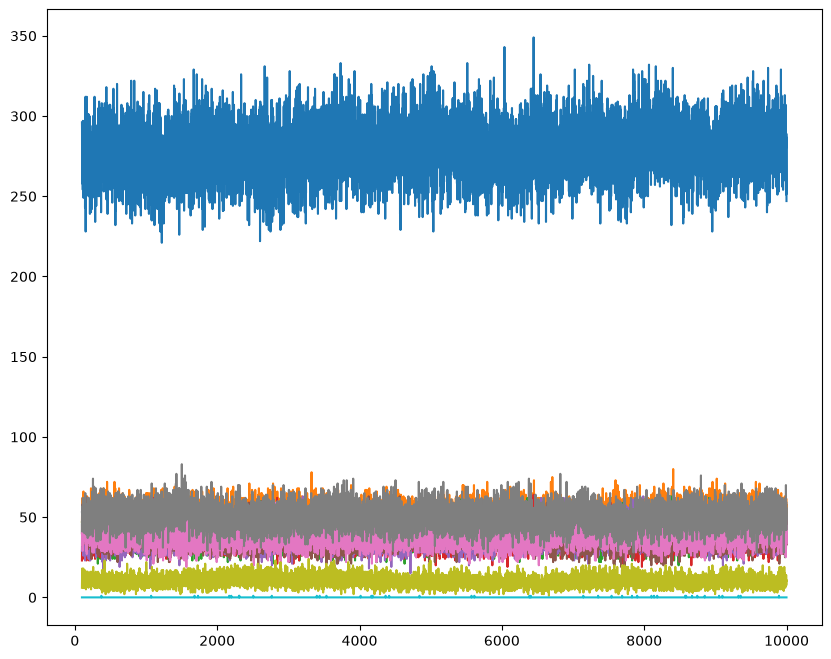

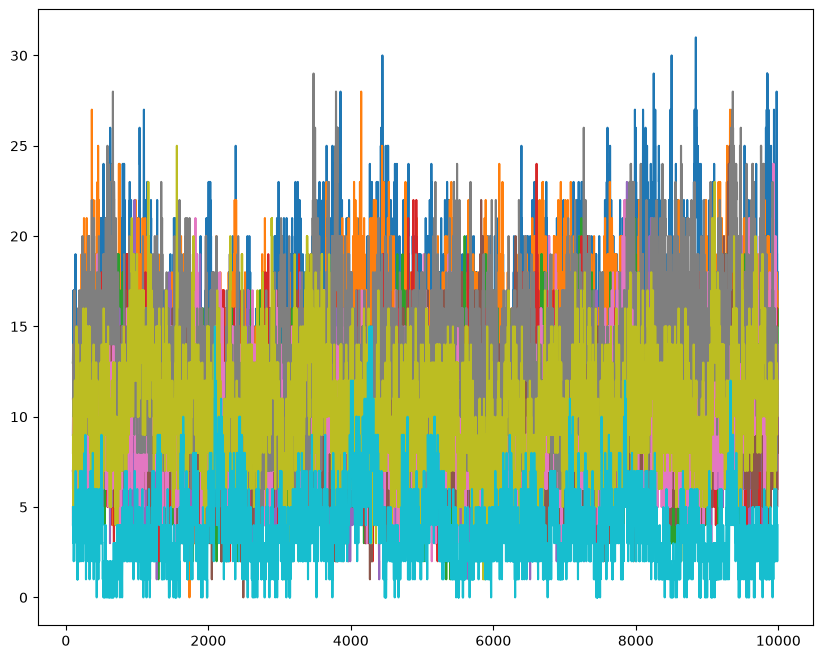

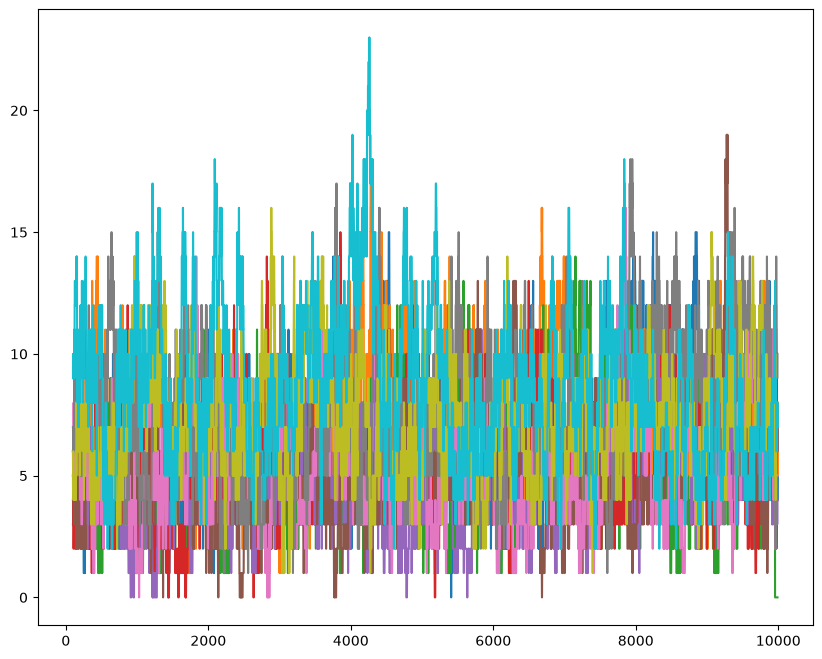

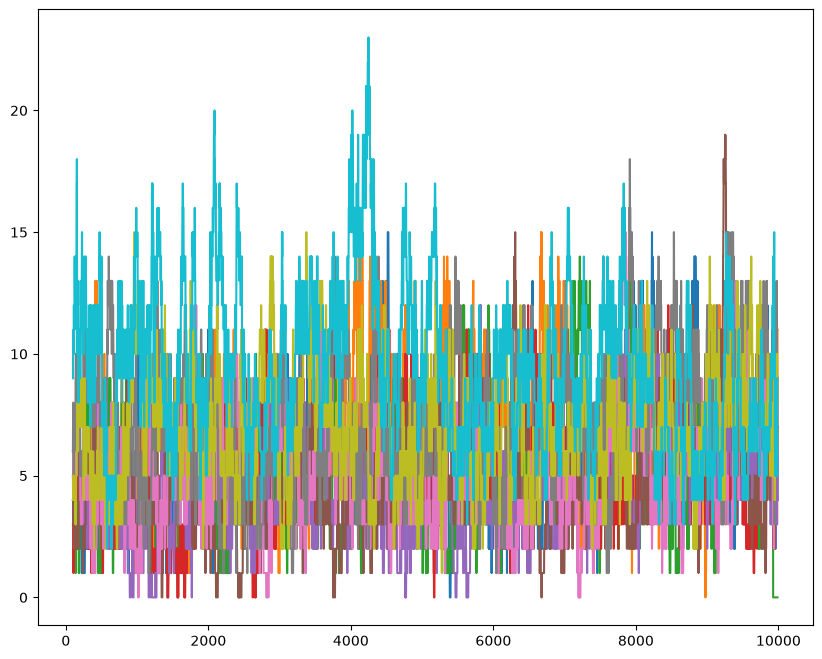

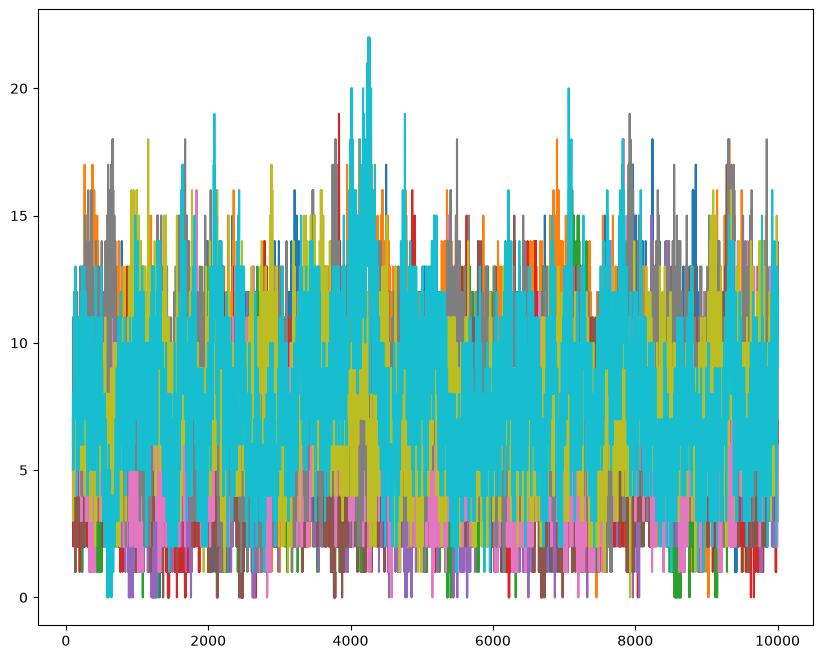

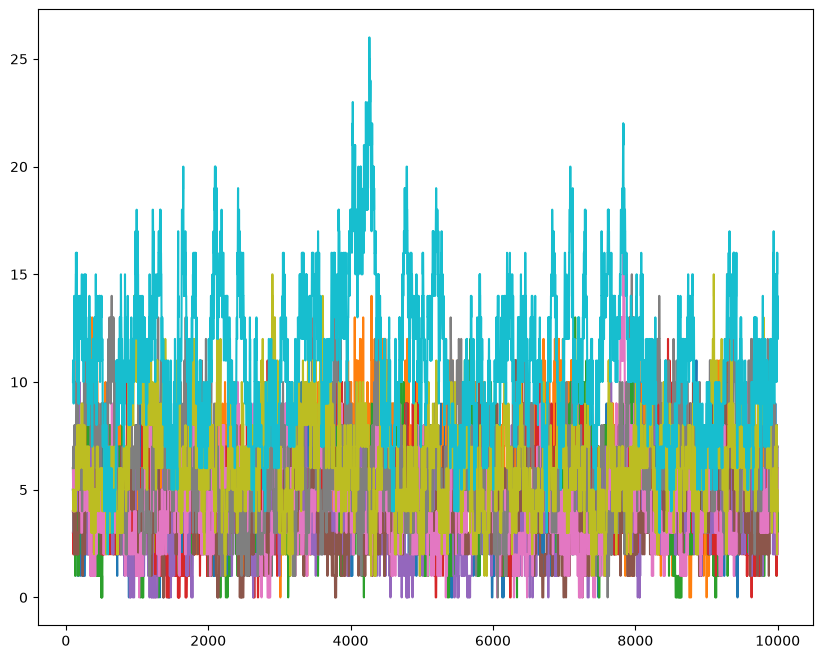

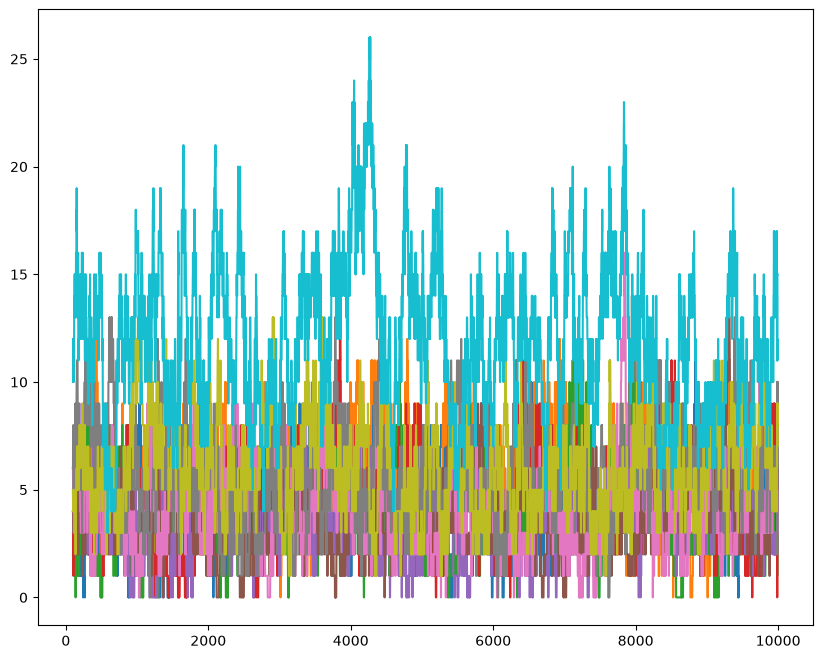

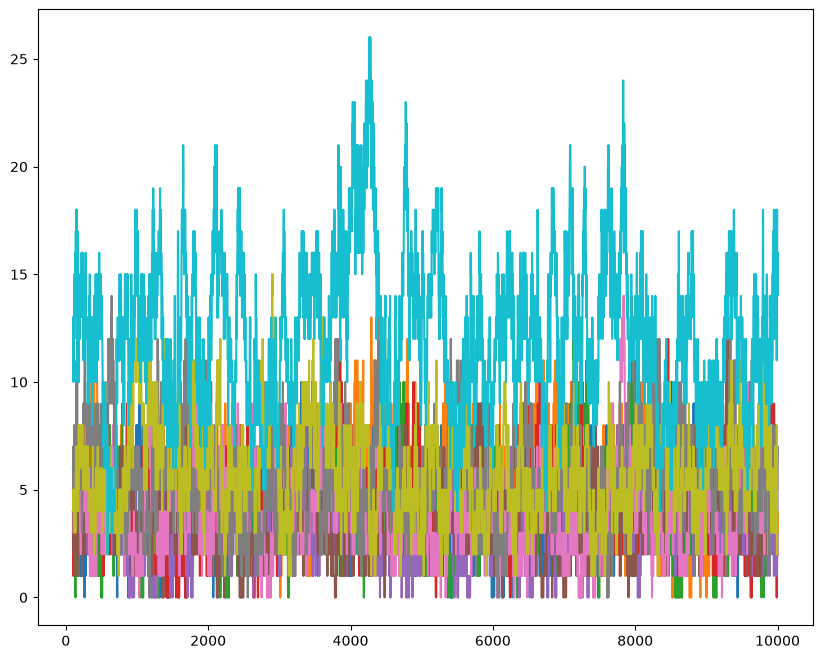

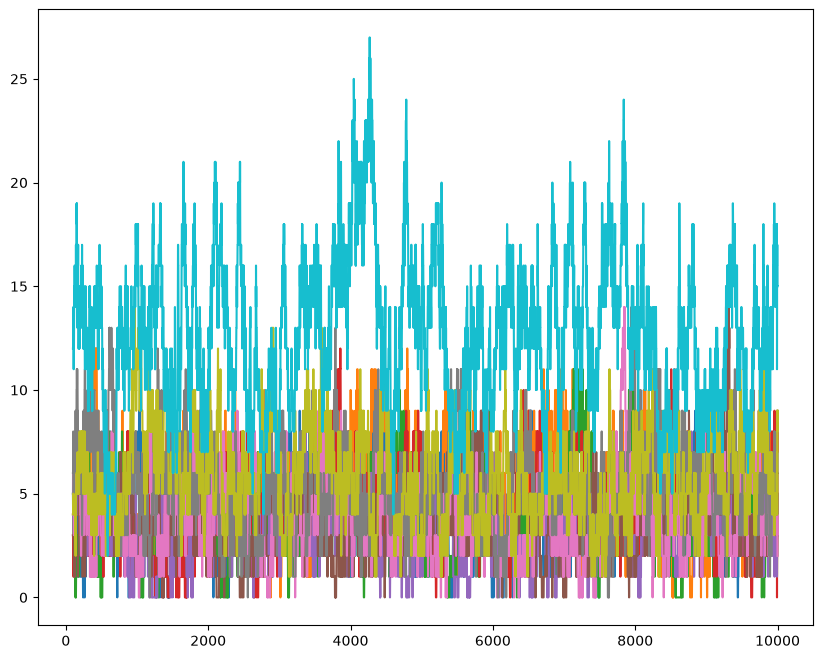

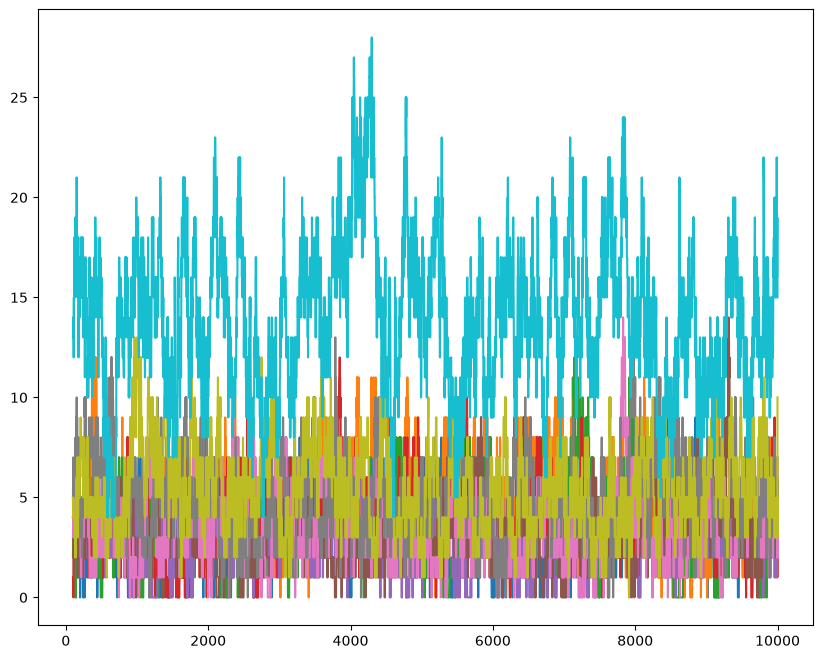

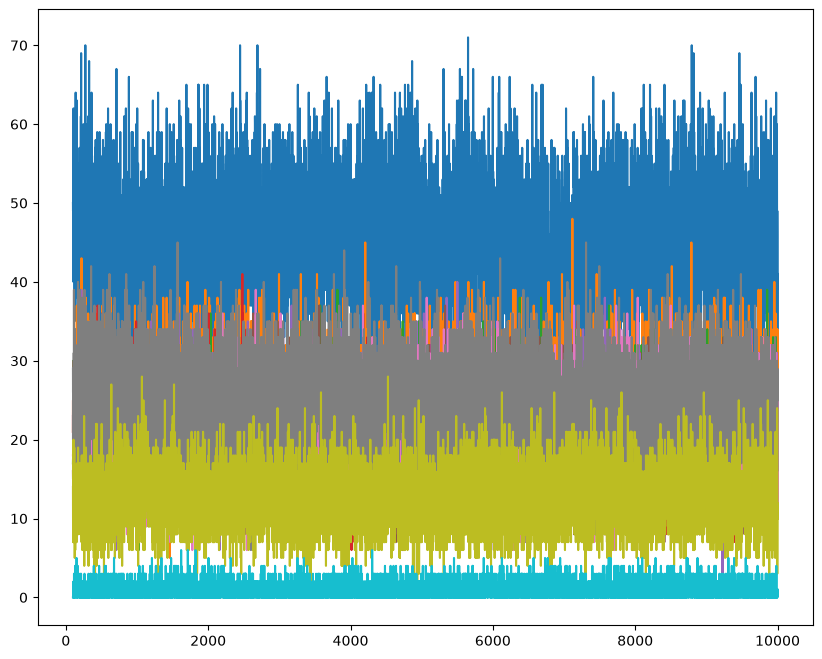

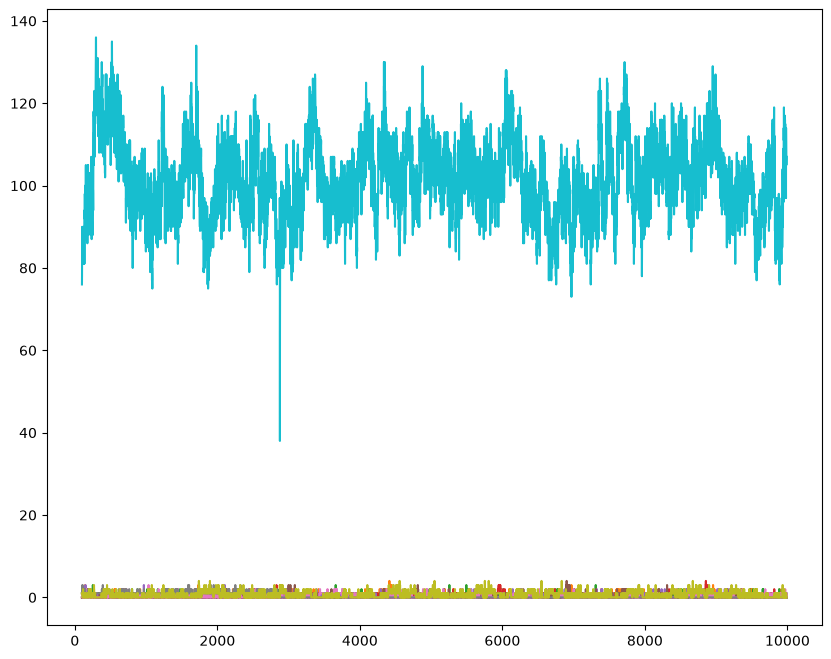

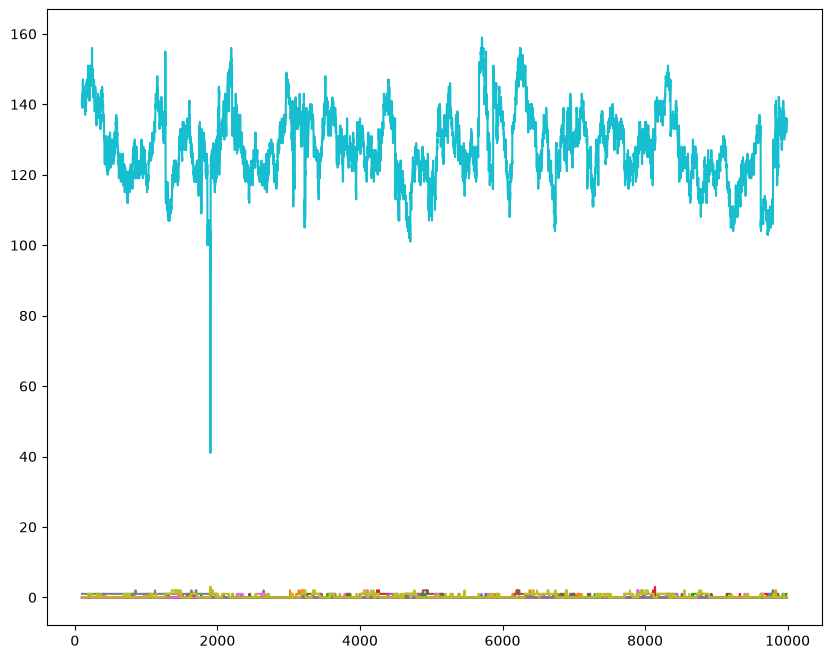

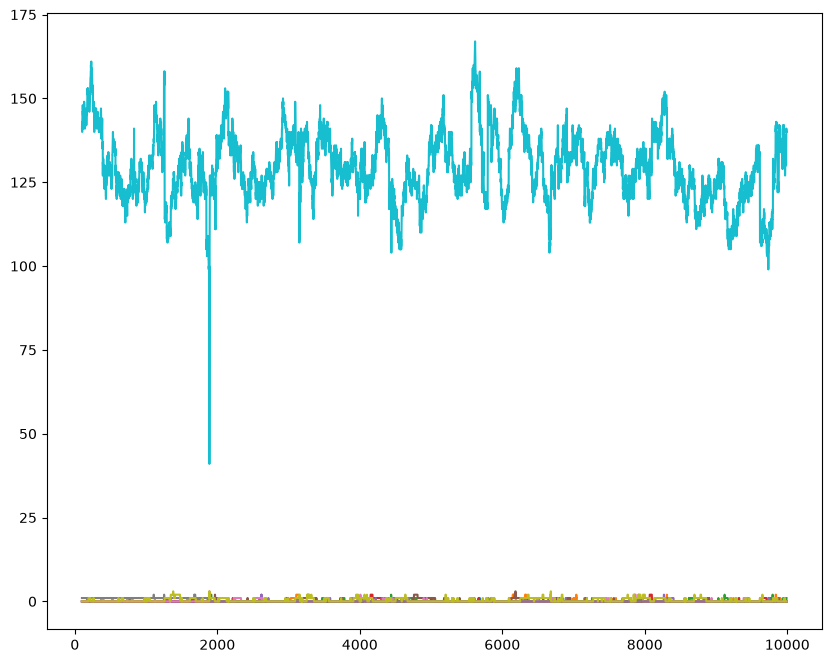

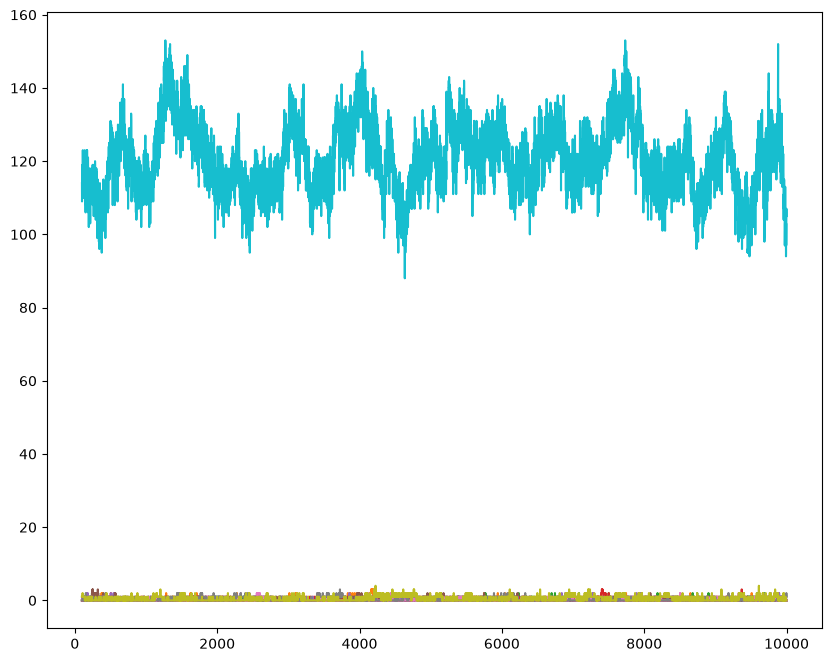

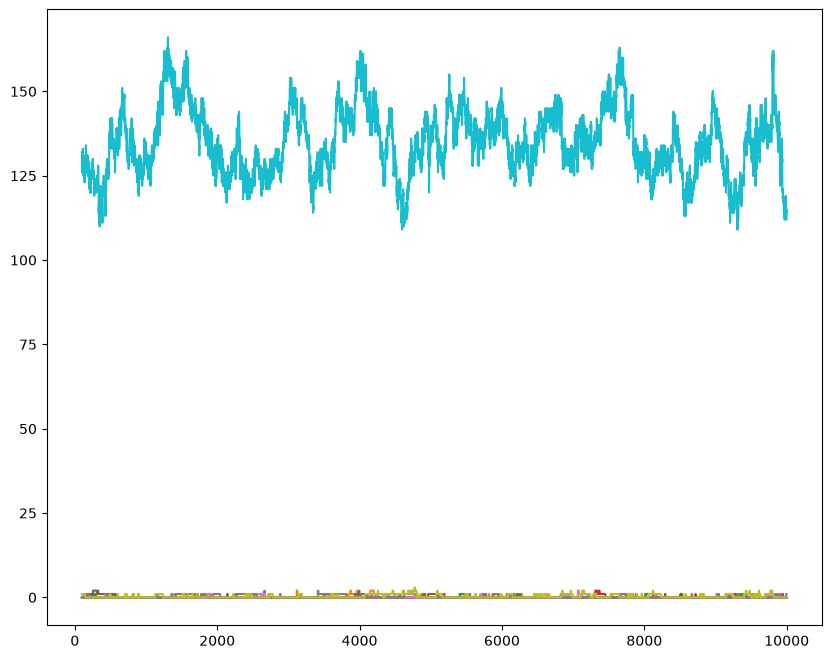

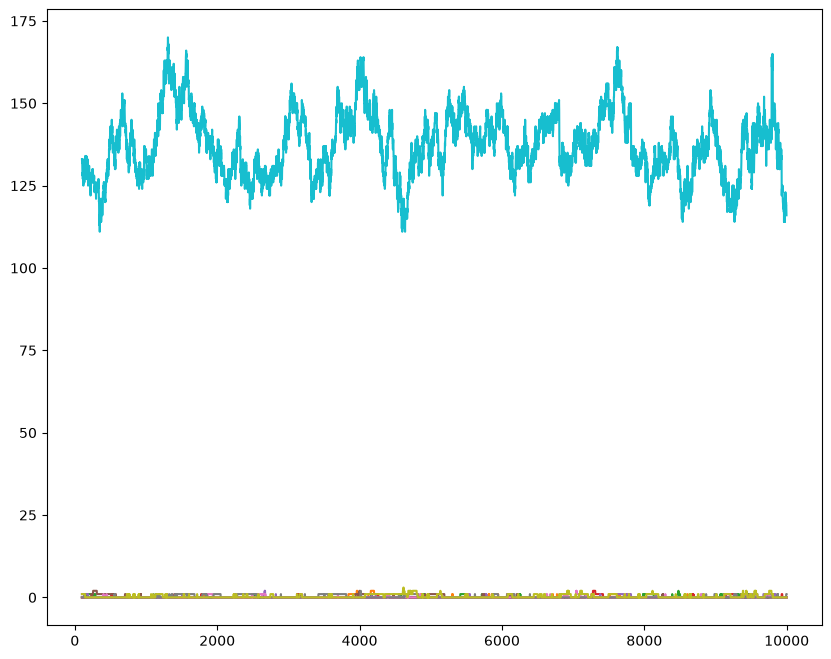

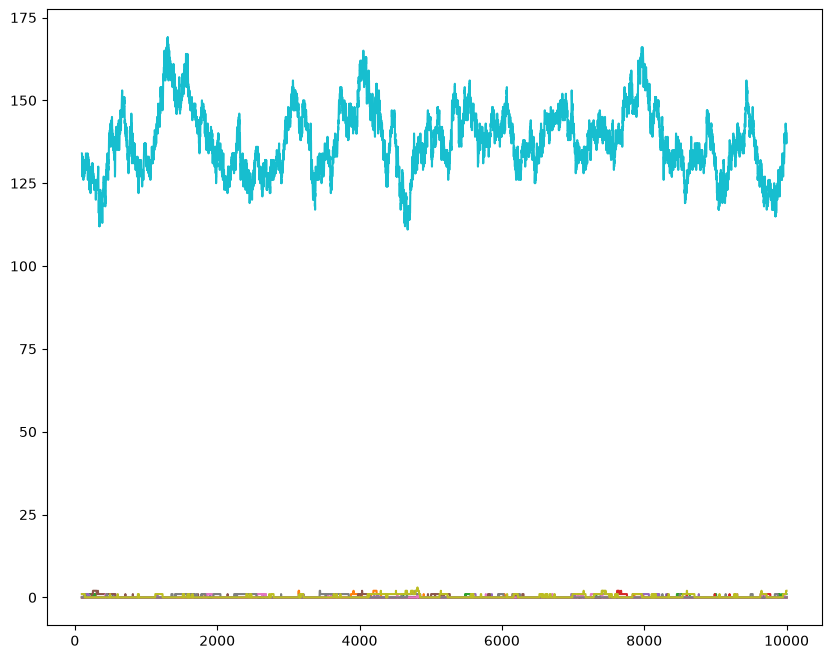

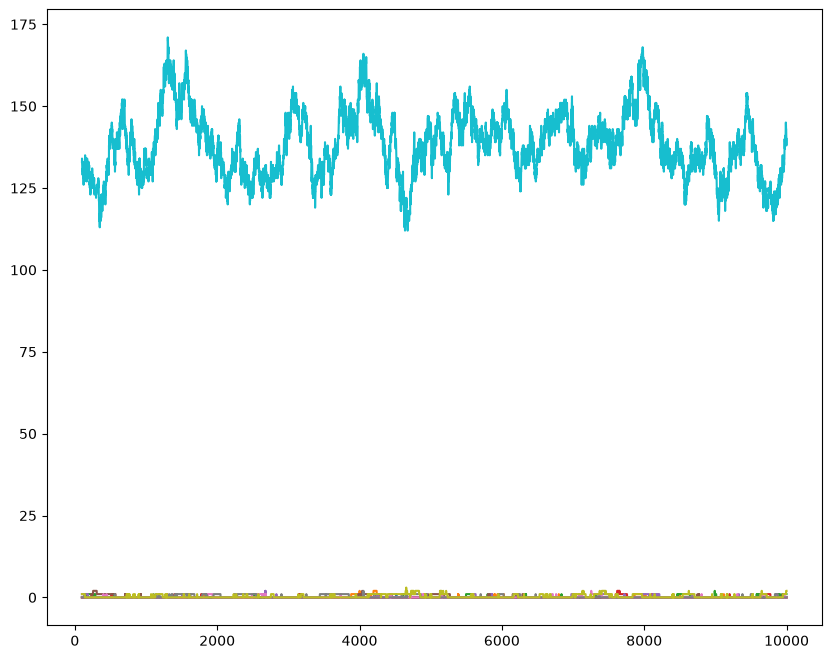

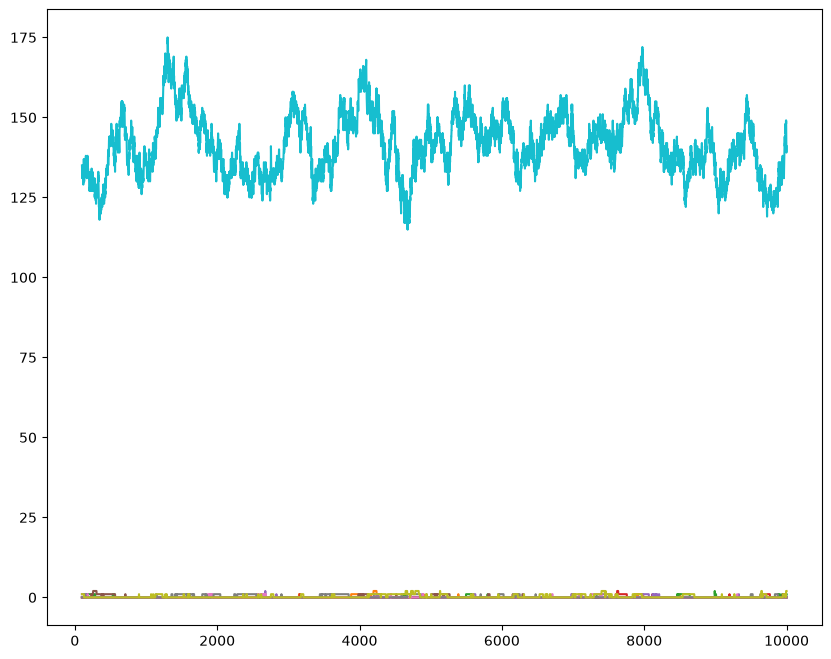

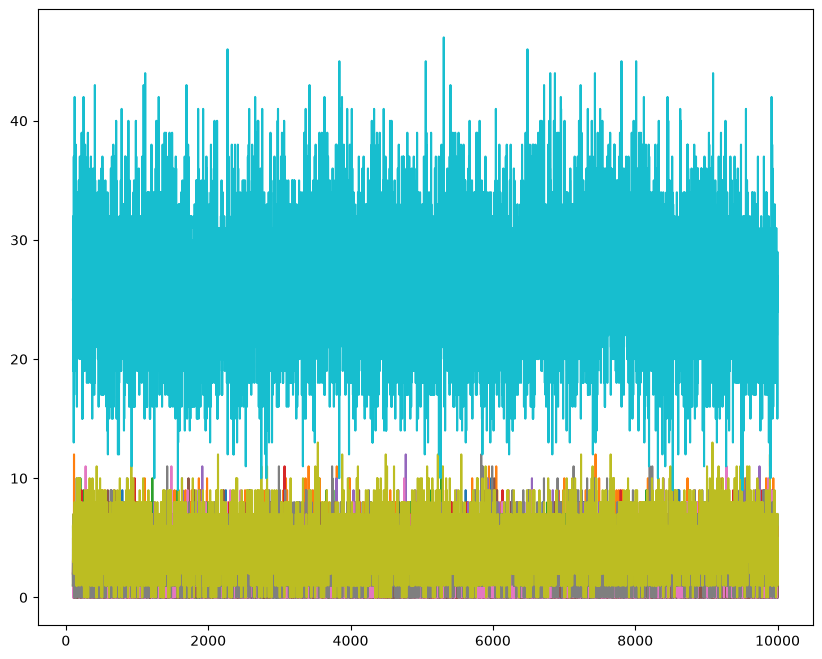

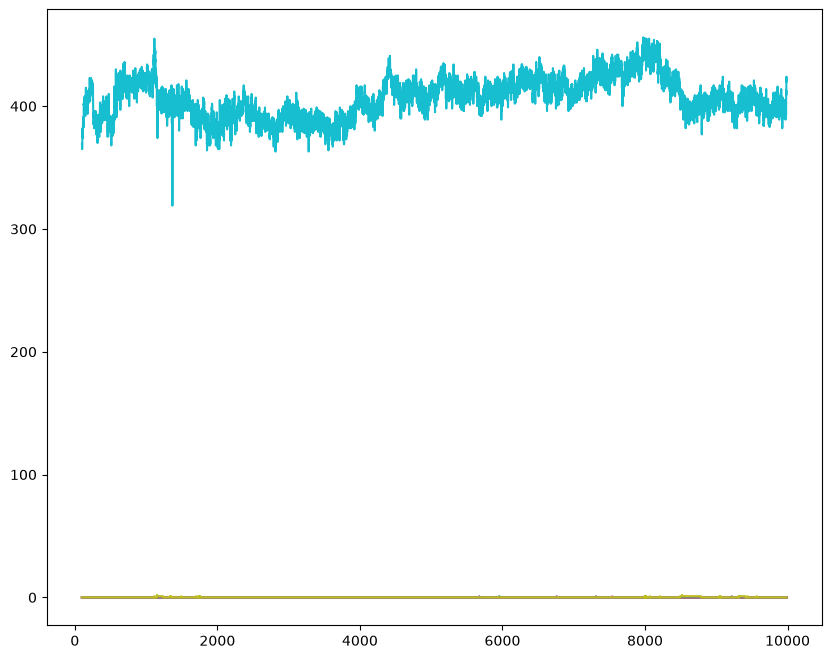

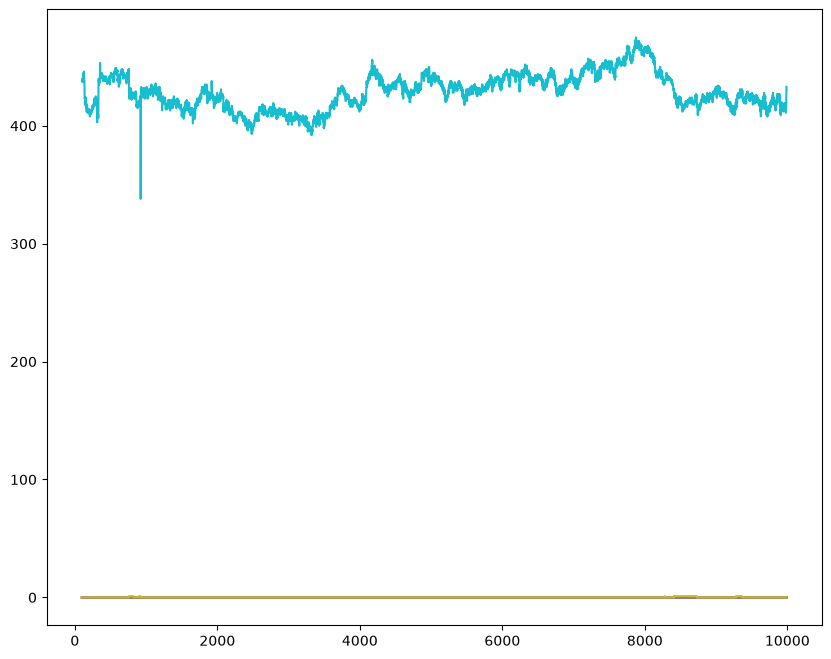

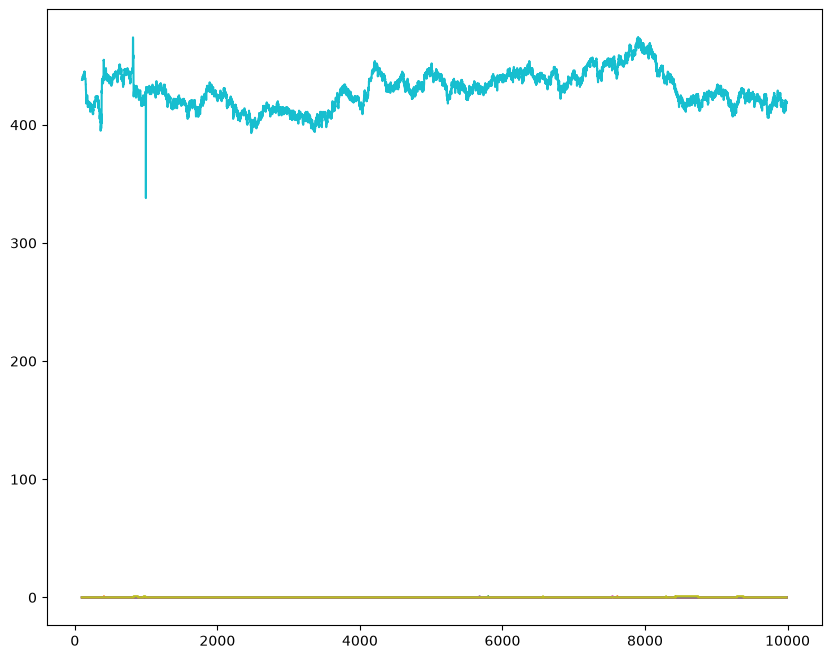

Did not find s=1 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.


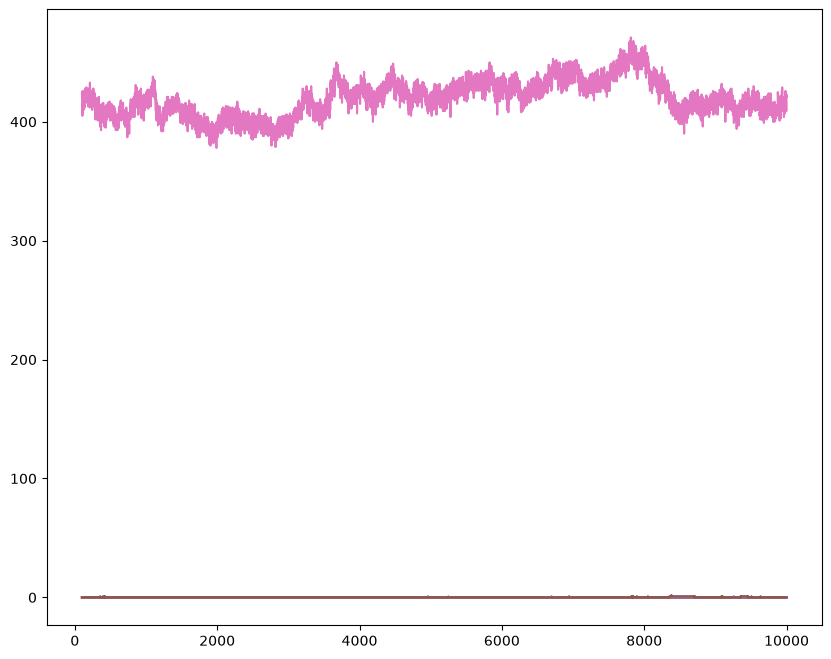

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.


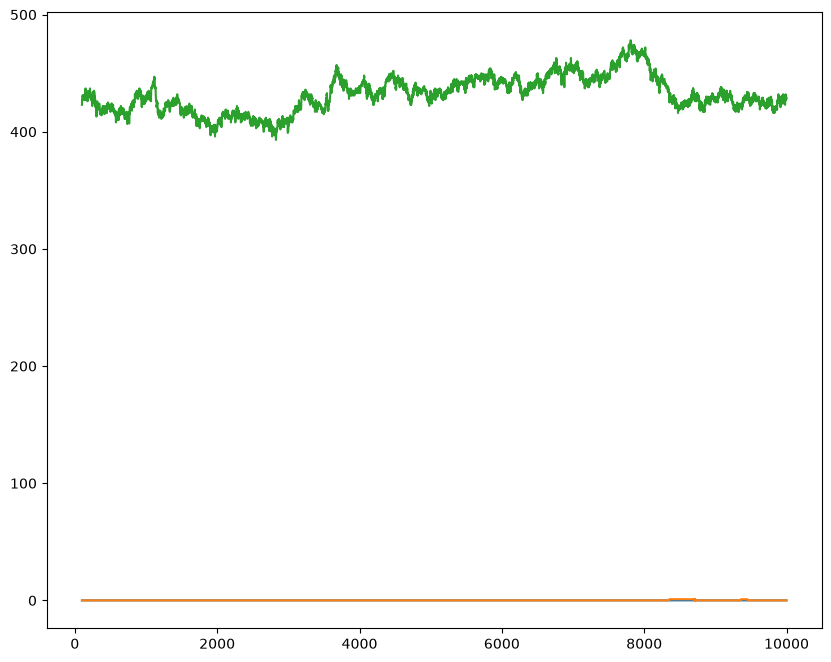

Did not find s=4 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.


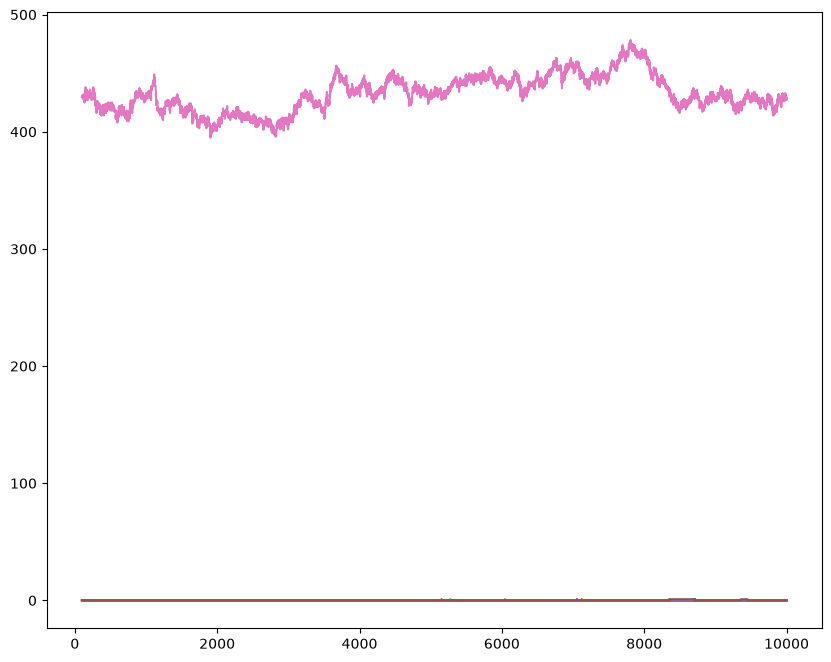

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.


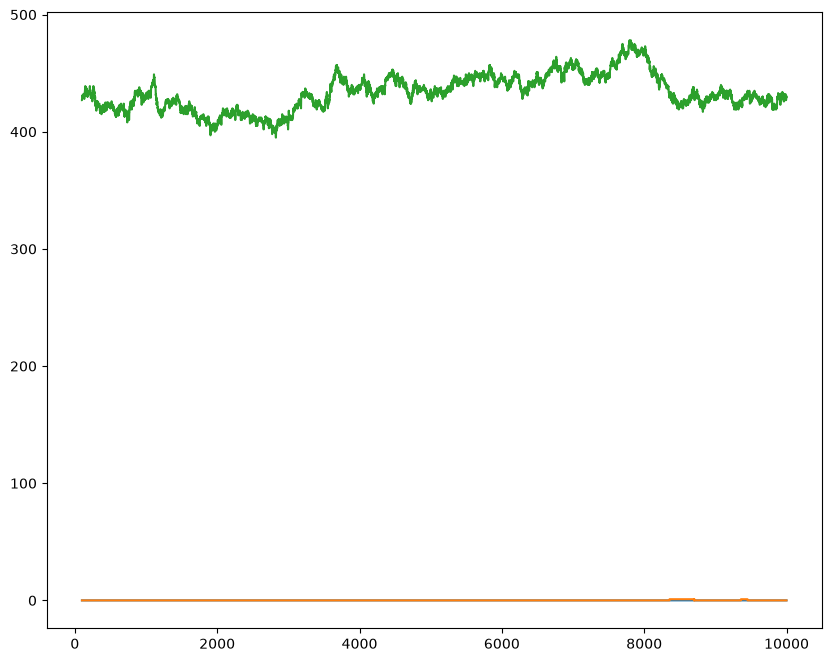

Did not find s=4 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.


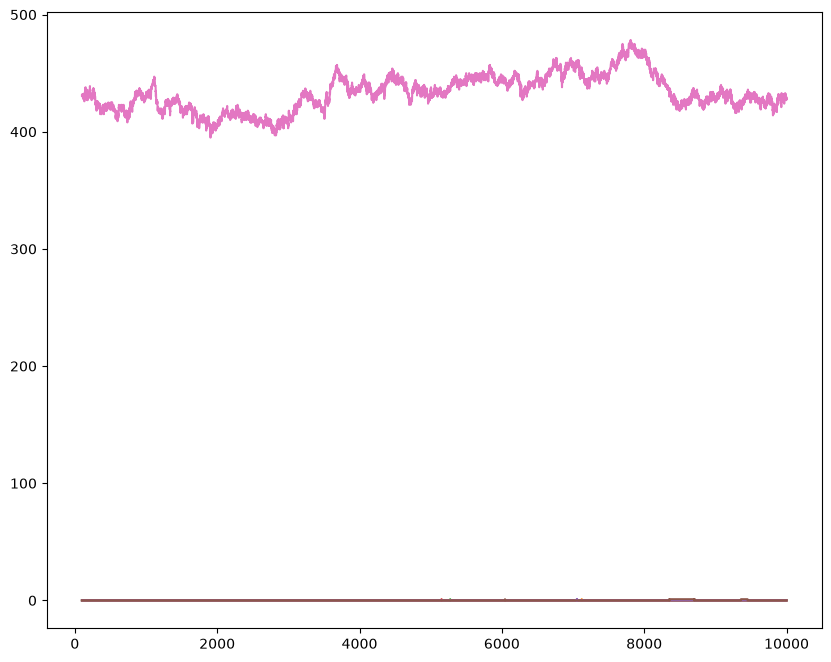

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.


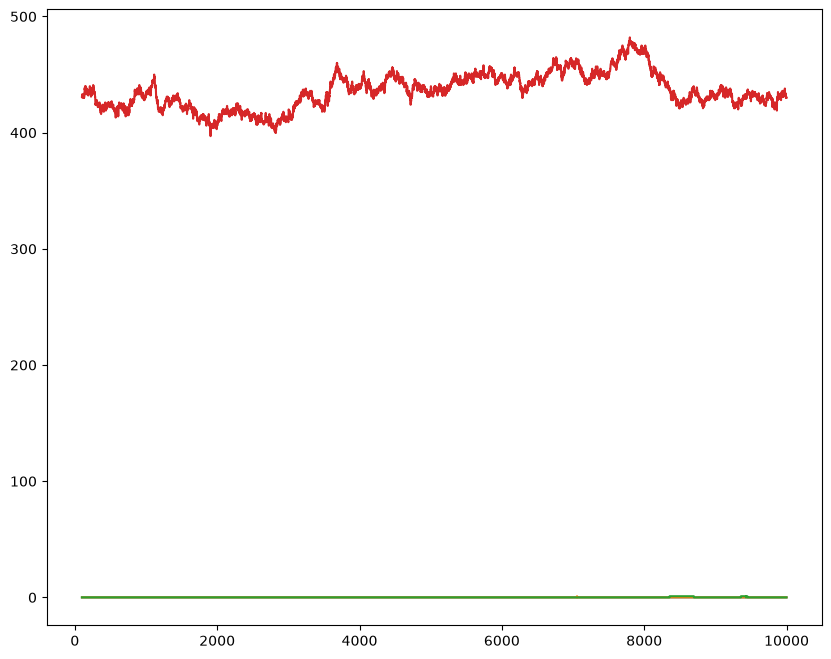

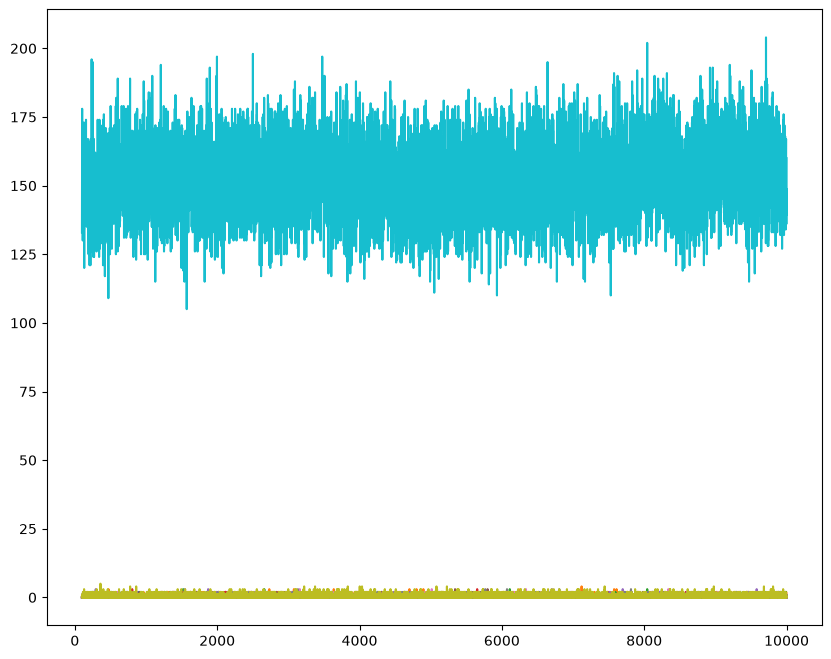

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


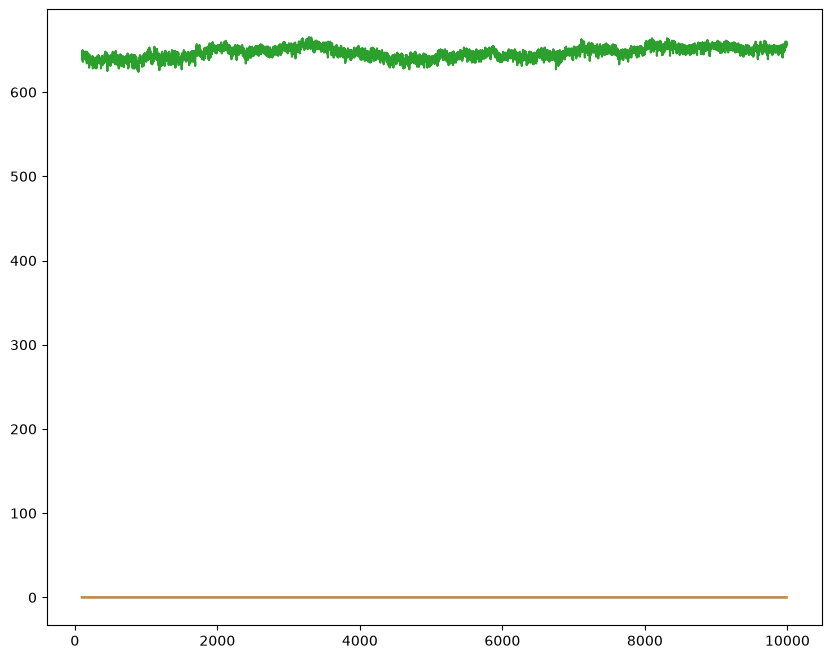

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


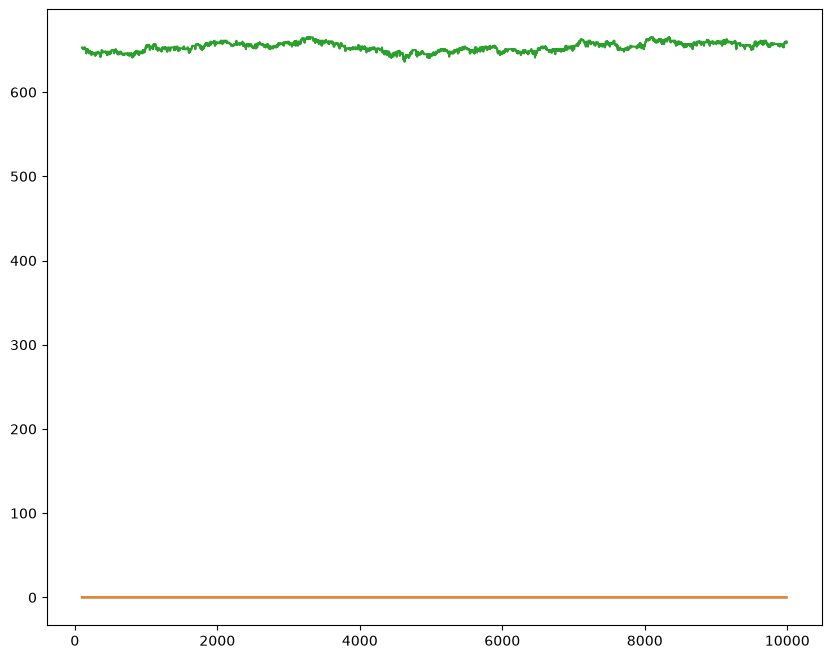

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


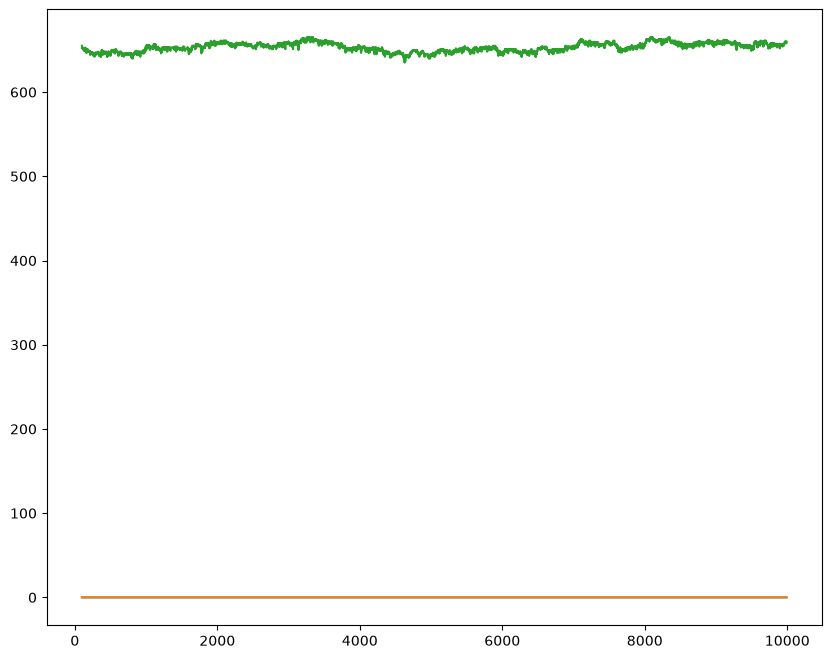

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


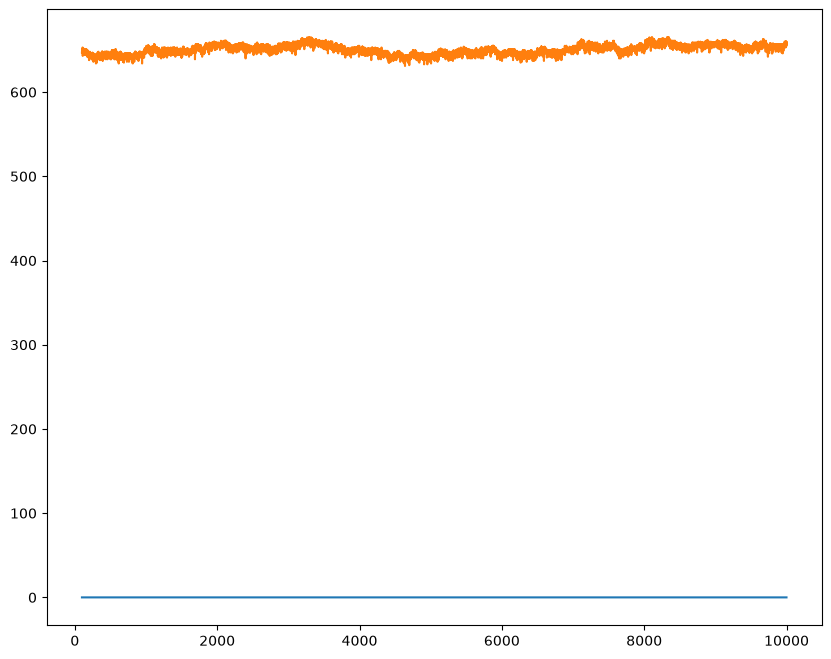

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


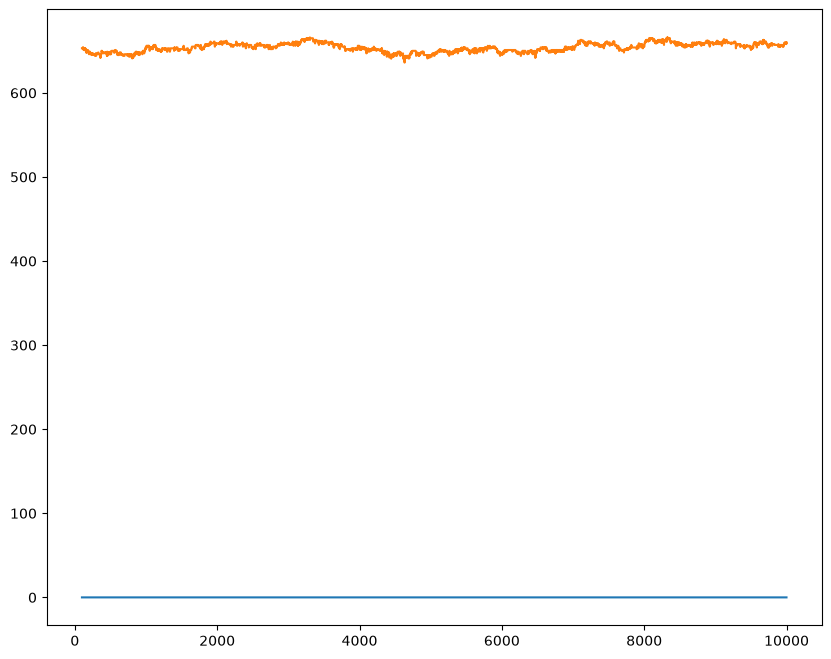

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


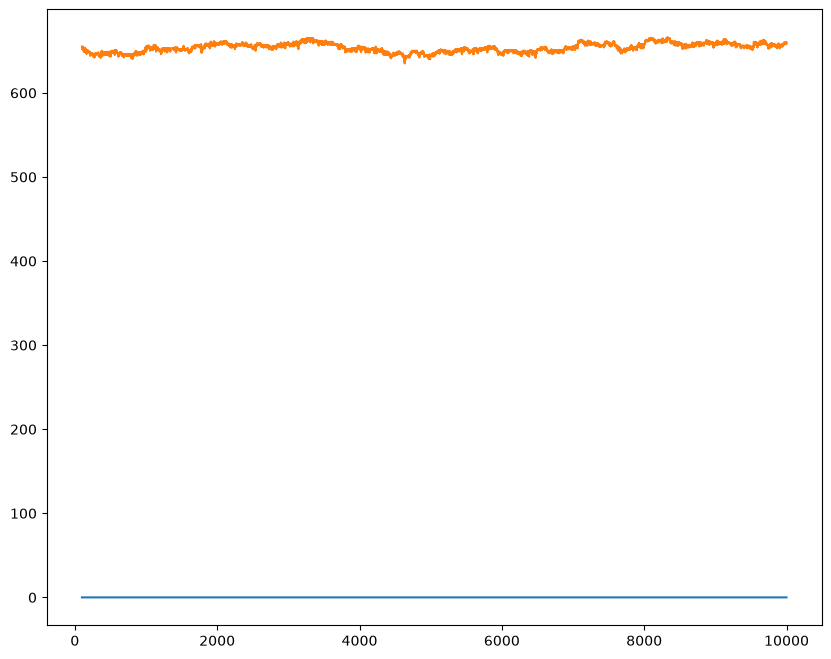

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


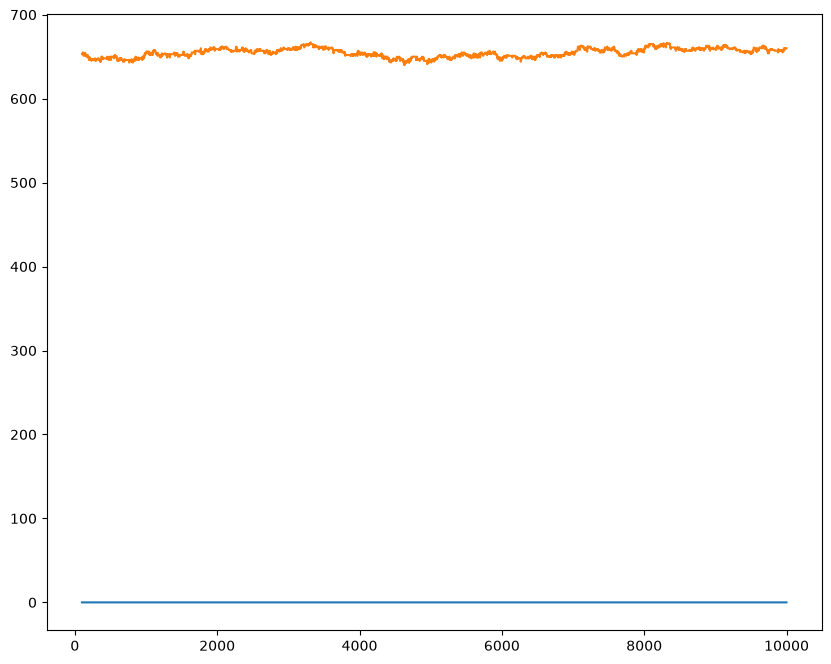

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


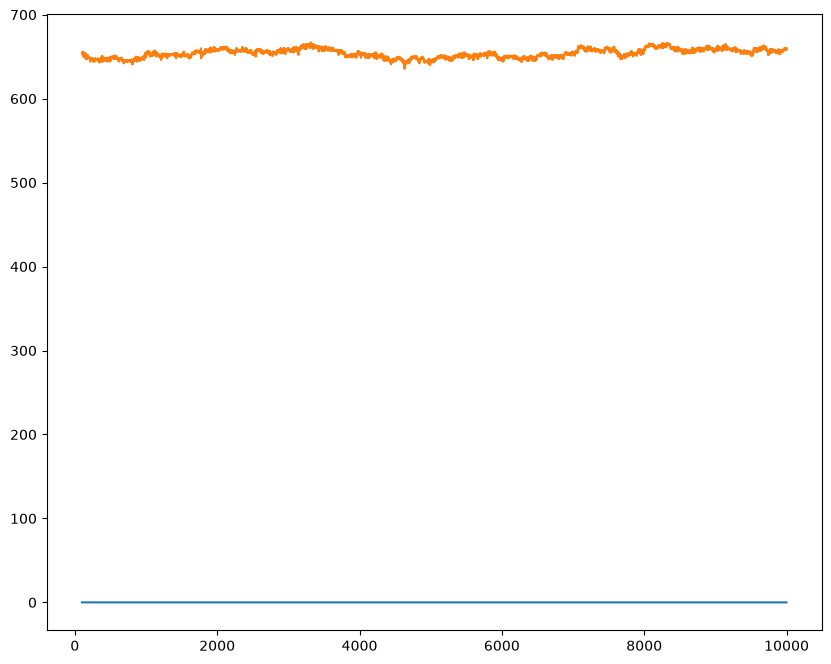

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


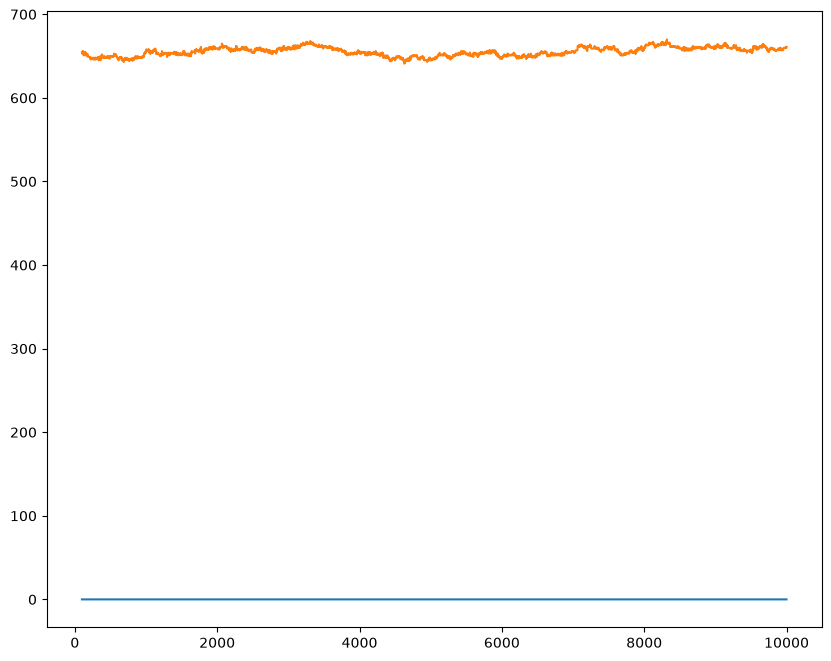

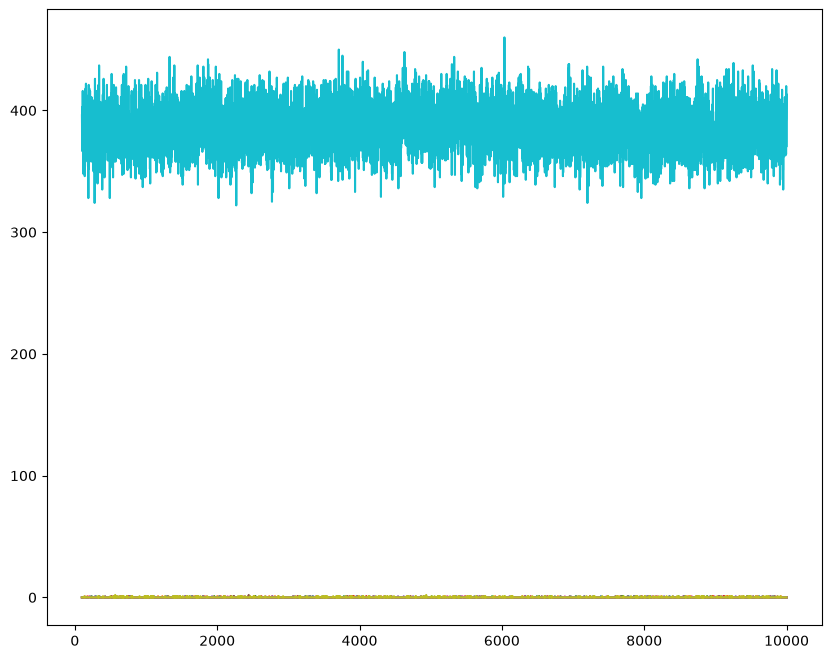

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


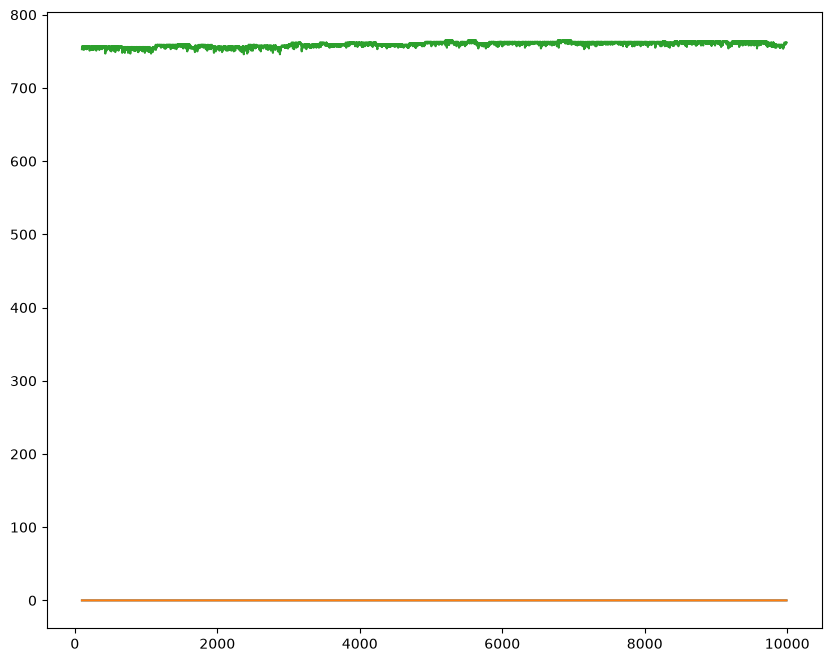

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


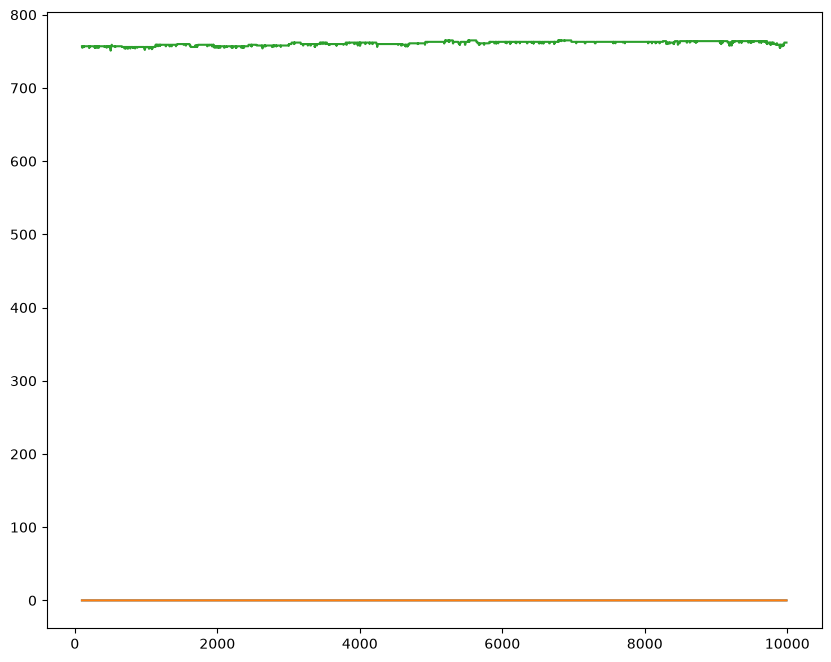

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


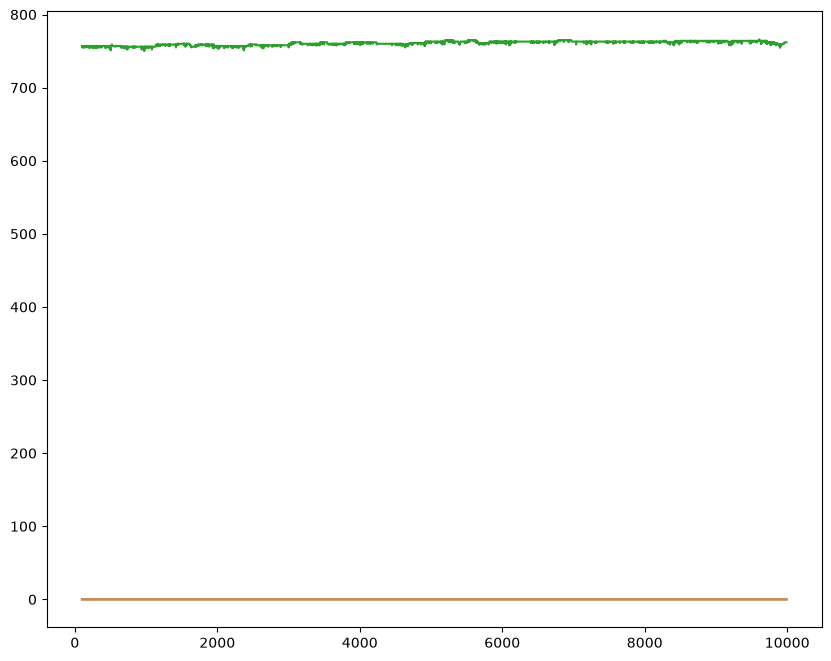

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


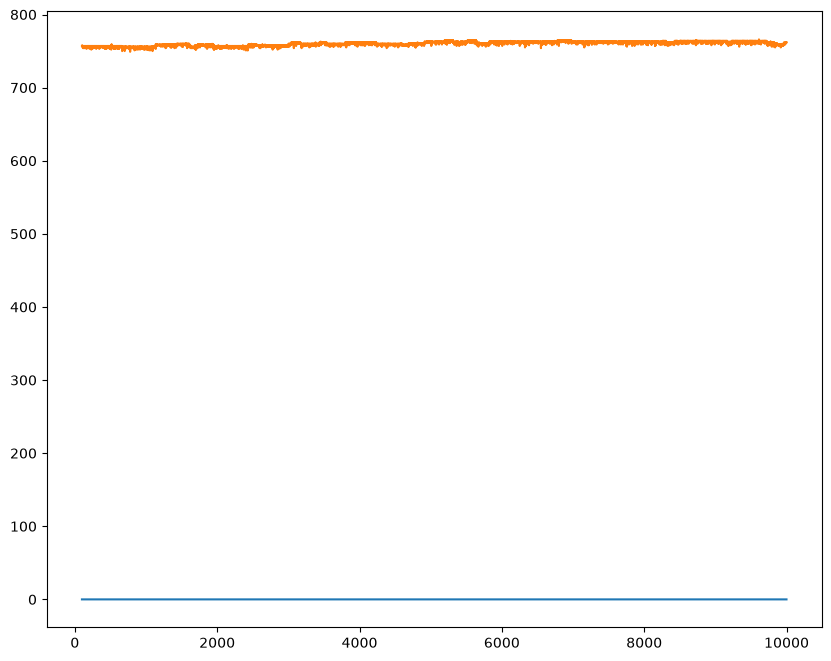

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


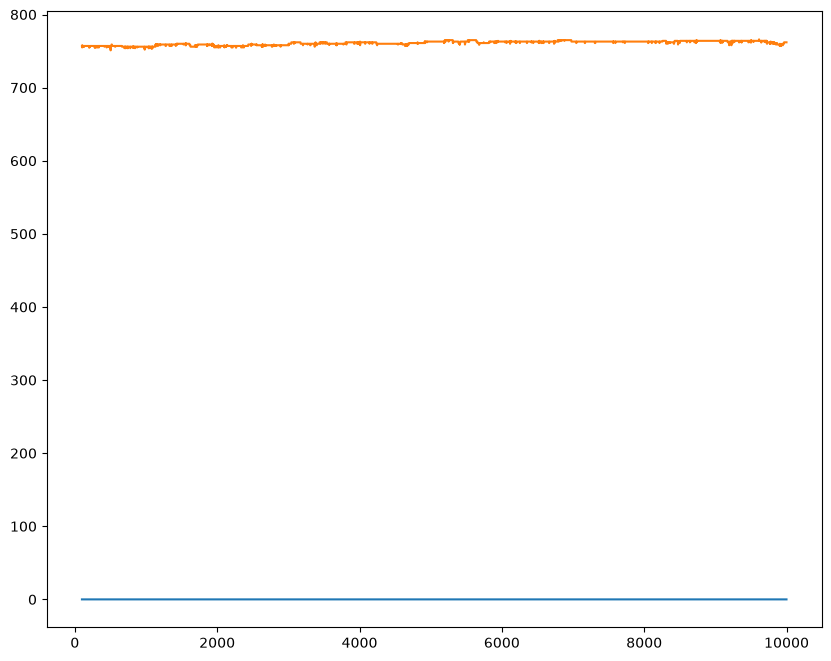

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


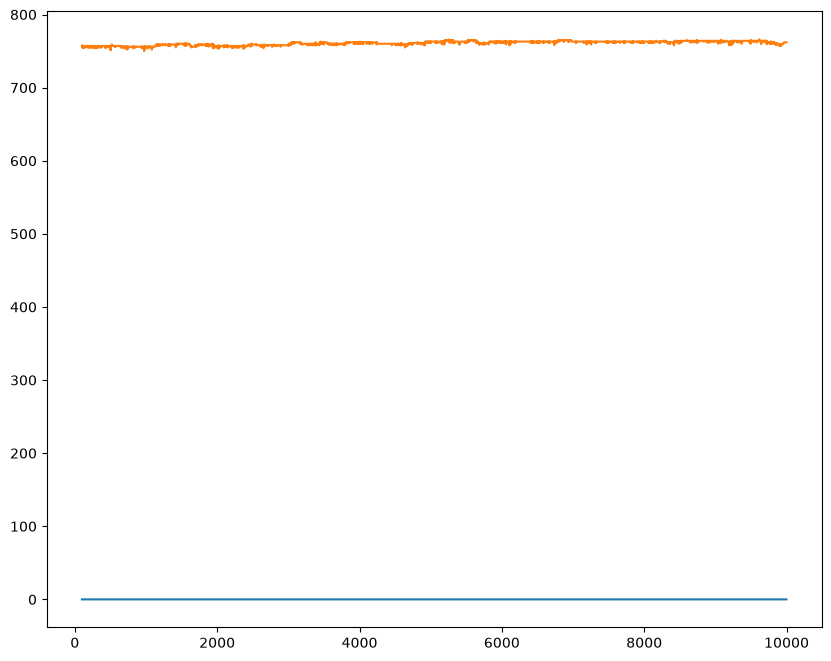

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


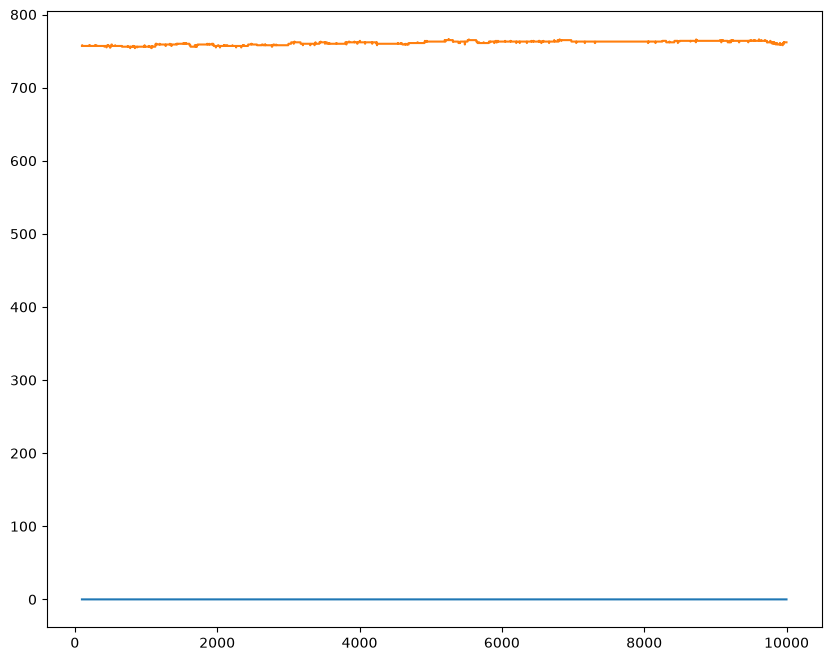

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


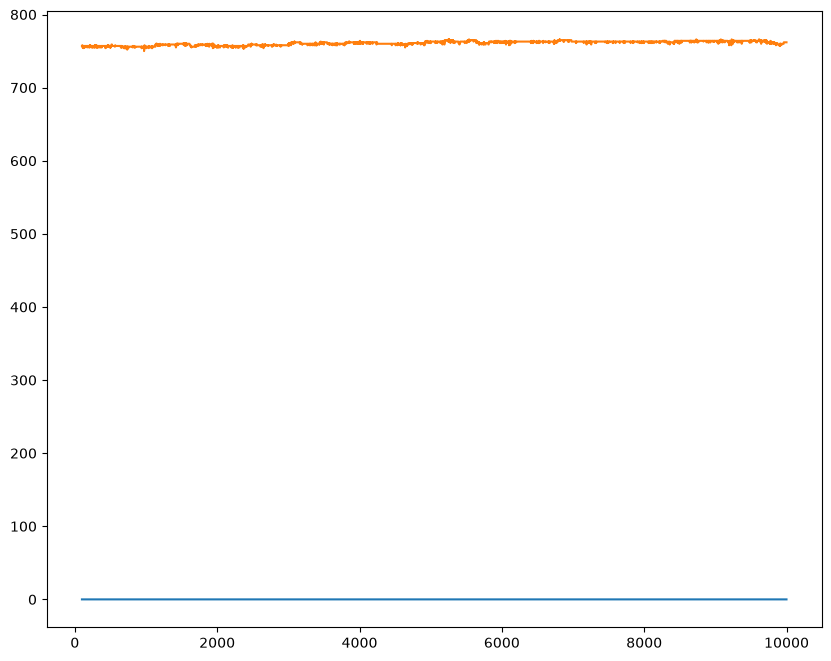

Did not find s=1 in the dataframe, not plotting.
Did not find s=2 in the dataframe, not plotting.
Did not find s=4 in the dataframe, not plotting.
Did not find s=8 in the dataframe, not plotting.
Did not find s=16 in the dataframe, not plotting.
Did not find s=32 in the dataframe, not plotting.
Did not find s=64 in the dataframe, not plotting.
Did not find s=96 in the dataframe, not plotting.


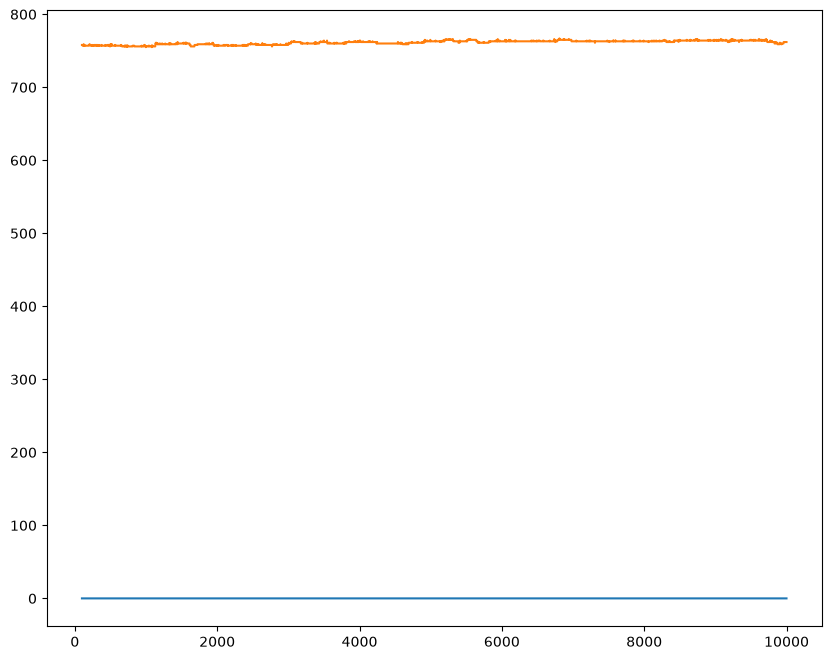

In [51]:
# cutoffs = [0.4, 0.5, 0.6, 0.7]

# As = [90, 100, 110, 120, 130]

# times = np.arange(0, 20, 0.002) # 10000 samples

# s_list = [0, 1, 2, 4, 8, 16, 32, 64, 96, 127]

# for A in As:
#     for cutoff_on in cutoffs:
#         for cutoff_off in cutoffs:
#             if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
#                 fig = plt.figure(figsize=(10,8))
#                 s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
#                 # s_list = np.arange(0, 128, 1)
#                 for s in s_list:
#                     try:
#                         plt.plot(s_counts_df[f'{s}'][100:], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
#                     except KeyError:
#                         print(f"Did not find s={s} in the dataframe, not plotting.")
#                 plt.show()
#                 # plt.plot(times[:len(s_counts_df)], s_c

nu_s(s=127) = 0.0005083578627531545


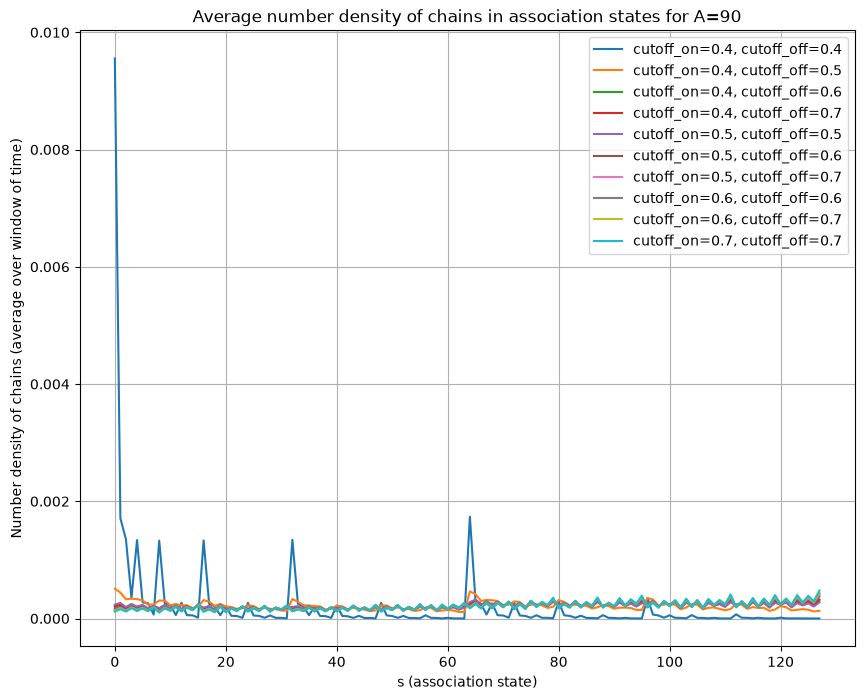

nu_s(s=127) = 0.0005083578627531545


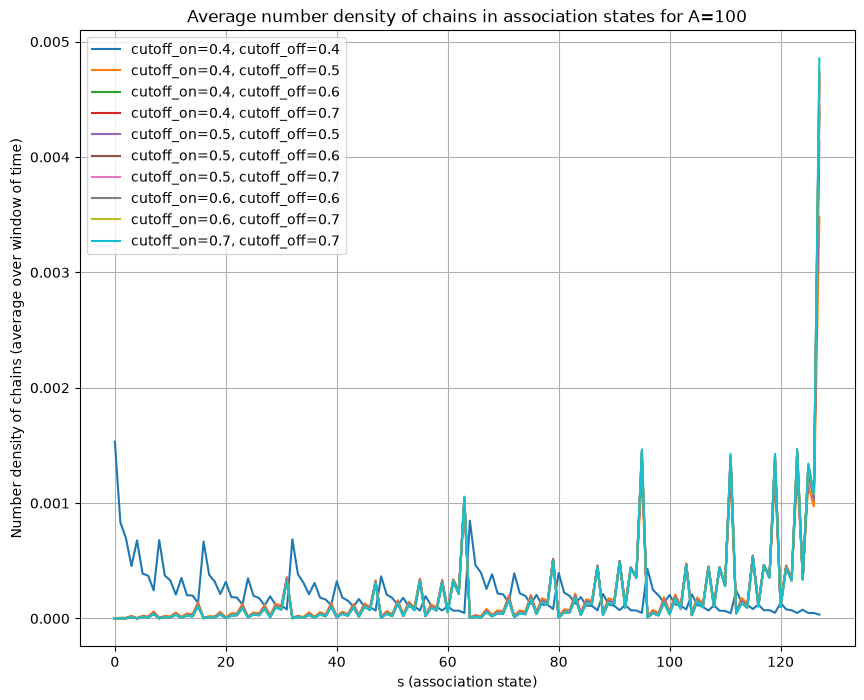

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=36 in the dataframe, setting nu_s_avg to 0.
Did not find s=40 in the dataframe, setting nu_s_avg to 0.
Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=3 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=5 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=12 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=20 in the dataframe, setting nu_s_avg to 0.
Did no

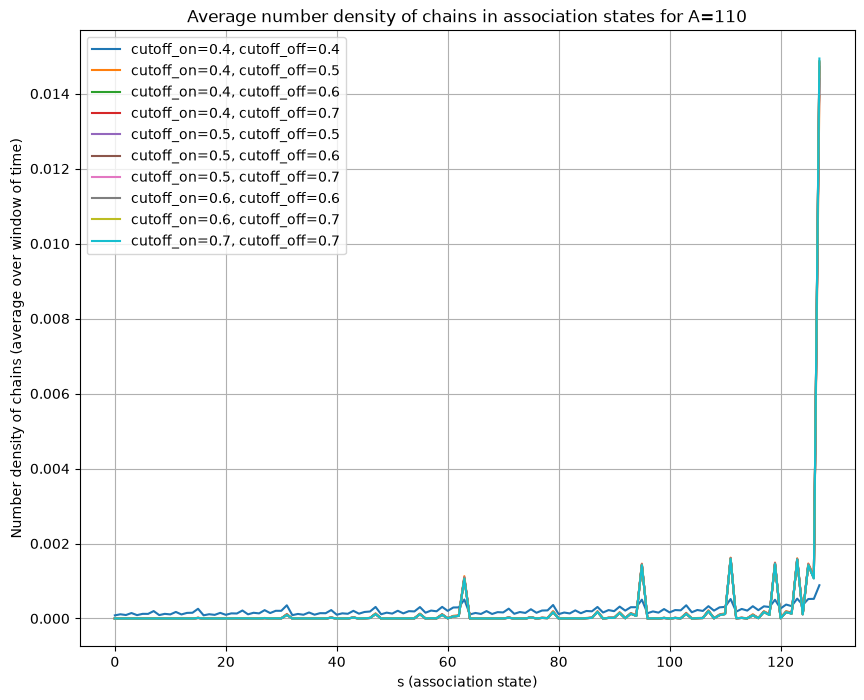

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=10 in the dataframe, setting nu_s_avg to 0.
Did not find s=14 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=20 in the dataframe, setting nu_s_avg to 0.
Did not find s=22 in the dataframe, setting nu_s_avg to 0.
Did not find s=24 in the dataframe, setting nu_s_avg to 0.
Did not find s=26 in the dataframe, setting nu_s_avg to 0.
Did not find s=32 in the dataframe, setting nu_s_avg to 0.
Did not find s=34 in the dataframe, setting nu_s_avg to 0.
Did not find s=36 in the dataframe, setting nu_s_avg to 0.
Did not find s=40 in the dataframe, setting nu_s_avg to 0.
Di

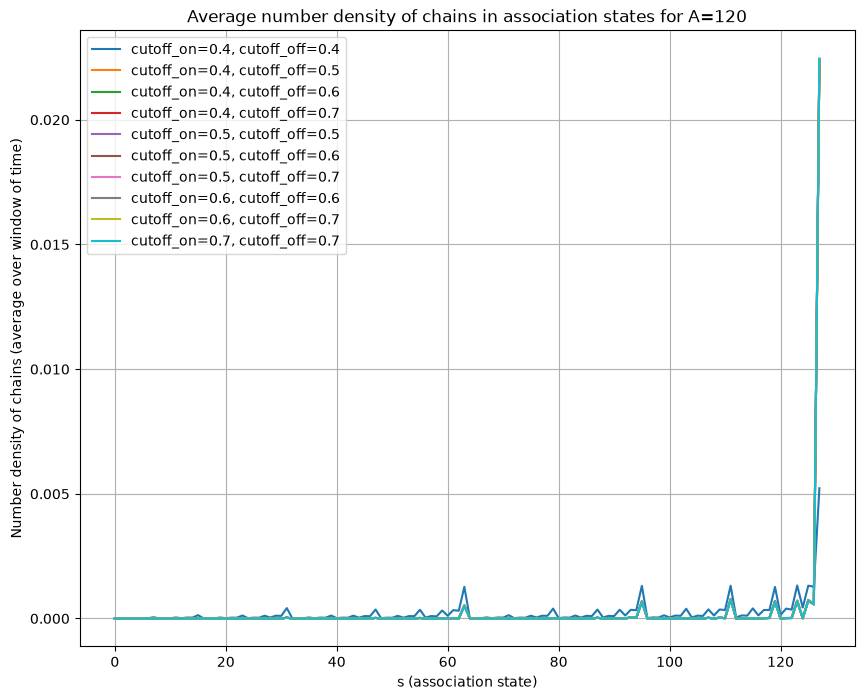

Did not find s=1 in the dataframe, setting nu_s_avg to 0.
Did not find s=2 in the dataframe, setting nu_s_avg to 0.
Did not find s=3 in the dataframe, setting nu_s_avg to 0.
Did not find s=4 in the dataframe, setting nu_s_avg to 0.
Did not find s=5 in the dataframe, setting nu_s_avg to 0.
Did not find s=6 in the dataframe, setting nu_s_avg to 0.
Did not find s=8 in the dataframe, setting nu_s_avg to 0.
Did not find s=9 in the dataframe, setting nu_s_avg to 0.
Did not find s=10 in the dataframe, setting nu_s_avg to 0.
Did not find s=11 in the dataframe, setting nu_s_avg to 0.
Did not find s=12 in the dataframe, setting nu_s_avg to 0.
Did not find s=13 in the dataframe, setting nu_s_avg to 0.
Did not find s=14 in the dataframe, setting nu_s_avg to 0.
Did not find s=16 in the dataframe, setting nu_s_avg to 0.
Did not find s=17 in the dataframe, setting nu_s_avg to 0.
Did not find s=18 in the dataframe, setting nu_s_avg to 0.
Did not find s=19 in the dataframe, setting nu_s_avg to 0.
Did n

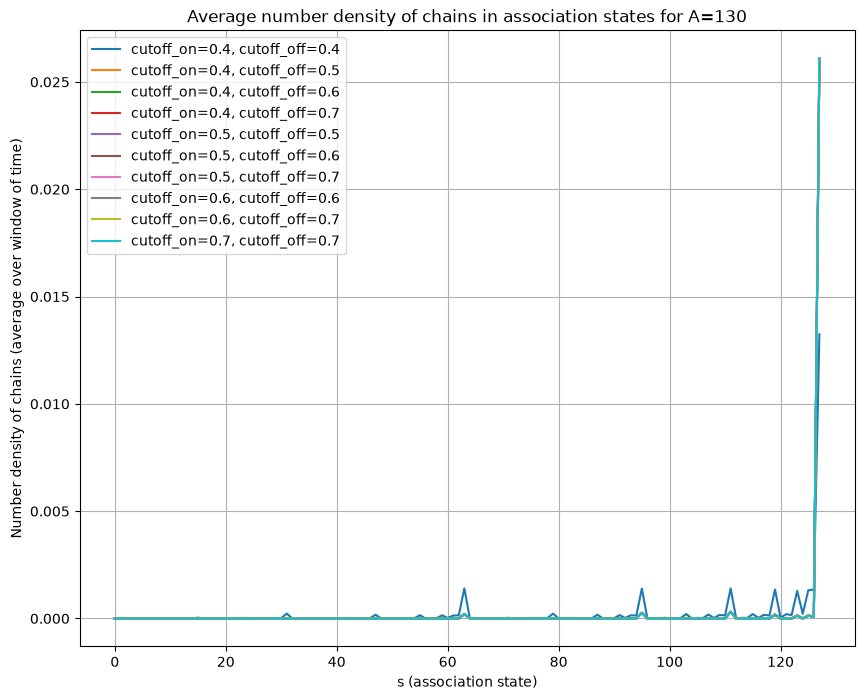

In [52]:

cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

times = np.arange(0, 20, 0.002) # 10000 samples

for A in As:
    fig = plt.figure(figsize=(10,8))
    for cutoff_on in cutoffs:
        for cutoff_off in cutoffs:
            if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
                s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                s_list = np.arange(0, 128, 1)
                nu_s_avg_list = []
                for s in s_list:
                    try:
                        nu_s_avg_list.append(np.mean(s_counts_df[f'{s}'][100:]) / box_volume)  # Average number density of chains in state s
                    except KeyError:
                        nu_s_avg_list.append(0)
                        print(f"Did not find s={s} in the dataframe, setting nu_s_avg to 0.")
                plt.plot(s_list, nu_s_avg_list, label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")

                # plt.plot(times[:len(s_counts_df)], s_counts_df[f'{s}'], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")



    plt.xlabel(f"s (association state)")
    plt.ylabel(f"Number density of chains (average over window of time)")
    print(f"nu_s(s={s}) = {nu_s(s, 1/5.58, 1/7.27, 5, 31, 0.0274)}")
    # plt.axhline(nu_s(s, 1/11.09, 1/5.42, 5, 31, 0.0274), color='r', linestyle='--', label=f"nu_s(s={s})")
    plt.title(f"Average number density of chains in association states for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()

## Distribution of associated patch count

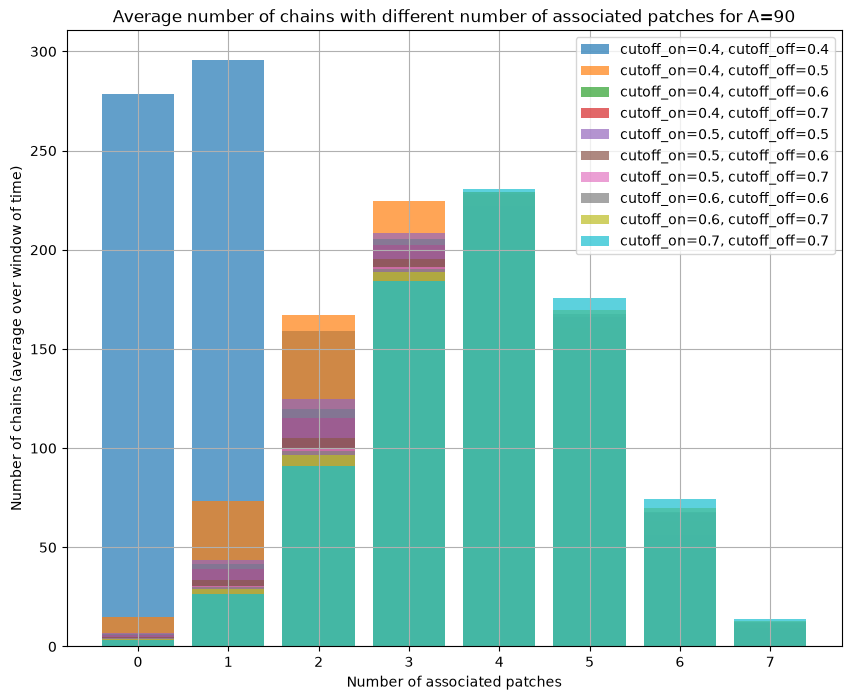

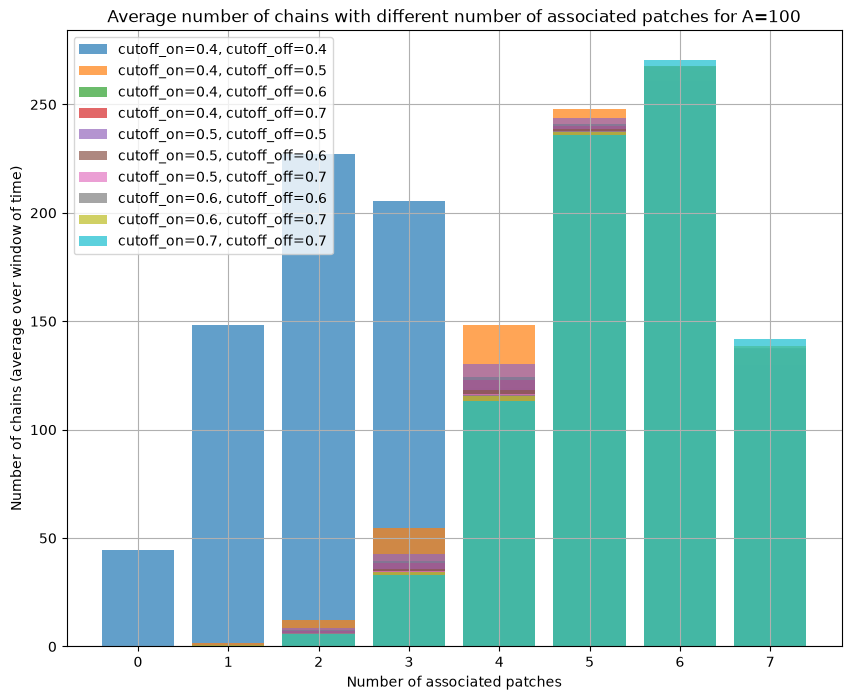

Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=16 in the dataframe, setting num_associated to 0.
Did not find s=36 in the dataframe, setting num_associated to 0.
Did not find s=40 in the dataframe, setting num_associated to 0.
Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=3 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=5 in the dataframe, setting num_associated to 0.
Did not find s=6 in the dataframe, setting num_associated to 0.
Did not find s=8 in the dataframe, setting num_associated to 0.
Did not find s=12 in the dataframe, setting num_associated to 0.
Did not find s=16 in the dataframe, setting num_associated to 0.
Did not find s=17 in the dataframe, setting num_associated to 0.
Did not find s=18 in the dataframe

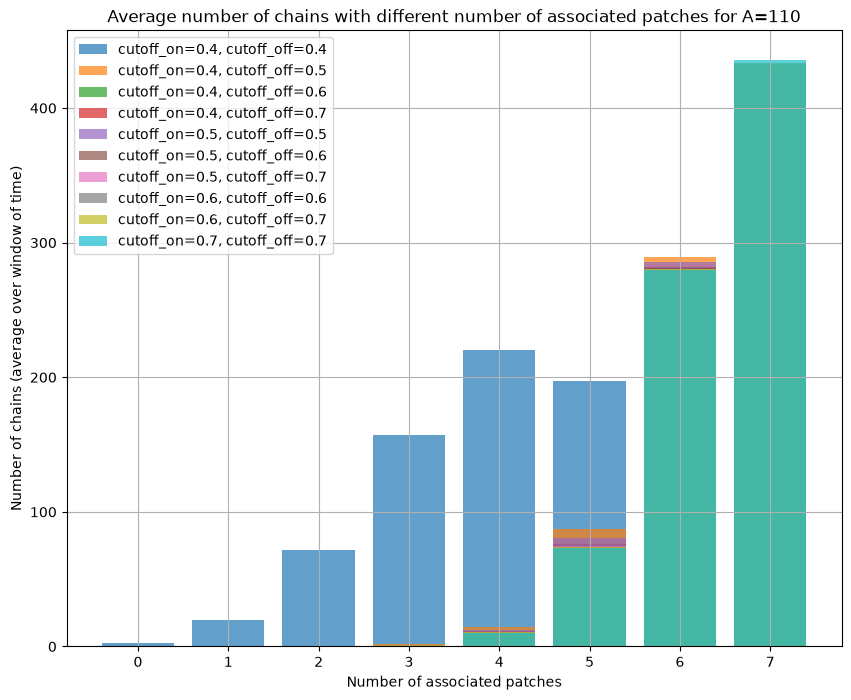

Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=6 in the dataframe, setting num_associated to 0.
Did not find s=8 in the dataframe, setting num_associated to 0.
Did not find s=10 in the dataframe, setting num_associated to 0.
Did not find s=14 in the dataframe, setting num_associated to 0.
Did not find s=17 in the dataframe, setting num_associated to 0.
Did not find s=18 in the dataframe, setting num_associated to 0.
Did not find s=20 in the dataframe, setting num_associated to 0.
Did not find s=22 in the dataframe, setting num_associated to 0.
Did not find s=24 in the dataframe, setting num_associated to 0.
Did not find s=26 in the dataframe, setting num_associated to 0.
Did not find s=32 in the dataframe, setting num_associated to 0.
Did not find s=34 in the dataframe, setting num_associated to 0.
Did not find s=36 in the dataf

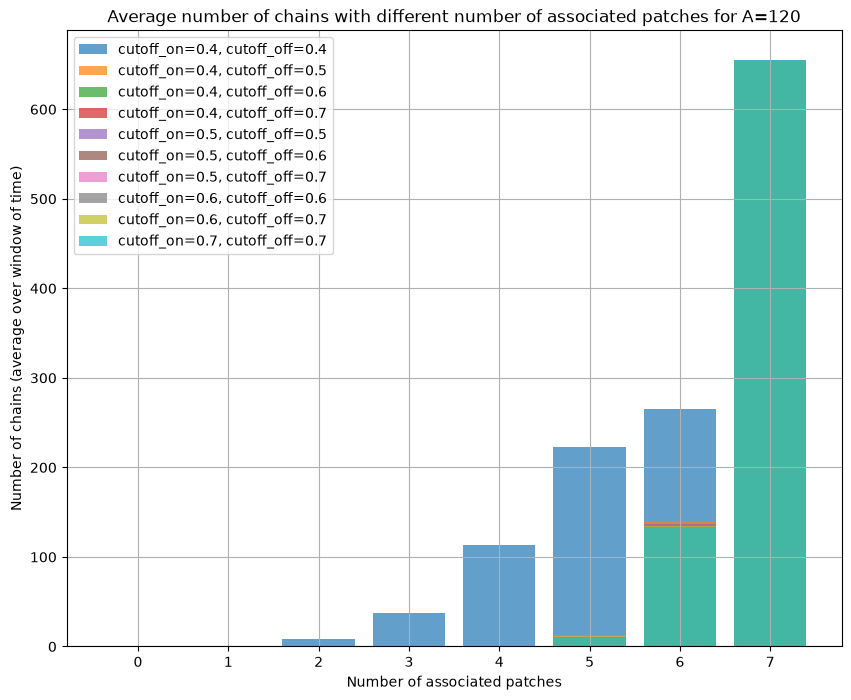

Did not find s=1 in the dataframe, setting num_associated to 0.
Did not find s=2 in the dataframe, setting num_associated to 0.
Did not find s=3 in the dataframe, setting num_associated to 0.
Did not find s=4 in the dataframe, setting num_associated to 0.
Did not find s=5 in the dataframe, setting num_associated to 0.
Did not find s=6 in the dataframe, setting num_associated to 0.
Did not find s=8 in the dataframe, setting num_associated to 0.
Did not find s=9 in the dataframe, setting num_associated to 0.
Did not find s=10 in the dataframe, setting num_associated to 0.
Did not find s=11 in the dataframe, setting num_associated to 0.
Did not find s=12 in the dataframe, setting num_associated to 0.
Did not find s=13 in the dataframe, setting num_associated to 0.
Did not find s=14 in the dataframe, setting num_associated to 0.
Did not find s=16 in the dataframe, setting num_associated to 0.
Did not find s=17 in the dataframe, setting num_associated to 0.
Did not find s=18 in the datafram

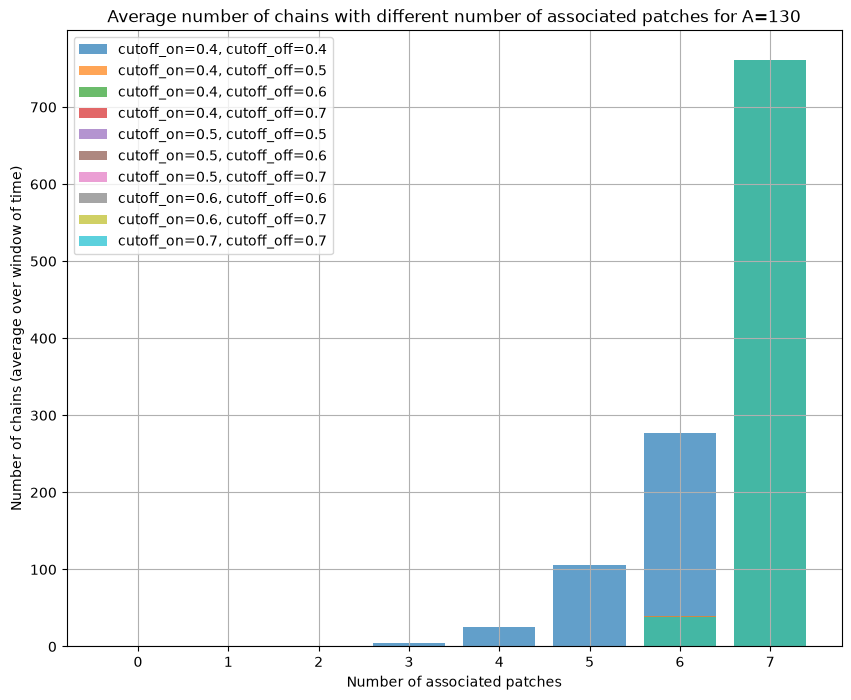

In [53]:
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

times = np.arange(0, 20, 0.002) # 10000 samples
# s=2

for A in As:
    fig = plt.figure(figsize=(10,8))
    for cutoff_on in cutoffs:
        for cutoff_off in cutoffs:
            if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
                s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                num_associated_list = {}
                for s in range(0, 128, 1):
                    try:
                        num_associated = count_associated(s)
                        if num_associated not in num_associated_list:
                            num_associated_list[num_associated] = 0
                        num_associated_list[num_associated] += np.mean(s_counts_df[f'{s}'][100:])  # Average number density of chains in state s
                    except KeyError:
                        num_associated_list[count_associated(s)] = 0
                        print(f"Did not find s={s} in the dataframe, setting num_associated to 0.")
                plt.bar(num_associated_list.keys(), num_associated_list.values(), alpha=0.7, label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")

                # plt.plot(times[:len(s_counts_df)], s_counts_df[f'{s}'], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")




    plt.xlabel(f"Number of associated patches")
    plt.ylabel(f"Number of chains (average over window of time)")
    # print(f"nu_s(s={s}) = {nu_s(s, 1/5.58, 1/7.27, 5, 31, 0.0274)}")
    # plt.axhline(nu_s(s, 1/11.09, 1/5.42, 5, 31, 0.0274), color='r', linestyle='--', label=f"nu_s(s={s})")
    plt.title(f"Average number of chains with different number of associated patches for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()

## Calculating $\nu^s$ spectrum for an input $\alpha, \beta$

In [54]:
def nu_s_spectrum(alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    s_spectrum = {}
    for s in range(0, 2**N_a):
        s_spectrum[s] = nu_s(s, alpha, beta, M, N_b, n_c)
    return s_spectrum


Let's look at A = 120 first, a midrange with some interactions. 

In [55]:
from scipy.stats import chisquare

def fit_nu_s_spectrum(A):
    lifetime_df = pd.read_csv("data/lifetimes/tau_lifetimes.csv")
    offtime_df = pd.read_csv("data/offtimes/tau_offtimes.csv")

    lowest_chisquare = float('inf')
    best_cutoff_on = None
    best_cutoff_off = None
    for cutoff_on in cutoffs:
        for cutoff_off in cutoffs:
            if cutoff_on <= cutoff_off: # only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
                fig = plt.figure(figsize=(10,8))

                s_counts_df = pd.read_csv(f"data/s_states/buffered_s_counts_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                s_list = np.arange(0, 128, 1)
                nu_s_avg_list = []
                for s in s_list:
                    try:
                        nu_s_avg_list.append(np.mean(s_counts_df[f'{s}'][100:]) / box_volume)  # Average number density of chains in state s
                    except KeyError:
                        nu_s_avg_list.append(0)
                        # print(f"Did not find s={s} in the dataframe, setting nu_s_avg to 0.")
                plt.plot(s_list, nu_s_avg_list, label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")

                # plt.plot(times[:len(s_counts_df)], s_counts_df[f'{s}'], label=f"cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                try:
                    print(offtime_df.loc[(offtime_df['A'] == A) & (offtime_df['cutoff_on'] == cutoff_on)  & (offtime_df['cutoff_off'] == cutoff_off), 'tau_2'])
                    tau_on = offtime_df.loc[(offtime_df['A'] == A) & (offtime_df['cutoff_on'] == cutoff_on) & (offtime_df['cutoff_off'] == cutoff_off), 'tau_2'].values[0]
                    tau_off = lifetime_df.loc[(lifetime_df['A'] == A) & (lifetime_df['cutoff_on'] == cutoff_on) & (lifetime_df['cutoff_off'] == cutoff_off), 'tau_2'].values[0]

                    alpha = 1 / tau_on
                    beta = 1 / tau_off

                    nu_s_spectrum_dict = nu_s_spectrum(alpha, beta, 5, 31, n_c=0.0274)
                    plt.plot(nu_s_spectrum_dict.keys(), nu_s_spectrum_dict.values(), color='red', linestyle='--', label=f"calculated nu_s(s) w/ alpha={alpha:.4f}, beta={beta:.4f}")
                    # print(len(nu_s_avg_list))
                    # print(len(nu_s_spectrum_dict.values()))
                    calc_chisquare = chisquare(nu_s_avg_list, list(nu_s_spectrum_dict.values()), sum_check=False)[0]
                    if calc_chisquare < lowest_chisquare:
                        lowest_chisquare = calc_chisquare
                        best_cutoff_on = cutoff_on
                        best_cutoff_off = cutoff_off
                    print("chi squared for {cutoff_on} {cutoff_off} is {chi2}".format(cutoff_on=cutoff_on, cutoff_off=cutoff_off, chi2=calc_chisquare))
                except IndexError:
                    print(f"Could not find tau_on or tau_off for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}. Skipping nu_s(s) plot.")
                
                plt.xlabel(f"s (association state)")
                plt.ylabel(f"Number density of chains (average over window of time)")
                plt.title(f"Average number density of chains in association states for A={A} compared with theoretical nu_s(s)")
                plt.grid(True)
                plt.legend()
                plt.show()
    print(f"Lowest chi squared value: {lowest_chisquare} for cutoff_on={best_cutoff_on}, cutoff_off={best_cutoff_off}")

## Fit for $A=90$

Series([], Name: tau_2, dtype: float64)
Could not find tau_on or tau_off for A=90, cutoff_on=0.4, cutoff_off=0.4. Skipping nu_s(s) plot.


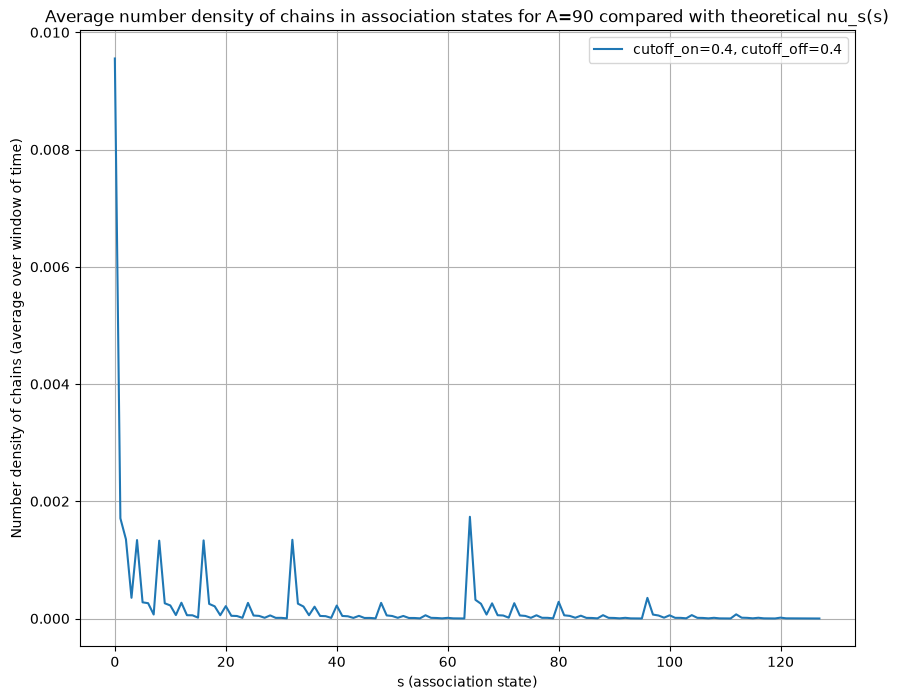

9    16.28393
Name: tau_2, dtype: float64
chi squared for 0.4 0.5 is 23.93118663386581


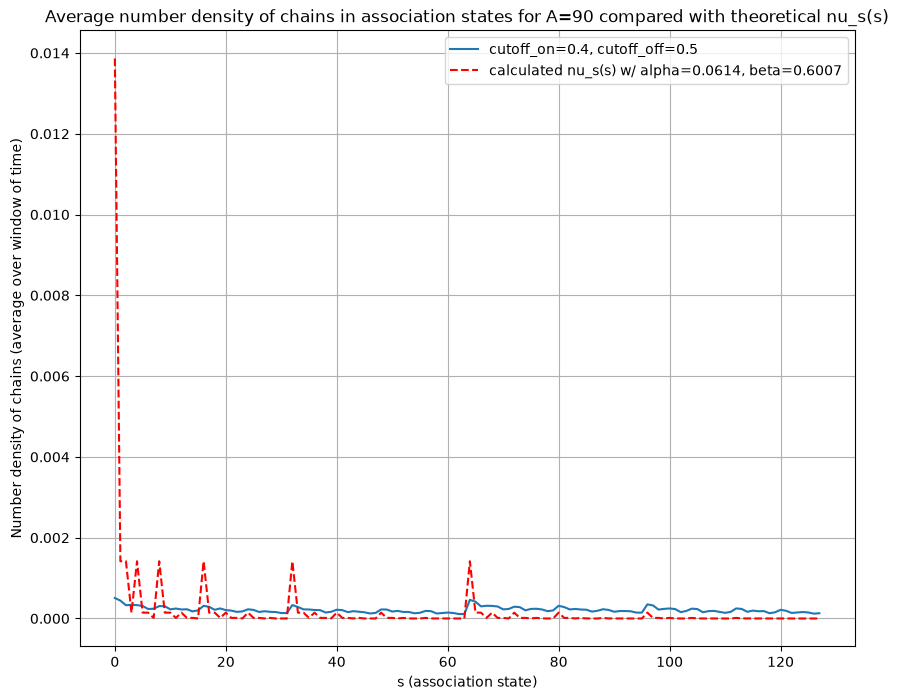

10    16.34839
Name: tau_2, dtype: float64
chi squared for 0.4 0.6 is 0.005796294060007851


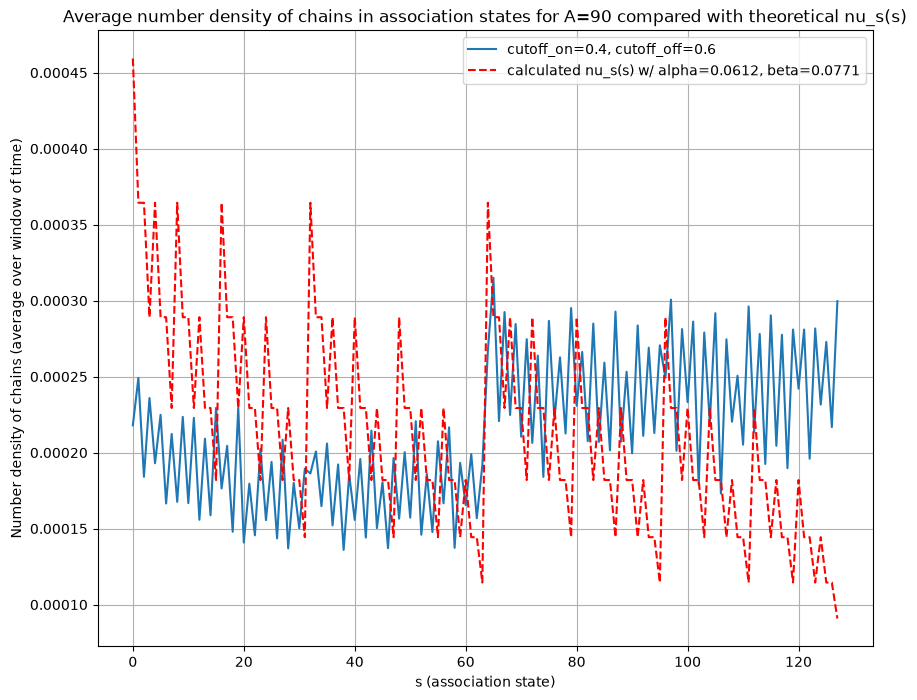

11    16.329689
Name: tau_2, dtype: float64
chi squared for 0.4 0.7 is 0.0013916550420411742


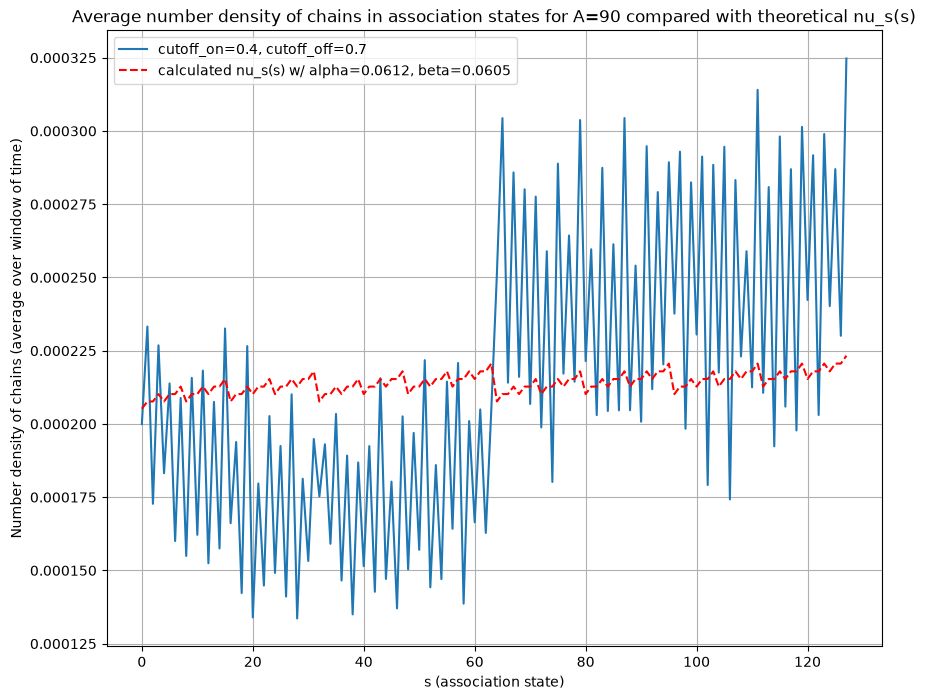

12    14.618101
Name: tau_2, dtype: float64
chi squared for 0.5 0.5 is 4.1138720027933955


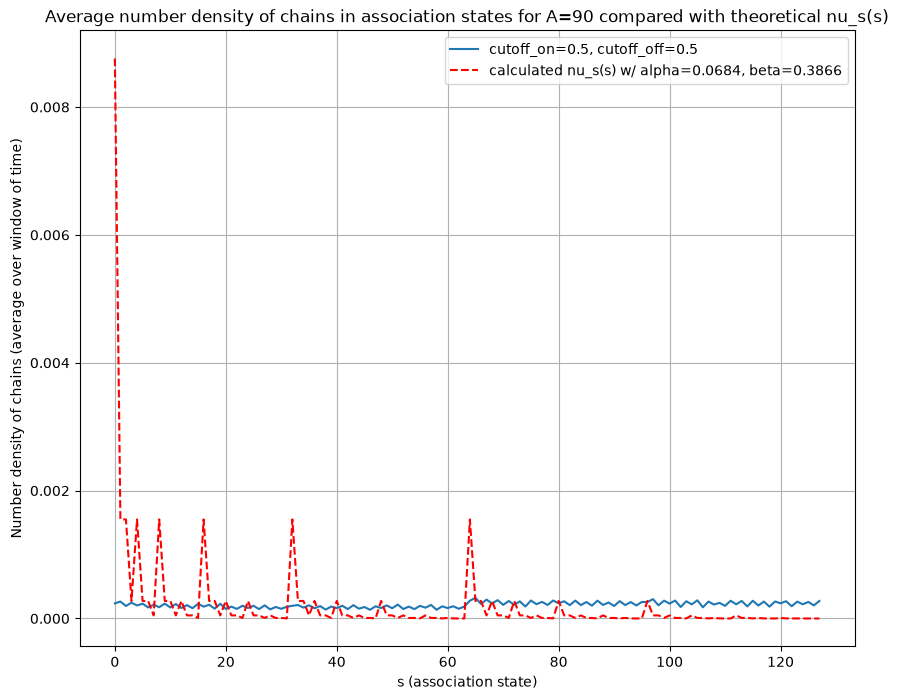

13    14.975568
Name: tau_2, dtype: float64
chi squared for 0.5 0.6 is 0.005155587821977519


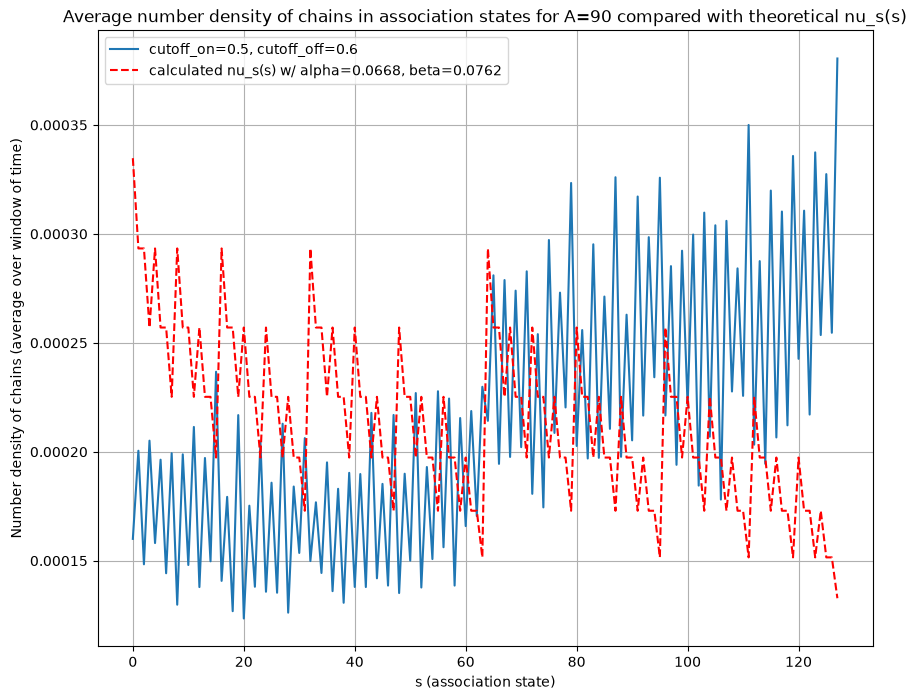

14    14.909402
Name: tau_2, dtype: float64
chi squared for 0.5 0.7 is 0.0013454652599839472


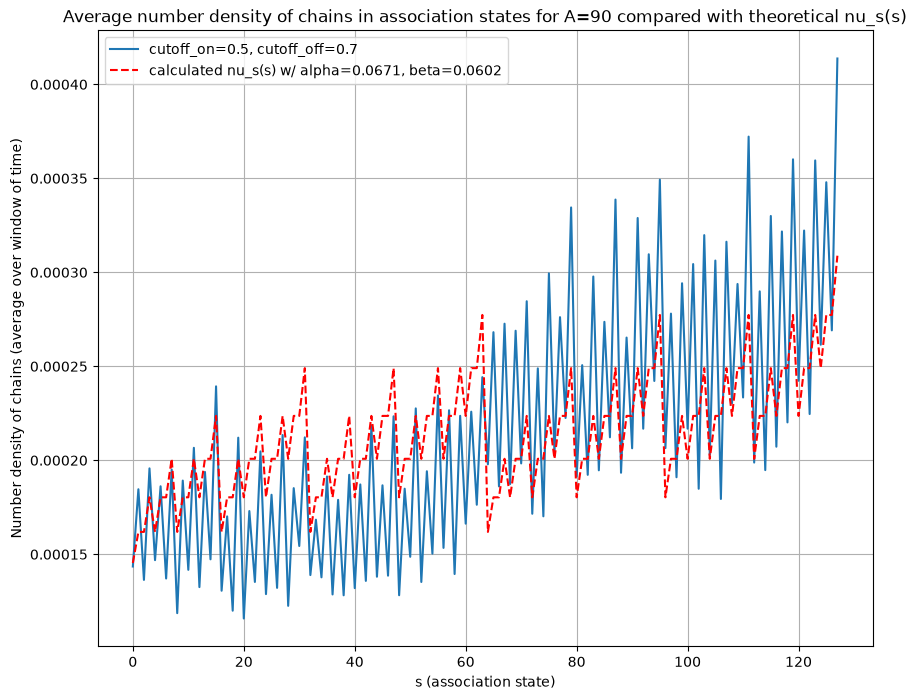

15    13.79212
Name: tau_2, dtype: float64
chi squared for 0.6 0.6 is 0.0038187273034205474


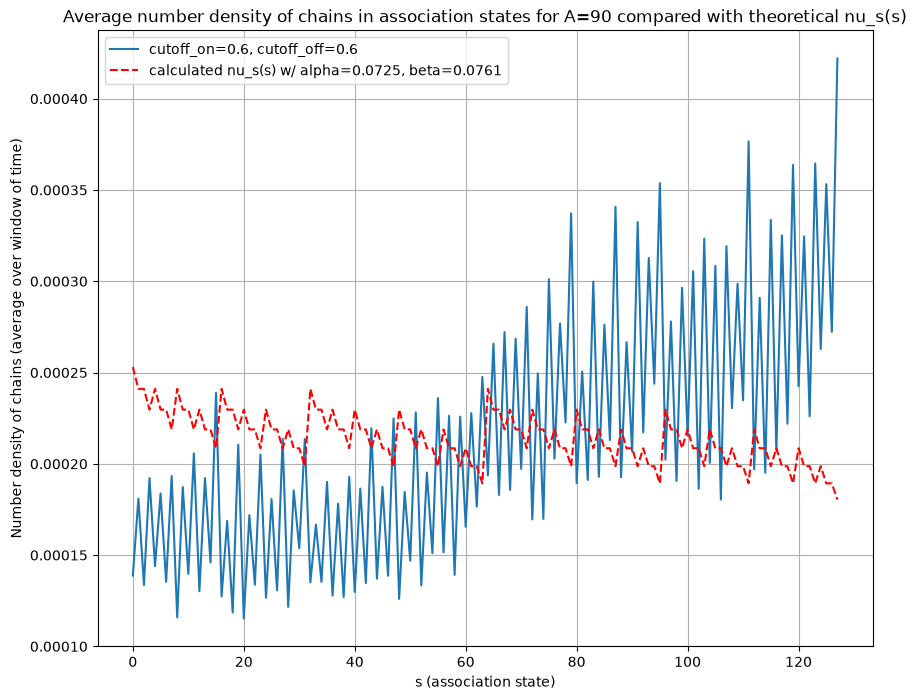

16    13.983735
Name: tau_2, dtype: float64
chi squared for 0.6 0.7 is 0.001180144207454342


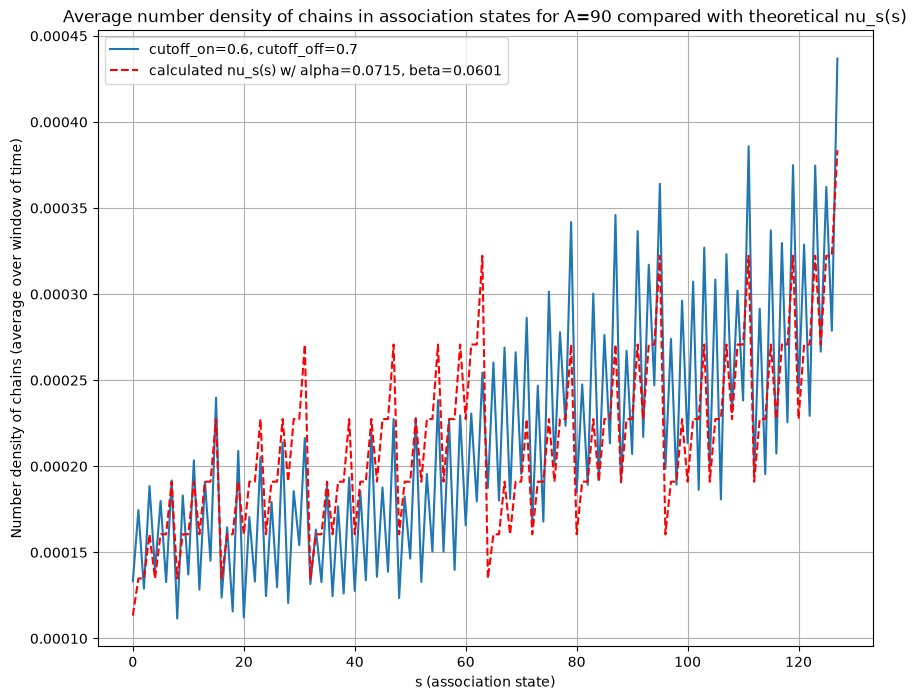

17    10.383091
Name: tau_2, dtype: float64
chi squared for 0.7 0.7 is 0.0046344133033072955


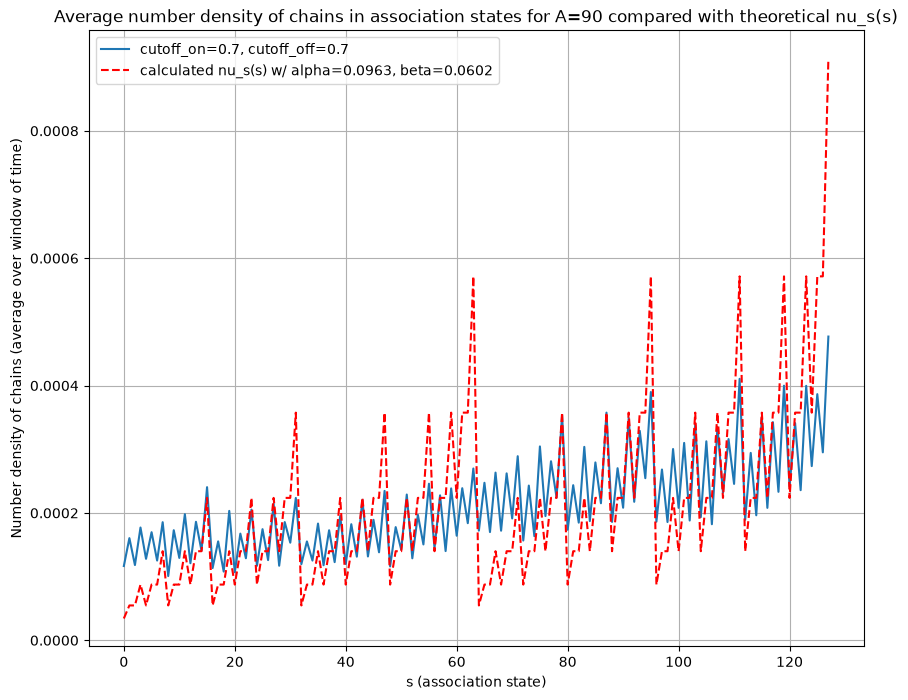

Lowest chi squared value: 0.001180144207454342 for cutoff_on=0.6, cutoff_off=0.7


In [56]:
fit_nu_s_spectrum(90)

## Fit for $A=100$

Series([], Name: tau_2, dtype: float64)
Could not find tau_on or tau_off for A=100, cutoff_on=0.4, cutoff_off=0.4. Skipping nu_s(s) plot.


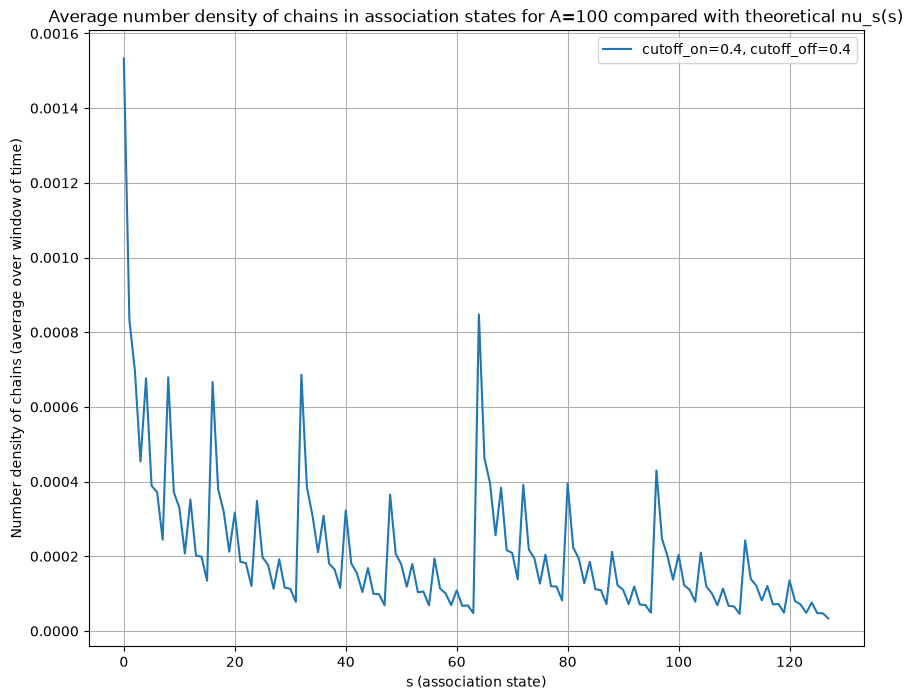

18    29.067277
Name: tau_2, dtype: float64
chi squared for 0.4 0.5 is 50.468339151968294


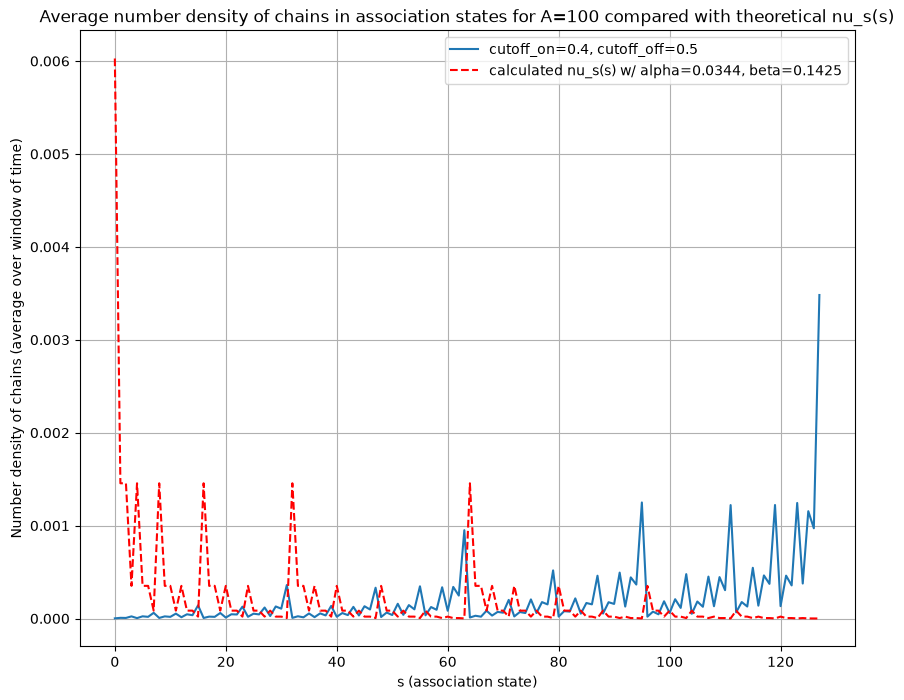

19    29.342829
Name: tau_2, dtype: float64
chi squared for 0.4 0.6 is 0.025497679238947416


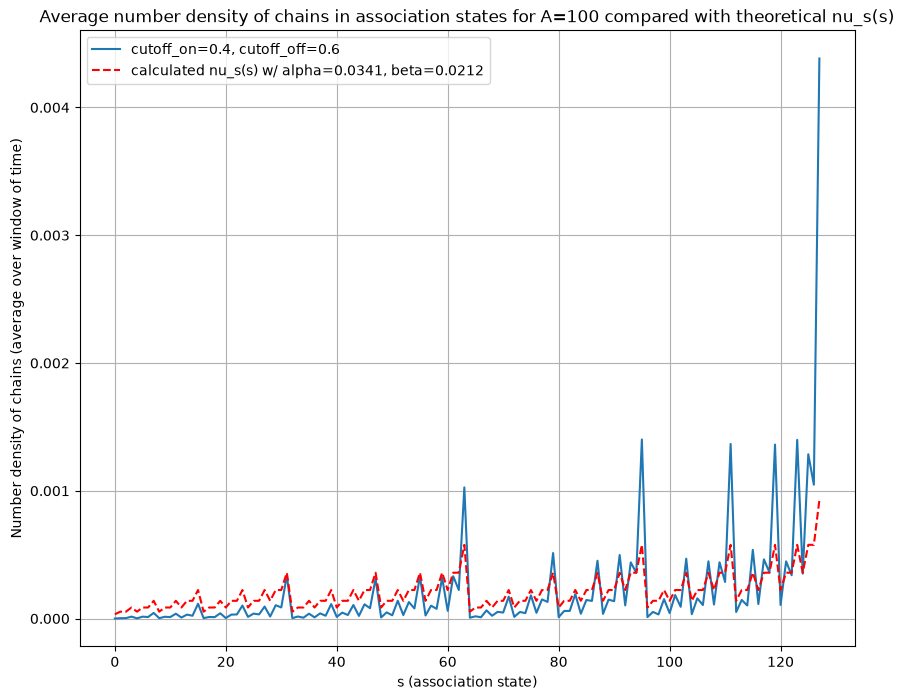

20    29.395663
Name: tau_2, dtype: float64
chi squared for 0.4 0.7 is 0.014542024592456956


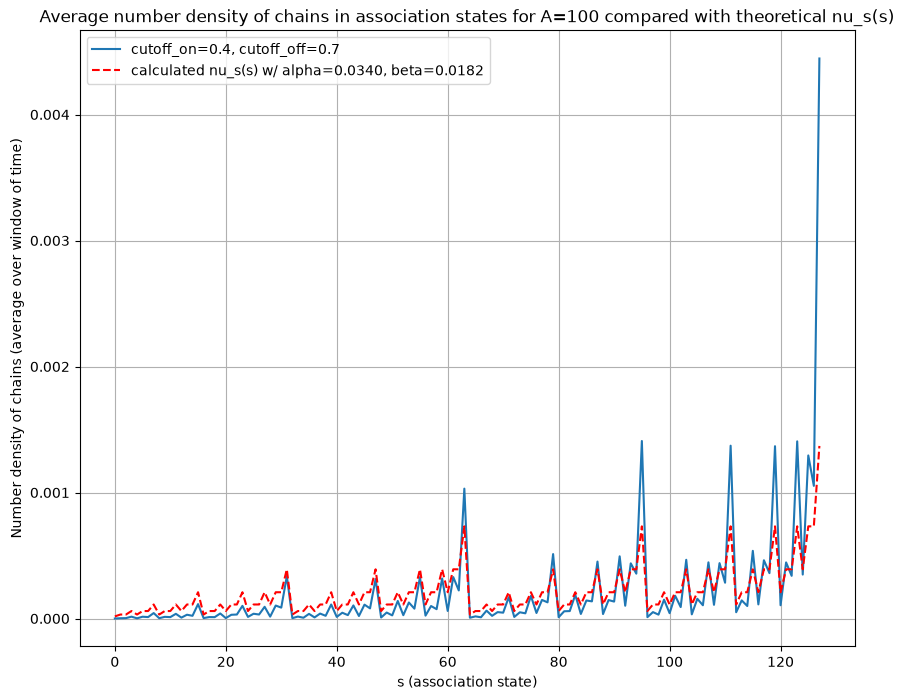

21    29.23283
Name: tau_2, dtype: float64
chi squared for 0.5 0.5 is 73.03350942415824


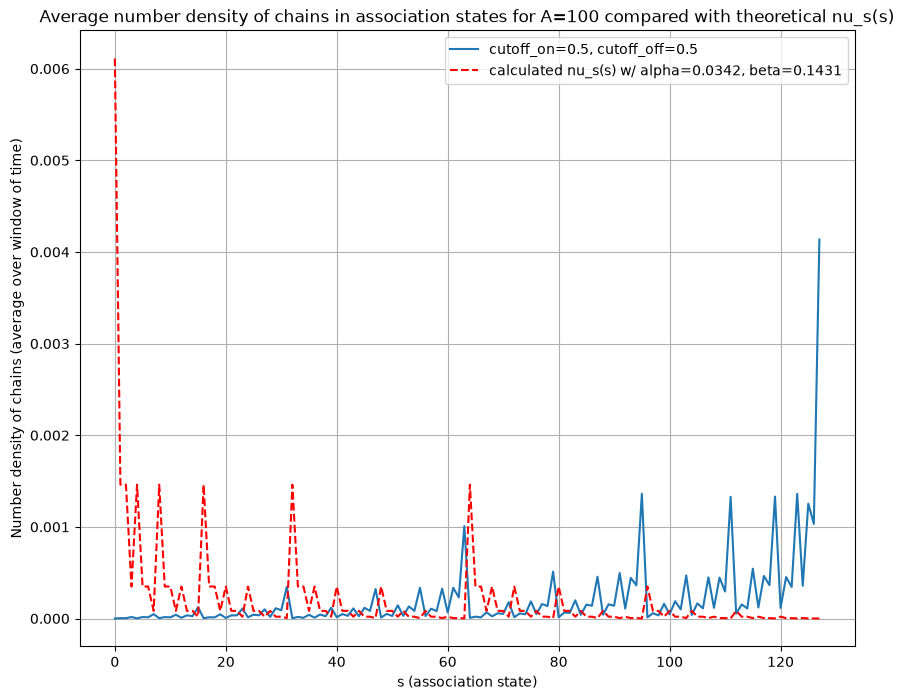

22    29.199666
Name: tau_2, dtype: float64
chi squared for 0.5 0.6 is 0.027573642785905628


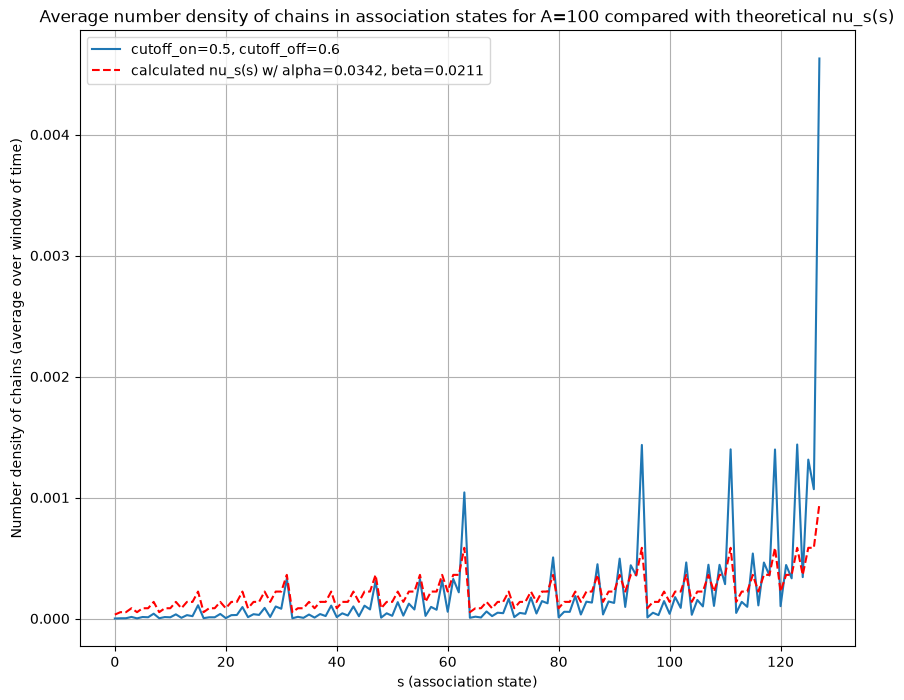

23    29.203355
Name: tau_2, dtype: float64
chi squared for 0.5 0.7 is 0.016050958630350092


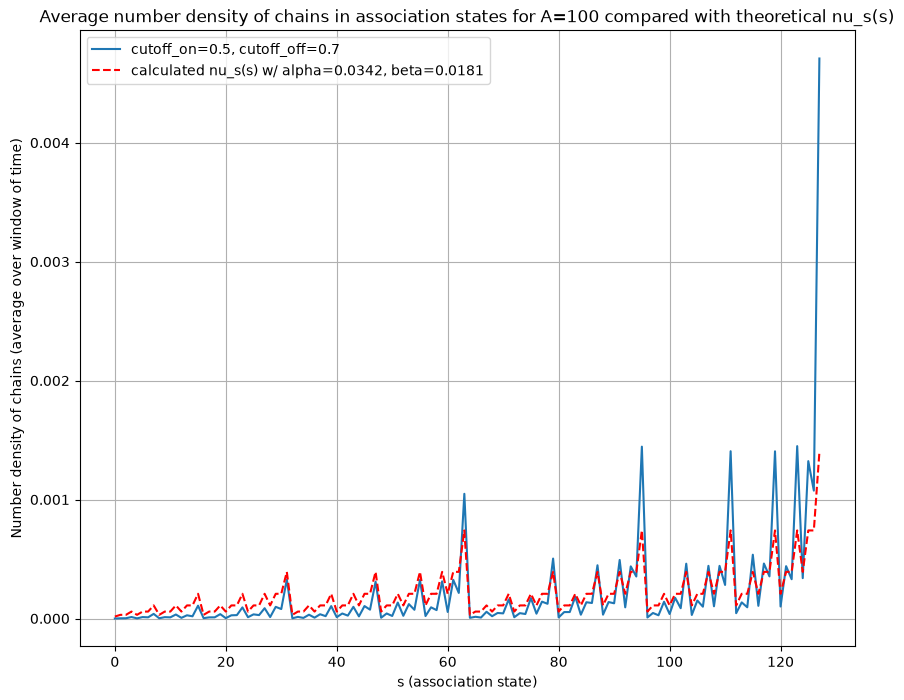

24    25.775138
Name: tau_2, dtype: float64
chi squared for 0.6 0.6 is 0.018155511274812144


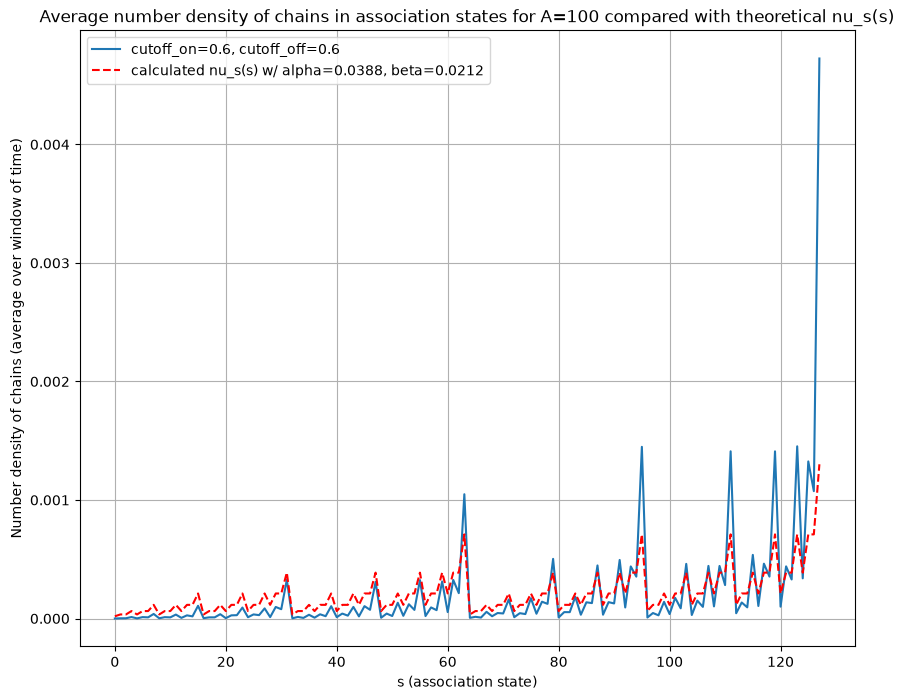

25    25.805233
Name: tau_2, dtype: float64
chi squared for 0.6 0.7 is 0.009626640798748259


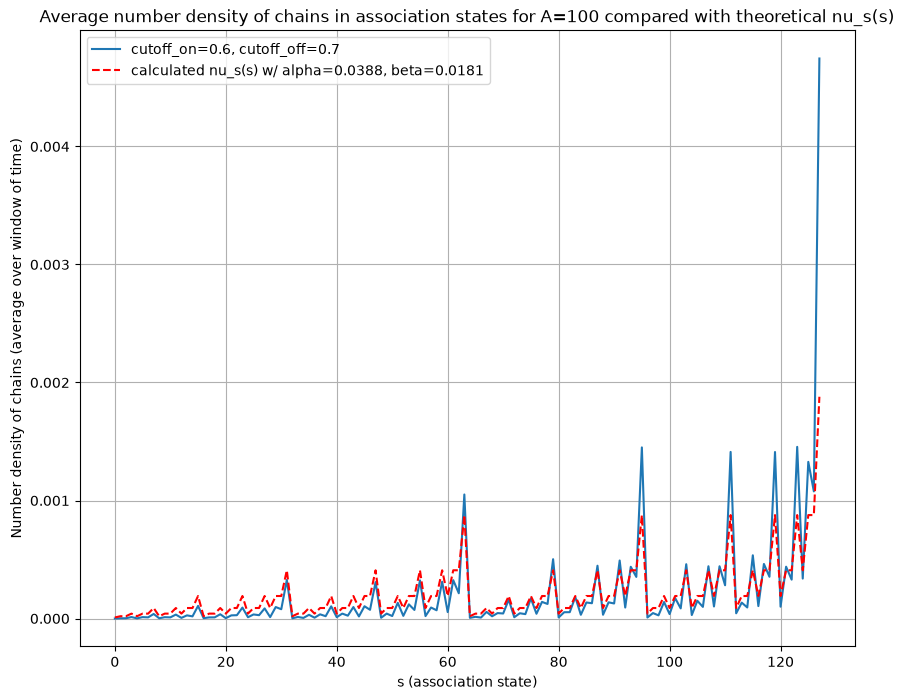

26    16.78567
Name: tau_2, dtype: float64
chi squared for 0.7 0.7 is 0.0010598057349790013


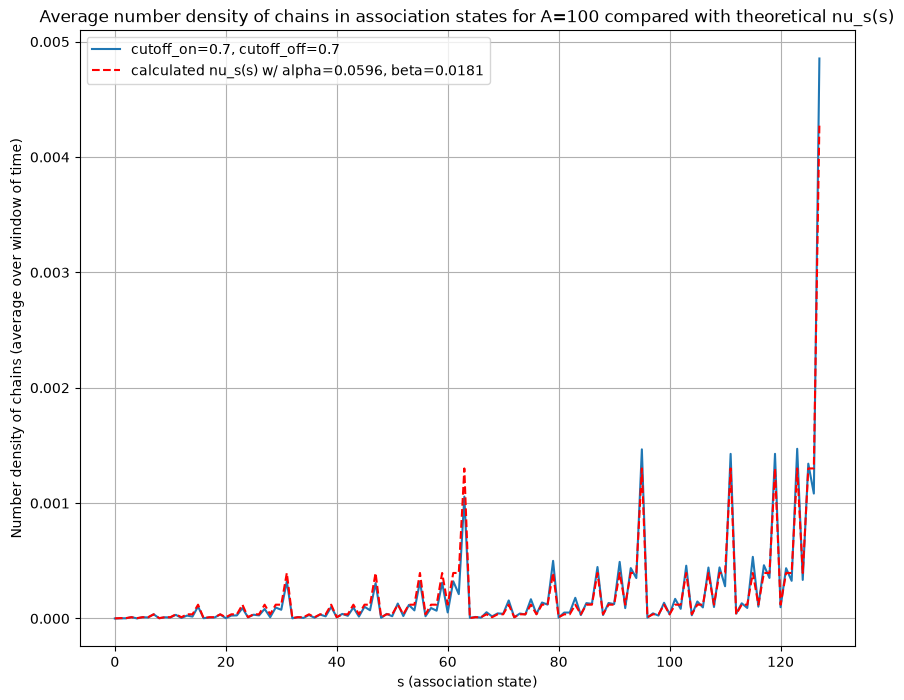

Lowest chi squared value: 0.0010598057349790013 for cutoff_on=0.7, cutoff_off=0.7


In [57]:
fit_nu_s_spectrum(100)

## Fit for $A=110$

Series([], Name: tau_2, dtype: float64)
Could not find tau_on or tau_off for A=110, cutoff_on=0.4, cutoff_off=0.4. Skipping nu_s(s) plot.


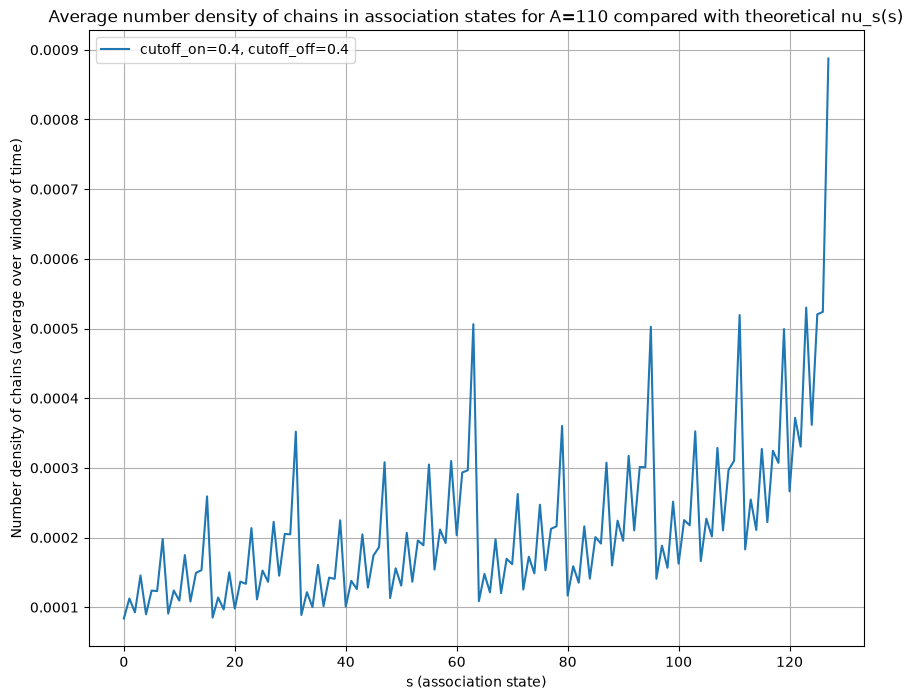

27    70.468832
Name: tau_2, dtype: float64
chi squared for 0.4 0.5 is 175.33944330908847


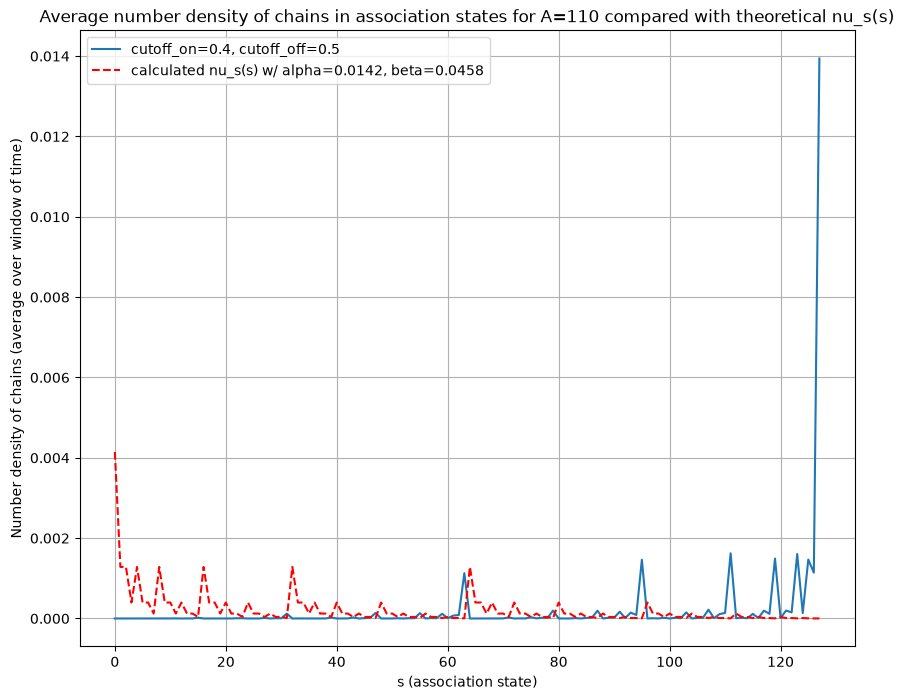

28    70.320261
Name: tau_2, dtype: float64
chi squared for 0.4 0.6 is 0.060300469177991256


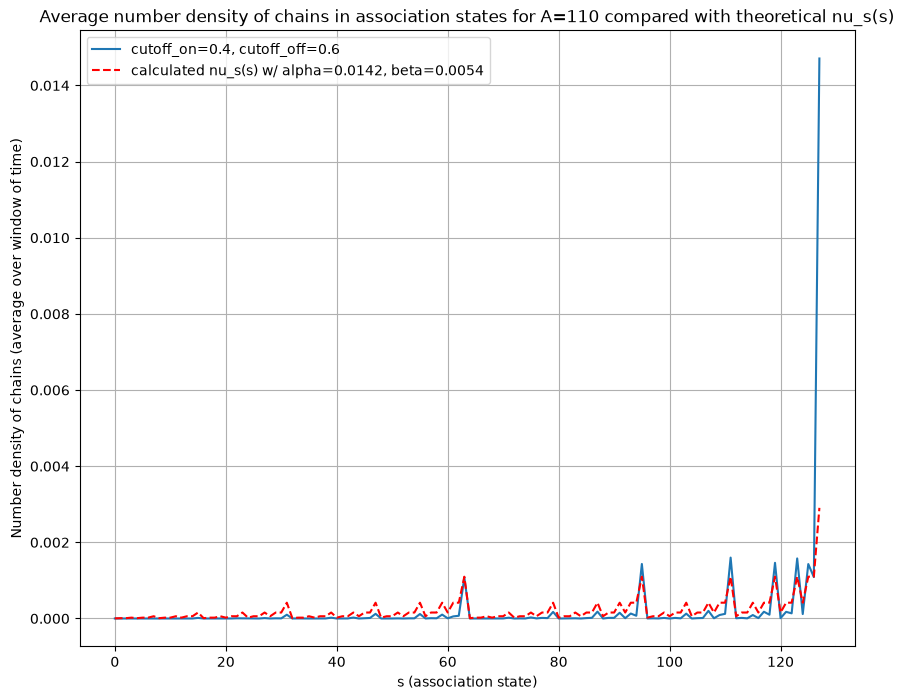

29    70.540453
Name: tau_2, dtype: float64
chi squared for 0.4 0.7 is 0.05715646856748105


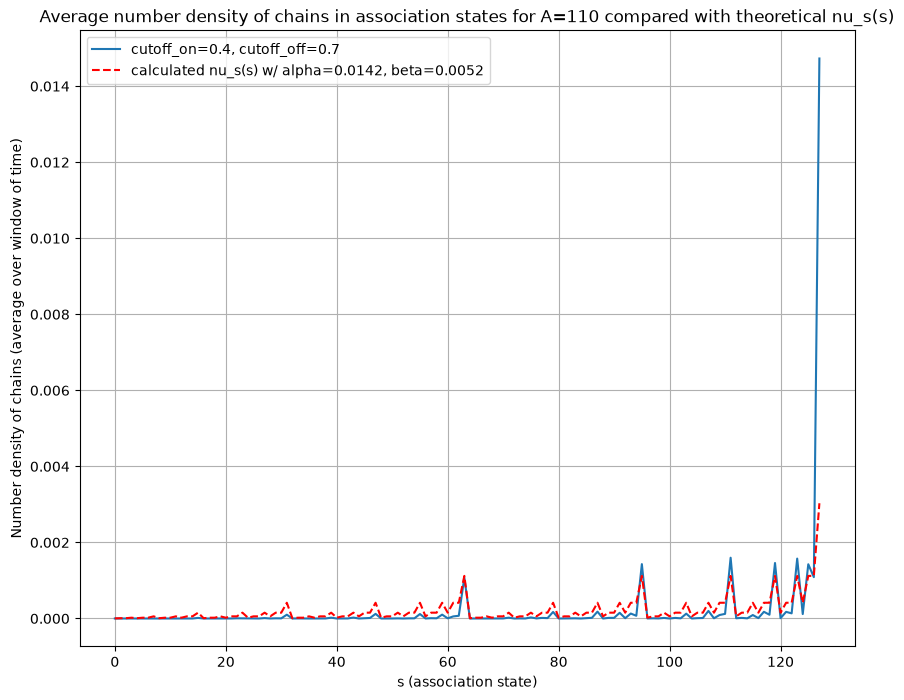

30    69.950431
Name: tau_2, dtype: float64
chi squared for 0.5 0.5 is 186.46316477556536


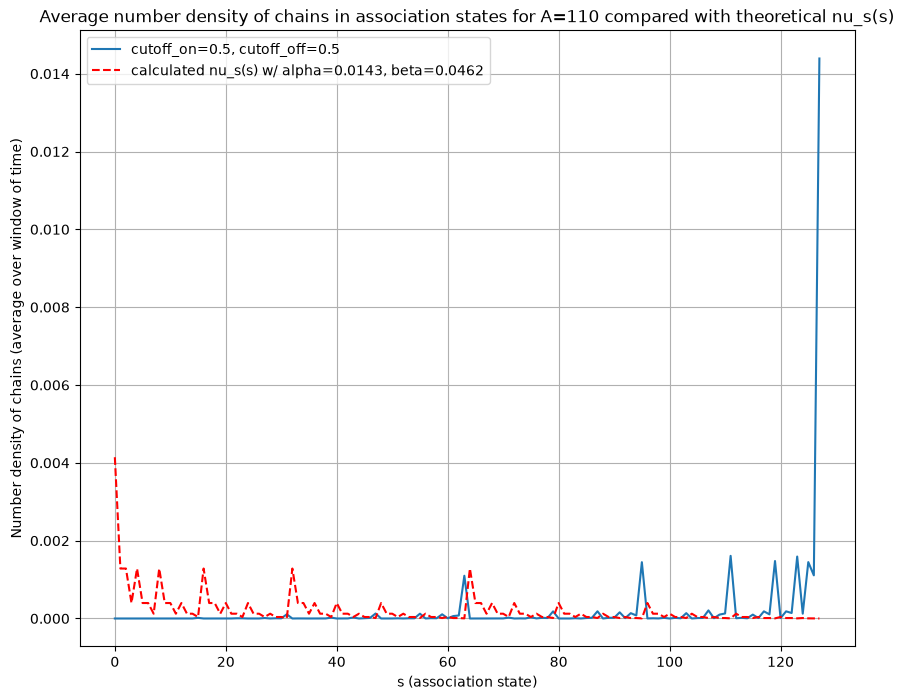

31    70.090713
Name: tau_2, dtype: float64
chi squared for 0.5 0.6 is 0.07150442293492382


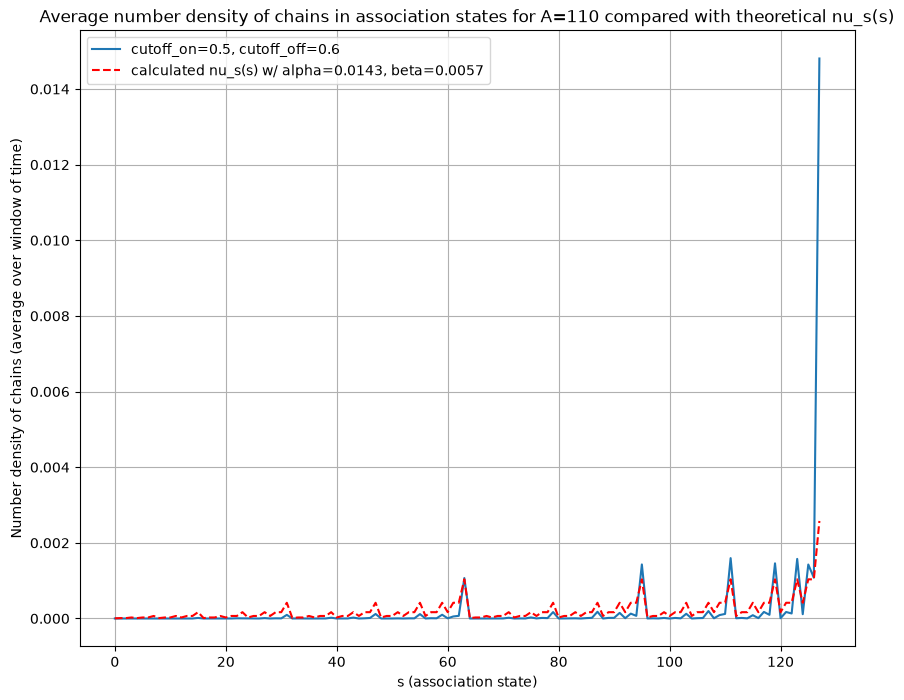

32    70.261065
Name: tau_2, dtype: float64
chi squared for 0.5 0.7 is 0.057497469836000376


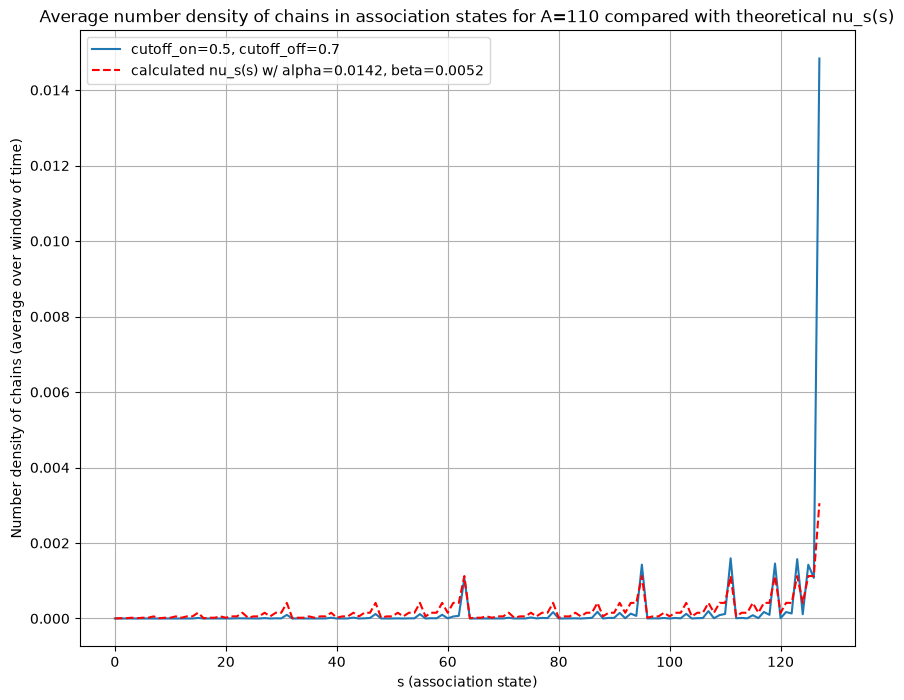

33    53.151039
Name: tau_2, dtype: float64
chi squared for 0.6 0.6 is 0.03547401380458381


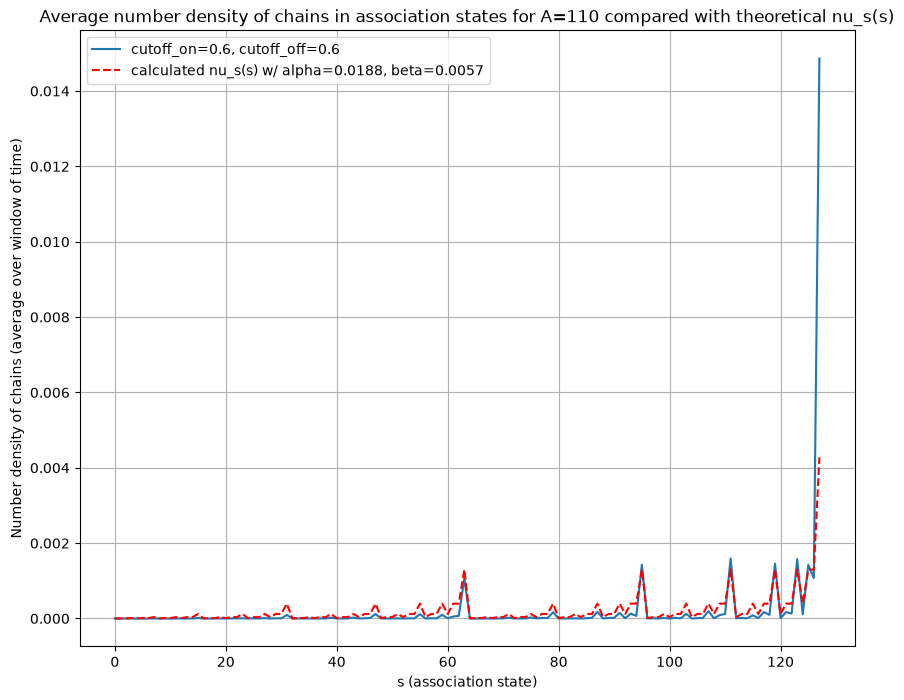

34    52.387931
Name: tau_2, dtype: float64
chi squared for 0.6 0.7 is 0.02726773742785779


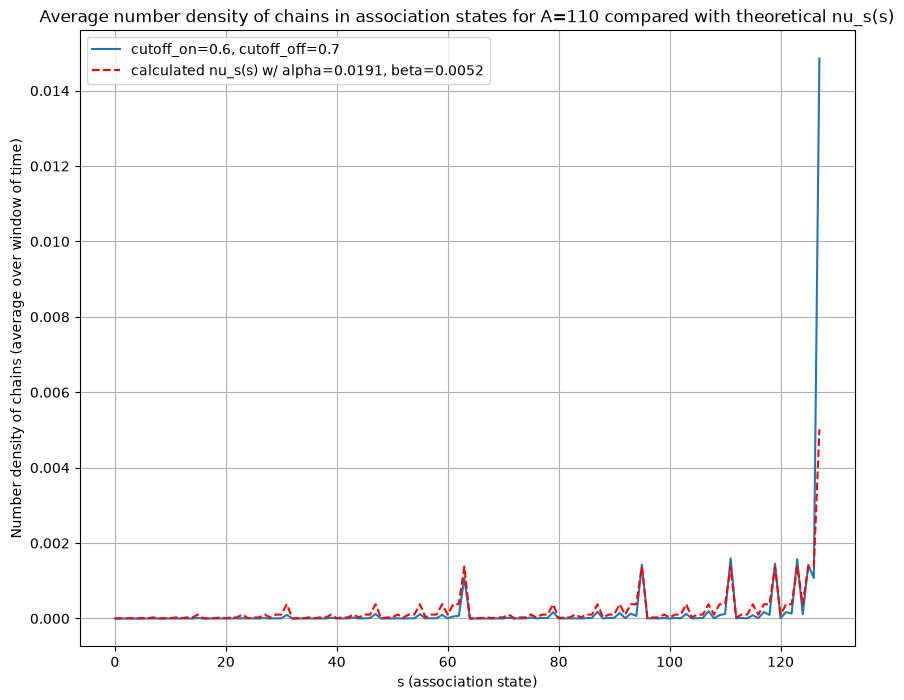

35    28.185124
Name: tau_2, dtype: float64
chi squared for 0.7 0.7 is 0.0042354043186203245


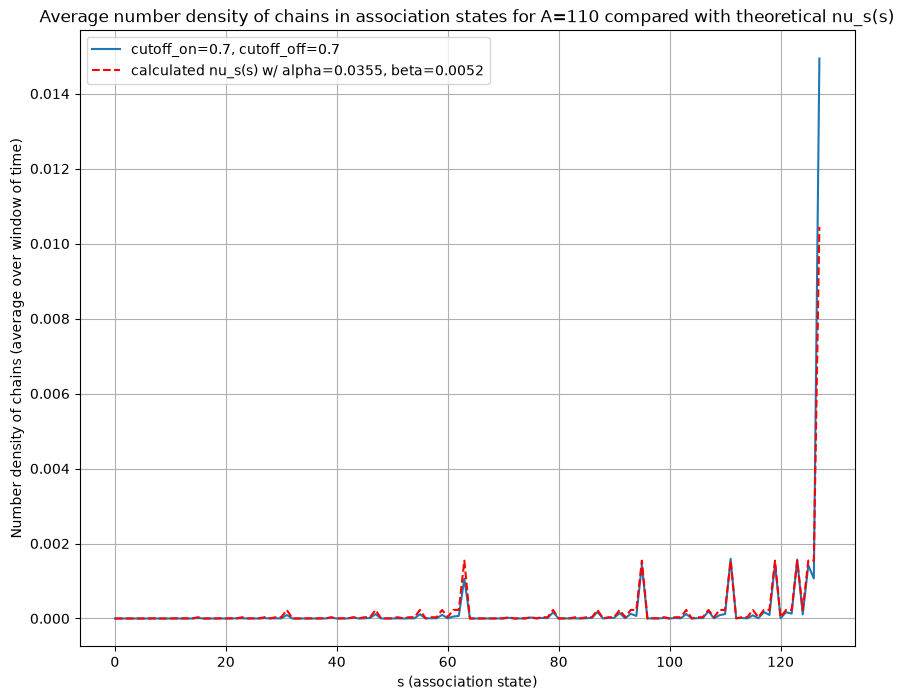

Lowest chi squared value: 0.0042354043186203245 for cutoff_on=0.7, cutoff_off=0.7


In [58]:
fit_nu_s_spectrum(110)

## Fit for $A=120$

Series([], Name: tau_2, dtype: float64)
Could not find tau_on or tau_off for A=120, cutoff_on=0.4, cutoff_off=0.4. Skipping nu_s(s) plot.


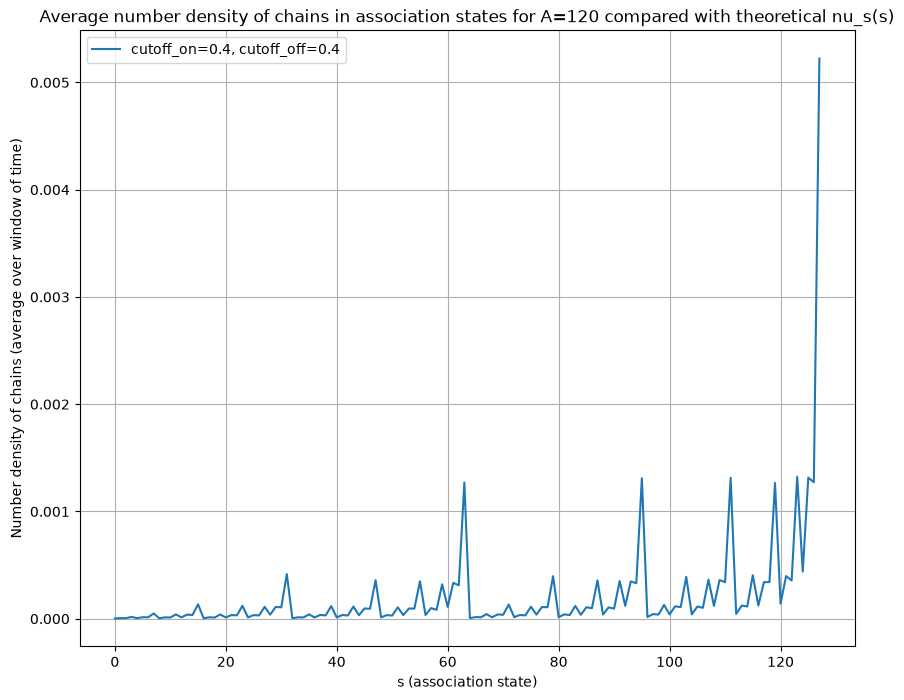

36    142.037965
Name: tau_2, dtype: float64
chi squared for 0.4 0.5 is 21.12705463262283


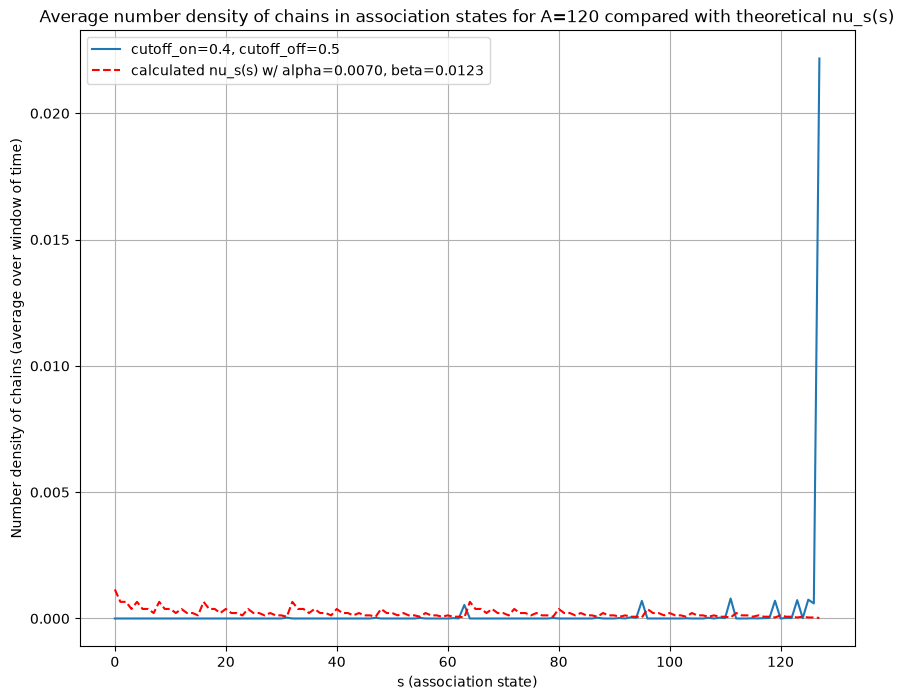

37    142.052969
Name: tau_2, dtype: float64
chi squared for 0.4 0.6 is 0.03412686596663973


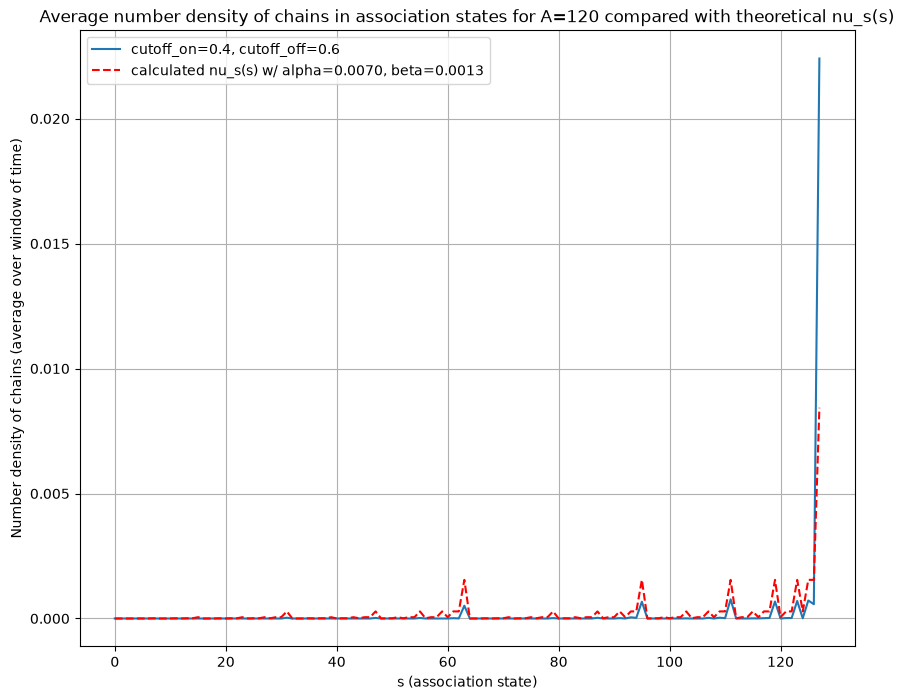

38    142.143882
Name: tau_2, dtype: float64
chi squared for 0.4 0.7 is 0.063616603654835


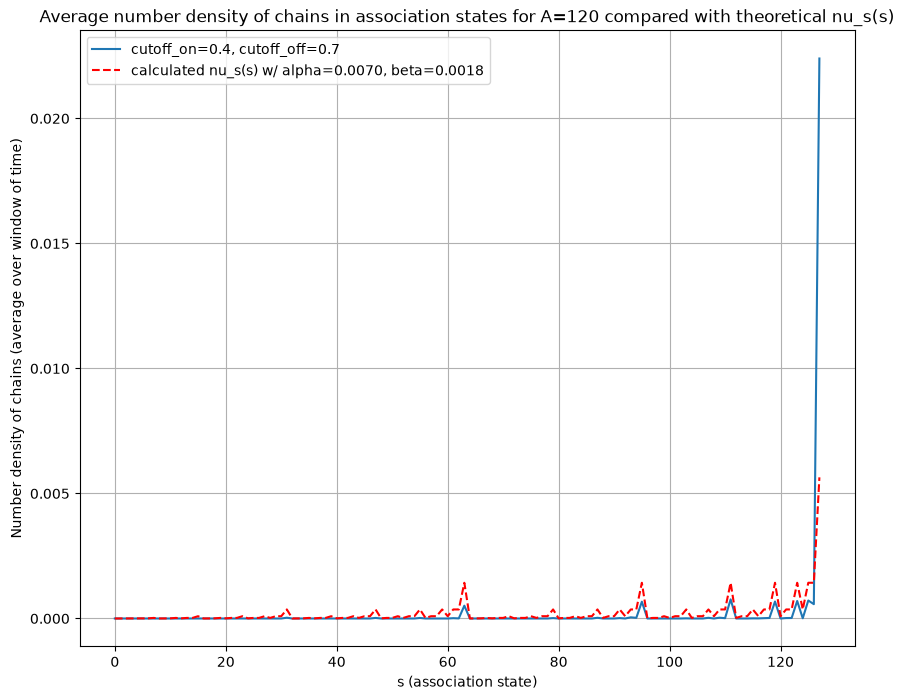

39    136.978787
Name: tau_2, dtype: float64
chi squared for 0.5 0.5 is 17.878286321665033


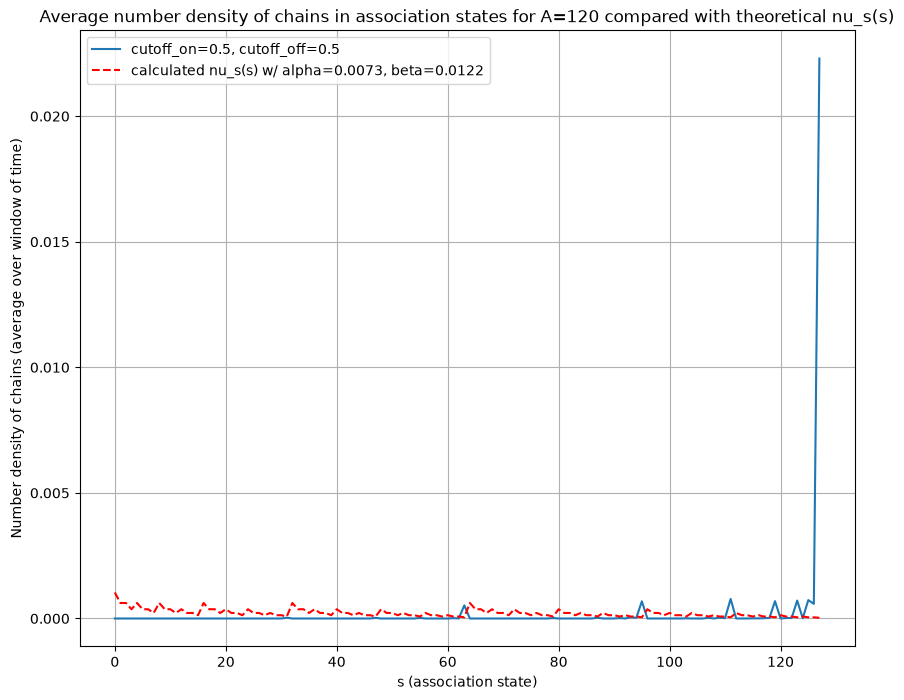

40    138.176545
Name: tau_2, dtype: float64
chi squared for 0.5 0.6 is 0.03252750591608827


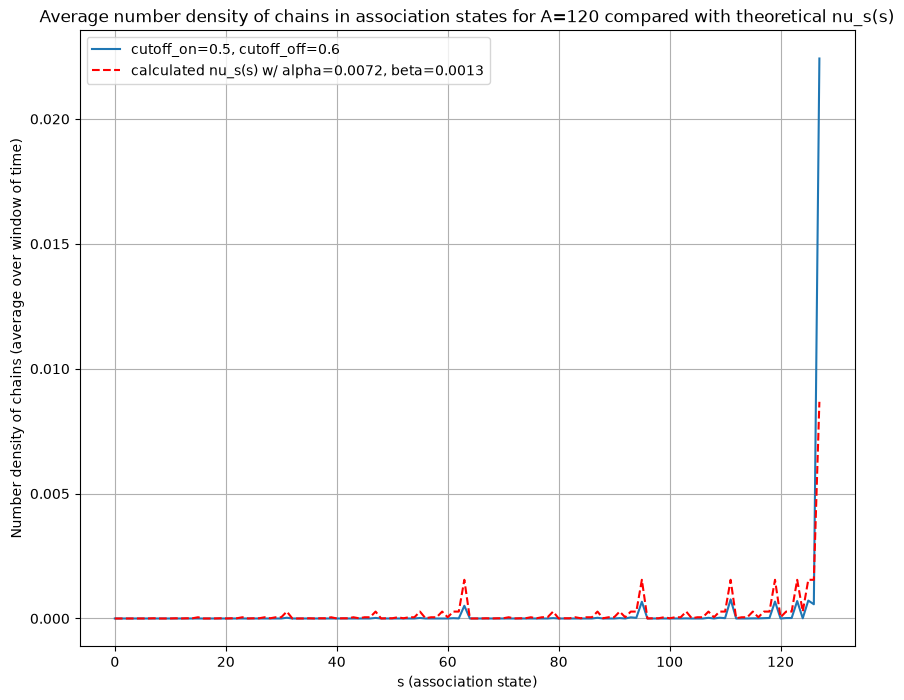

41    139.60178
Name: tau_2, dtype: float64
chi squared for 0.5 0.7 is 0.060261541588546144


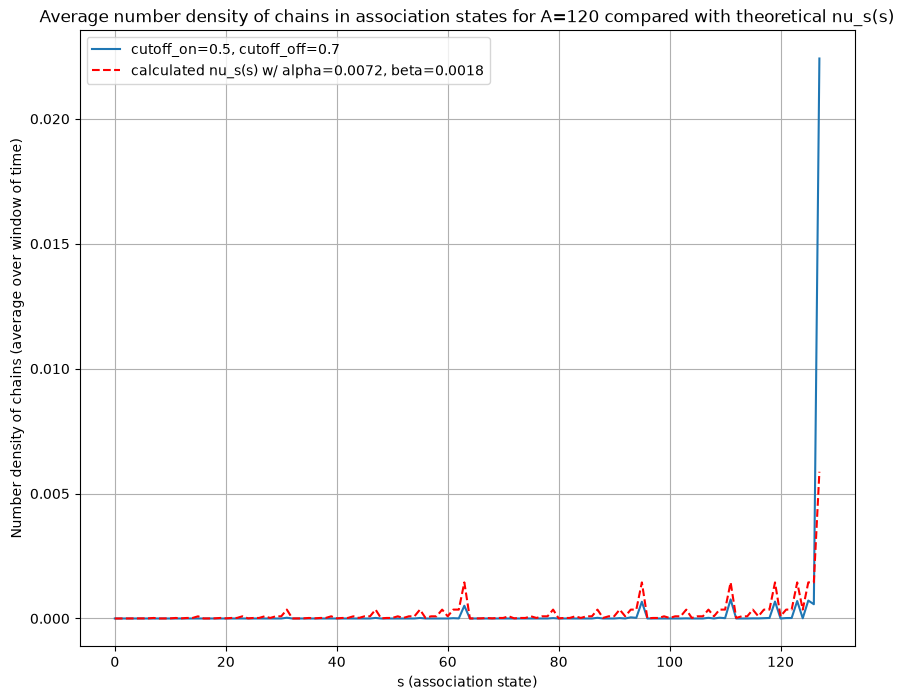

42    87.565052
Name: tau_2, dtype: float64
chi squared for 0.6 0.6 is 0.013626104042307189


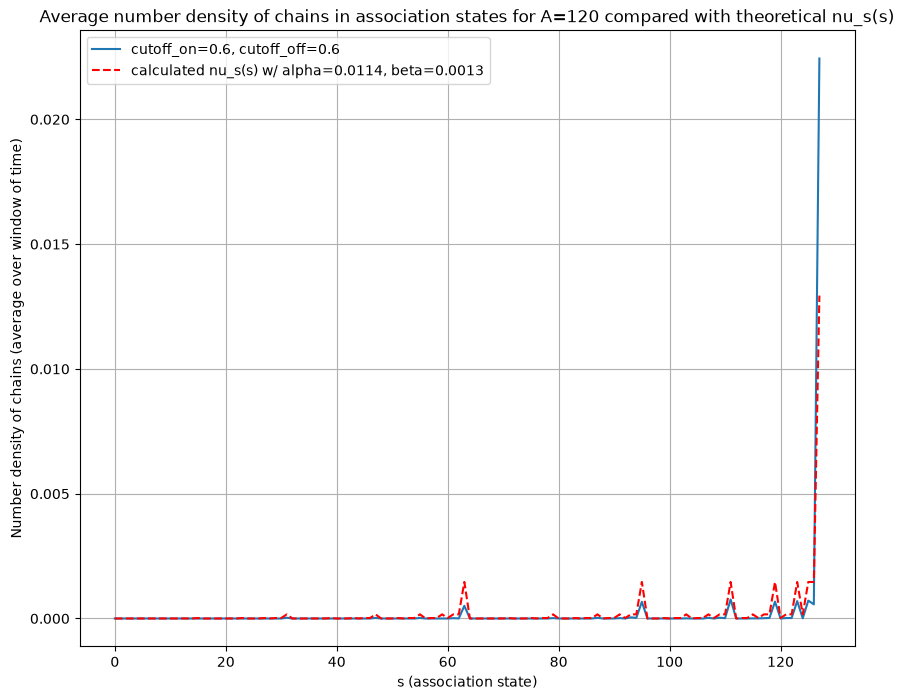

43    85.789291
Name: tau_2, dtype: float64
chi squared for 0.6 0.7 is 0.023745285564567817


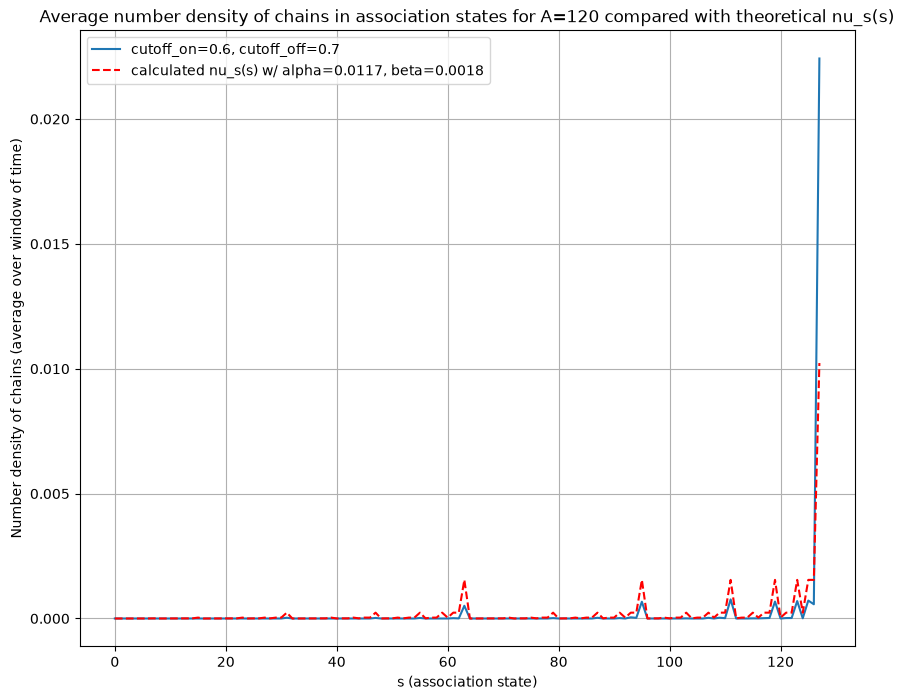

44    36.235751
Name: tau_2, dtype: float64
chi squared for 0.7 0.7 is 0.003762070045666224


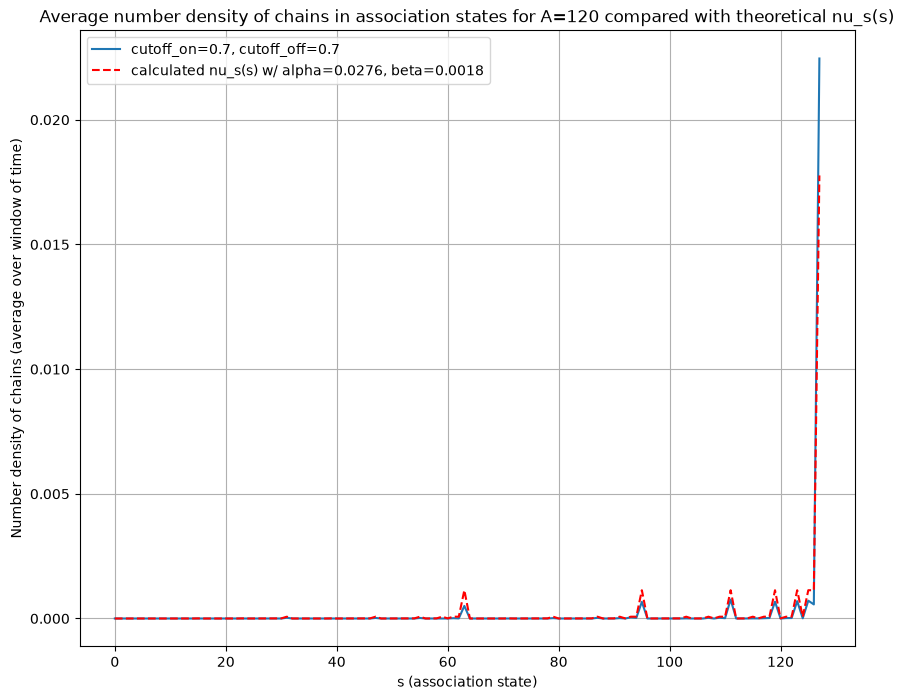

Lowest chi squared value: 0.003762070045666224 for cutoff_on=0.7, cutoff_off=0.7


In [59]:
fit_nu_s_spectrum(120)

## Fit for $A=130$

Series([], Name: tau_2, dtype: float64)
Could not find tau_on or tau_off for A=130, cutoff_on=0.4, cutoff_off=0.4. Skipping nu_s(s) plot.


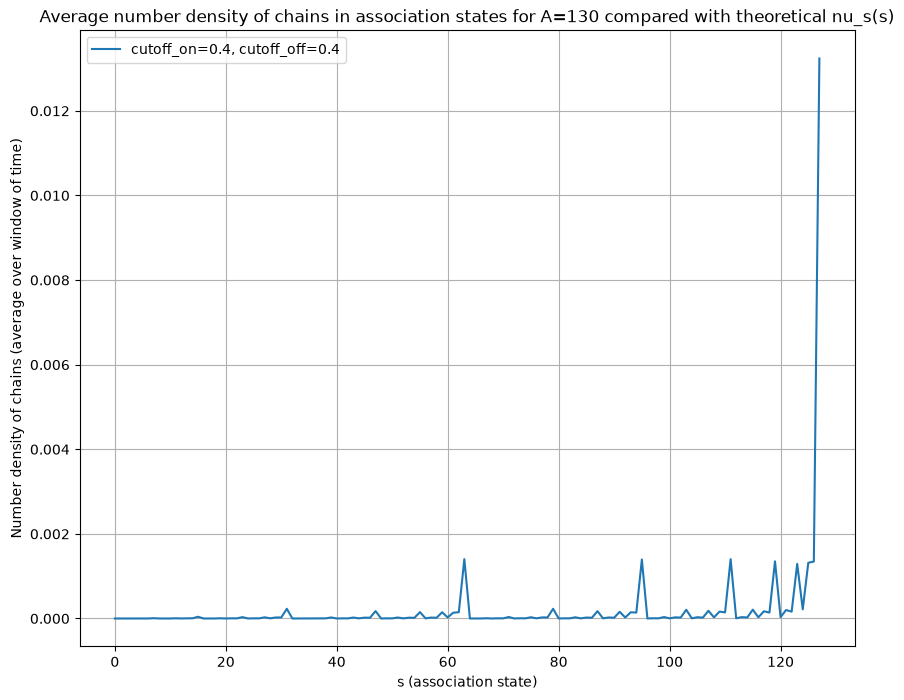

45    182.863693
Name: tau_2, dtype: float64
chi squared for 0.4 0.5 is 0.3449426891715005


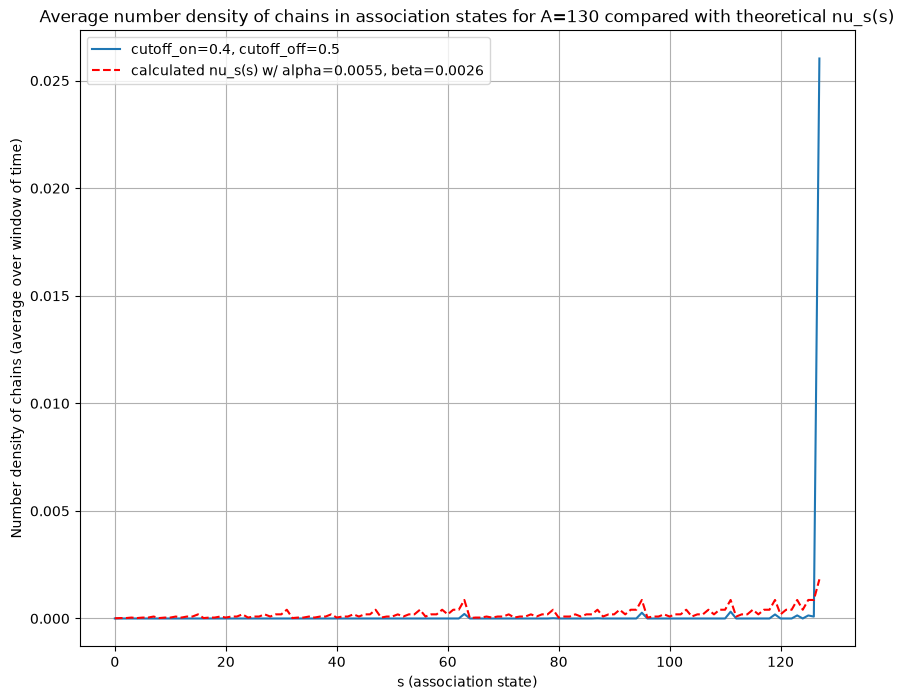

46    182.865842
Name: tau_2, dtype: float64
chi squared for 0.4 0.6 is 0.007884484978088349


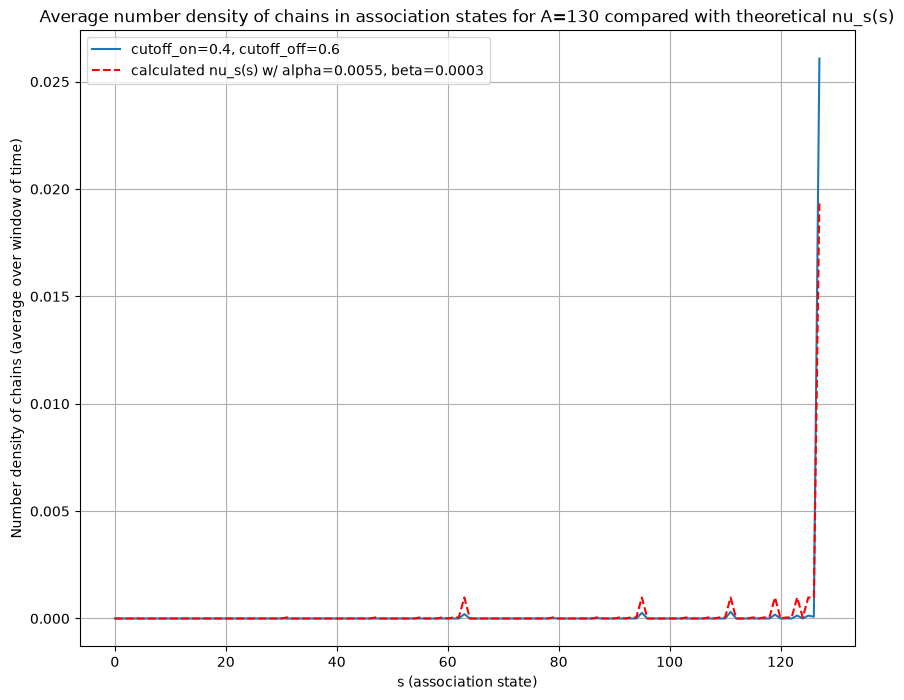

47    182.863693
Name: tau_2, dtype: float64
chi squared for 0.4 0.7 is 0.011650883309907182


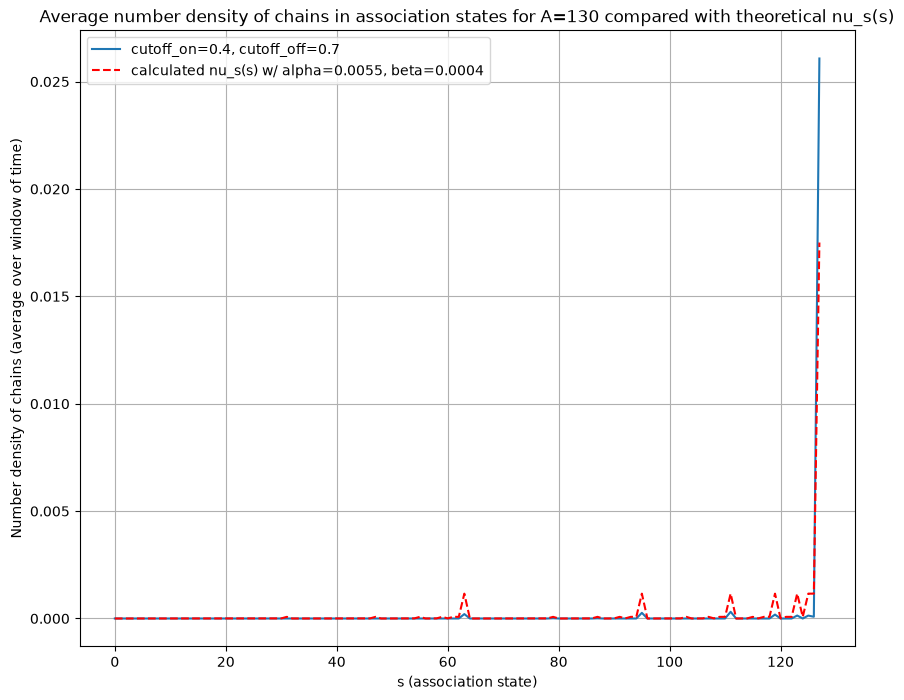

48    185.301849
Name: tau_2, dtype: float64
chi squared for 0.5 0.5 is 0.3548573057929015


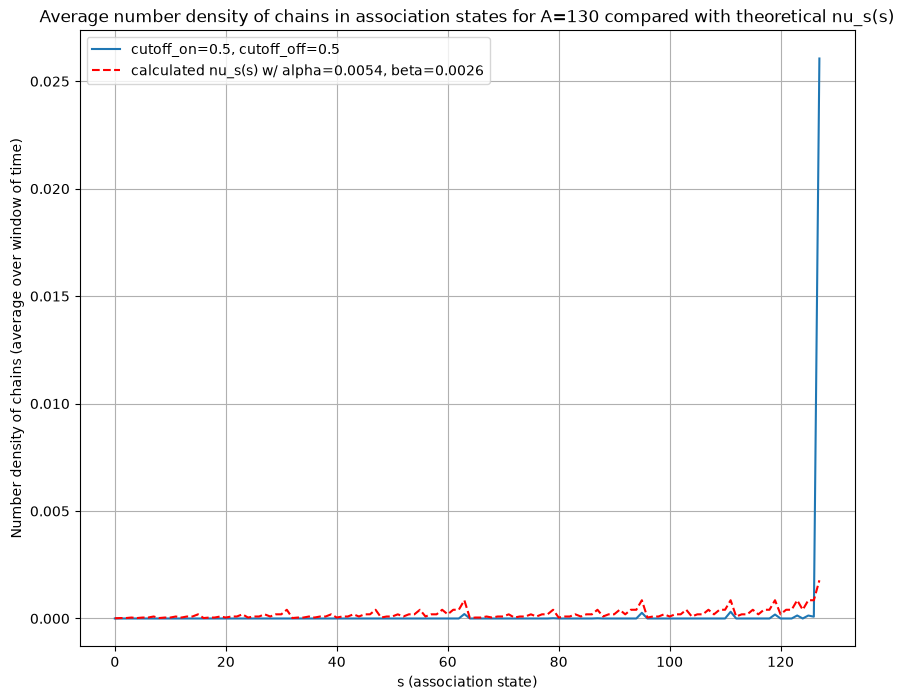

49    184.953039
Name: tau_2, dtype: float64
chi squared for 0.5 0.6 is 0.007955232816763275


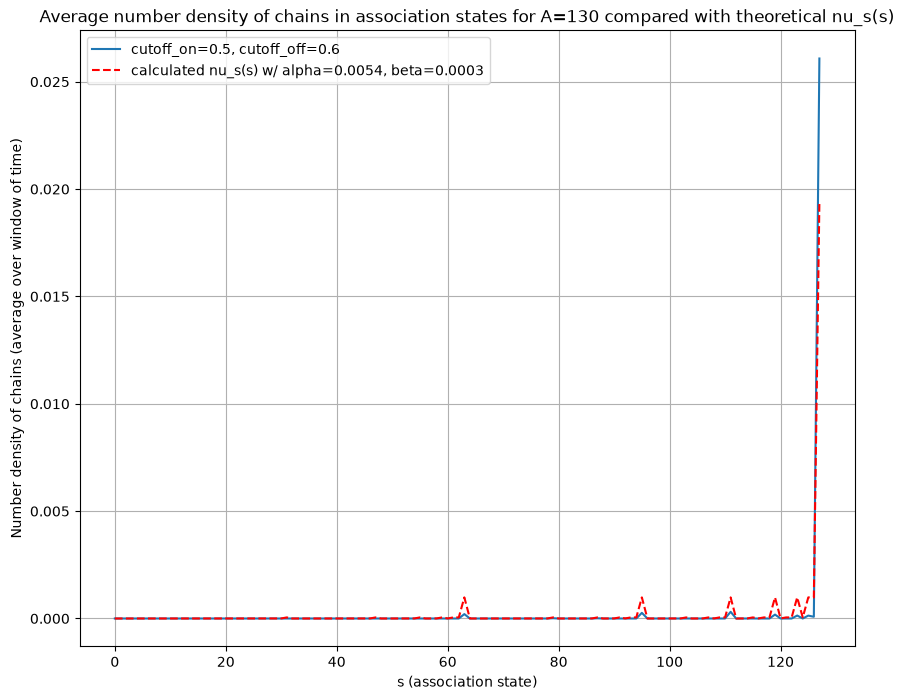

50    184.742995
Name: tau_2, dtype: float64
chi squared for 0.5 0.7 is 0.011790200490302645


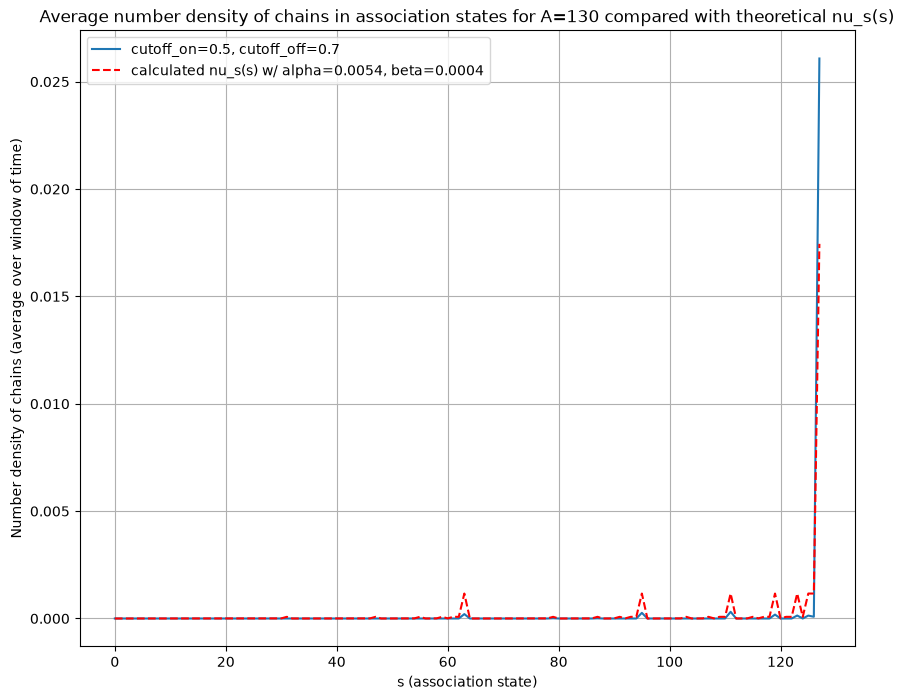

51    92.566777
Name: tau_2, dtype: float64
chi squared for 0.6 0.6 is 0.002662521130769839


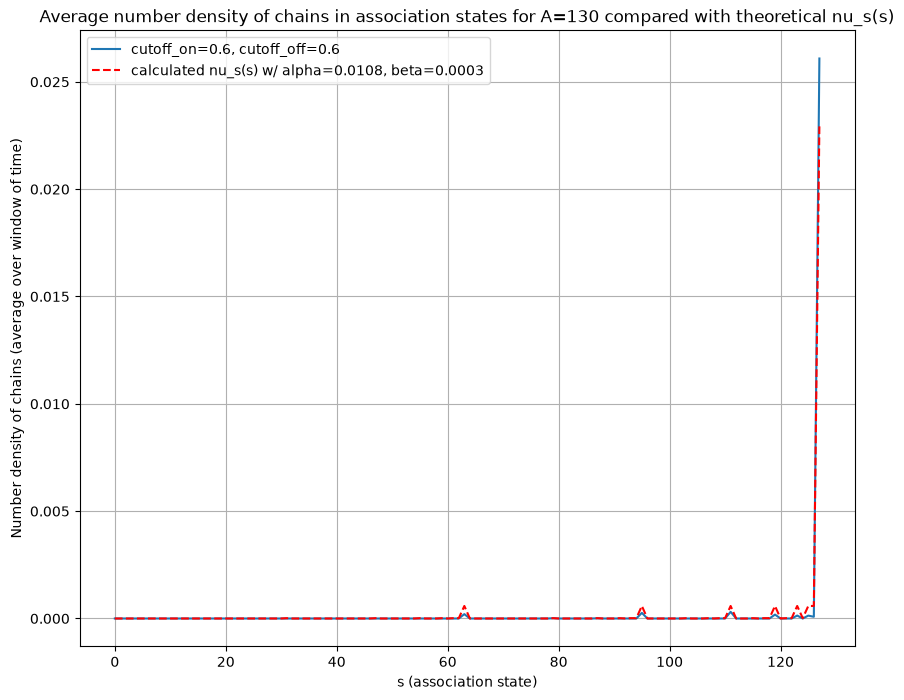

52    93.785571
Name: tau_2, dtype: float64
chi squared for 0.6 0.7 is 0.004290077962888589


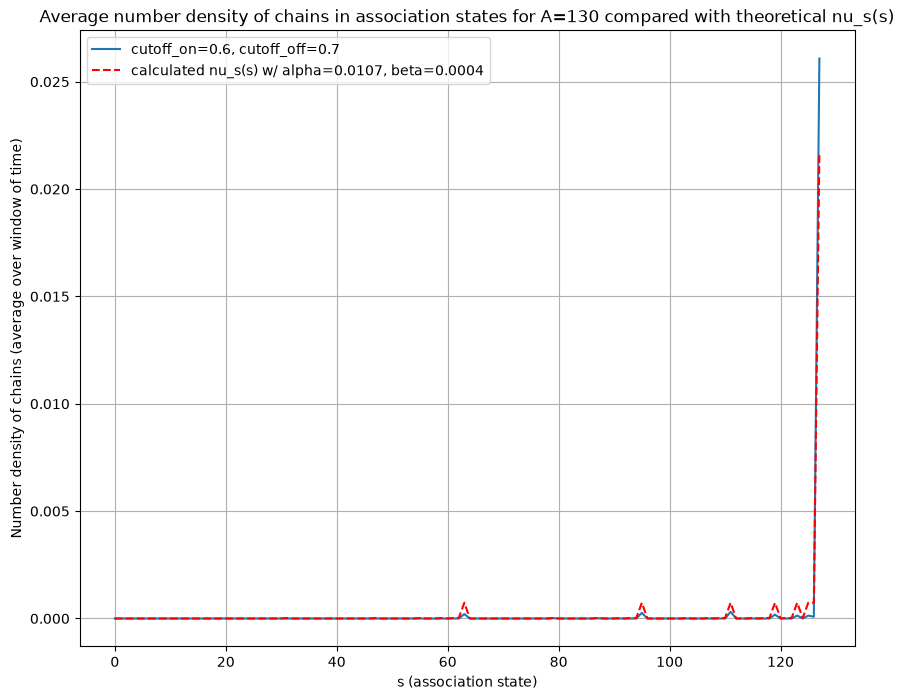

53    50.435151
Name: tau_2, dtype: float64
chi squared for 0.7 0.7 is 0.0014188043975901787


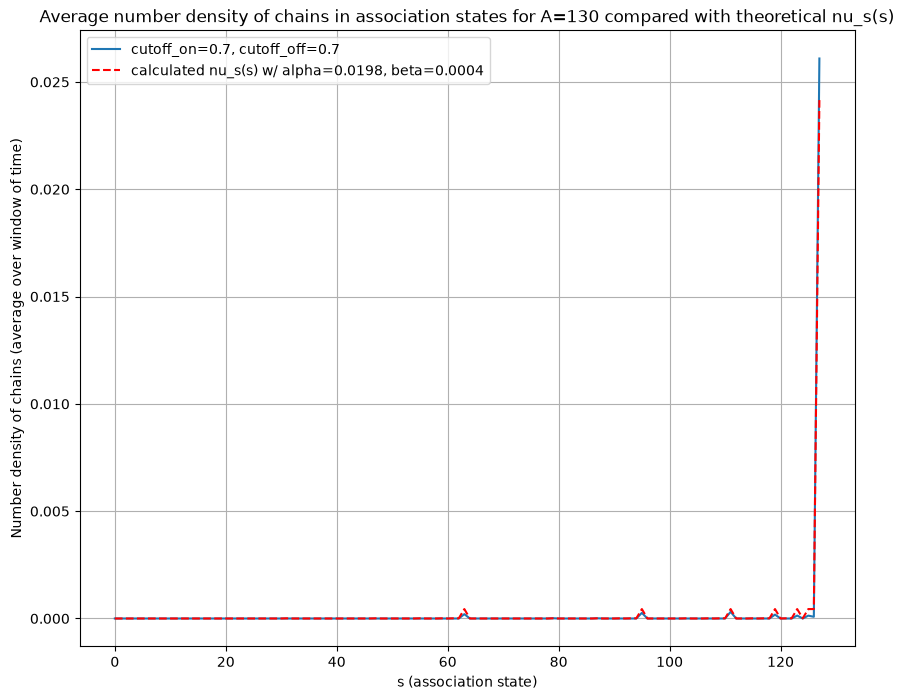

Lowest chi squared value: 0.0014188043975901787 for cutoff_on=0.7, cutoff_off=0.7


In [60]:
fit_nu_s_spectrum(130)